# CODEX analyses

In this notebook we demonstrate how mosna can be used to analyze spatiallly resolved omics data.  
The data used is from the publication by [Phillips et al., Nature Comm., 2023](https://doi.org/10.1038/s41467-021-26974-6) "Immune cell topography predicts response to PD-1 blockade in cutaneous T cell lymphoma".  
Here 70 Tumor MicroArray spots from 14 advanced Cutaneous T cell lymphomas (CTCL) patients enrolled in a pembrolizumab clinical trial were processed with the [CODEX](https://doi.org/10.1016/j.cell.2020.07.005) method to produce maps of numerous proteins and study the relationship between cell types in tumors with respect to immunotherapy.  

## Imports and data loading

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from time import time
import joblib
from pathlib import Path
from time import time
from tqdm import tqdm
import copy
import matplotlib as mpl
import napari
import colorcet as cc
import composition_stats as cs
from sklearn.impute import KNNImputer

from tysserand import tysserand as ty
from mosna import mosna

import matplotlib as mpl
mpl.rcParams["figure.facecolor"] = 'white'
mpl.rcParams["axes.facecolor"] = 'white'
mpl.rcParams["savefig.facecolor"] = 'white'
plt.style.use('seaborn-v0_8-poster') #'seaborn-v0_8-notebook'

/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/geremi/miniconda3/envs/mosna/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/geremi/miniconda3/envs/mosna/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_

In [37]:
# If need to reload modules after their modification
from importlib import reload
ty = reload(ty)
mosna = reload(mosna)

In [99]:
RUN_LONG = False

In [2]:
from sklearn.metrics import classification_report, accuracy_score,roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression



def logistic_regression(dataset, test_size, max_iter, l1_ratio = 0.1, plot_roc=True, plot_coef=True):
    # Séparation X / y
    y = dataset.index.get_level_values('Groups')
    X = dataset.copy()

    # Encodage des labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Label mapping:", mapping)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=0, shuffle=True
    )

    # Modèle
    modelLR = LogisticRegression(max_iter= max_iter, penalty='elasticnet', l1_ratio = l1_ratio , solver='saga')
    modelLR.fit(X_train, y_train)

    # Prédictions
    y_train_pred = modelLR.predict(X_train)
    y_test_pred = modelLR.predict(X_test)

    # Évaluation
    print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
    print("Accuracy (Test):", accuracy_score(y_test, y_test_pred))
    print("Accuracy (Train):", accuracy_score(y_train, y_train_pred))

    if plot_roc:
        y_train_pred_prob = modelLR.predict_proba(X_train)[:, 1]
        y_test_pred_prob = modelLR.predict_proba(X_test)[:, 1]

        fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)
        roc_auc_test = auc(fpr_test, tpr_test)

        fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
        roc_auc_train = auc(fpr_train, tpr_train)

        # Plot ROC
        plt.figure()
        plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label='Test ROC (AUC = %0.2f)' % roc_auc_test)
        plt.plot(fpr_train, tpr_train, color='blue', lw=2, label='Train ROC (AUC = %0.2f)' % roc_auc_train)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve - Logistic Regression')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

    if plot_coef:
        coef = pd.DataFrame({'coef': modelLR.coef_.flatten()}, index=X.columns)
        coef['abs coef'] = coef['coef'].abs()
        coef = coef.sort_values(by='abs coef', ascending=False)
        coef['% total'] = coef['abs coef'] / coef['abs coef'].sum()
        coef['cum % total'] = coef['% total'].cumsum()
        coef['coef OR'] = np.exp(coef['coef'])

        nb_coef_plot = min(20, coef.shape[0])
        labels = coef.index[:nb_coef_plot]

        fig, ax = plt.subplots(figsize=(8, 8))
        coef.loc[labels, 'coef'].plot.bar(ax=ax)
        ax.hlines(y=0, xmin=-0.5, xmax=nb_coef_plot-0.5, colors='gray', linestyles='dashed')
        ax.set_xticks(range(nb_coef_plot))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_xlabel('Variables')
        ax.set_ylabel('Coefficients')
        ax.set_title('Top coefficients (Logistic Regression)')
        plt.tight_layout()
        plt.grid(True)
        plt.show()

    return modelLR    

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import time

def random_forest(df, test_size = 0.4, n_estimators=100, max_depth=5):
    # --- Cible et features ---
    y = df.index.get_level_values('Groups')
    X = df.copy()
    if "sample" in X.columns:
        X = X.drop("sample", axis=1)

    # --- Encodage des labels ---
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Label mapping:", mapping)

    # --- Split des données ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=0, shuffle=True
    )

    # --- Modèle ---
    modelRF = RandomForestClassifier(
        n_estimators=n_estimators,
        max_samples=0.8,
        max_depth=max_depth,
        random_state=0
    )

    # --- Entraînement ---
    start_time = time.time()
    modelRF.fit(X_train, y_train)
    end_time = time.time()
    print(f"Temps d'entraînement : {end_time - start_time:.2f} secondes")

    # --- Prédictions ---
    y_train_pred = modelRF.predict(X_train)
    y_test_pred = modelRF.predict(X_test)
    
    # --- Résultats ---
    print("\nClassification report (Test) :")
    print(classification_report(y_test, y_test_pred))
    print("Test Accuracy :", accuracy_score(y_test, y_test_pred))    
    print("Train Accuracy :", accuracy_score(y_train, y_train_pred))

    # --- Probabilités pour ROC ---
    y_train_prob = modelRF.predict_proba(X_train)[:, 1]
    y_test_prob = modelRF.predict_proba(X_test)[:, 1]

    # --- ROC curves ---
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    auc_test = auc(fpr_test, tpr_test)
    auc_train = auc(fpr_train, tpr_train)

    # --- Plot ROC ---
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.2f})', color='darkorange')
    plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.2f})', color='blue')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Random Forest')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return modelRF

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def plot_pca(dataset, n_vars=None, n_components=2):
    # --- Sélection des variables les plus variables si n_vars est défini ---
    X = dataset.copy()
    if n_vars is not None:
        variances = X.var().sort_values(ascending=False)
        selected_features = variances.index[:n_vars]
        X = X[selected_features]
        print(f"Top {n_vars} variables sélectionnées par variance.")
    else:
        selected_features = X.columns
    
    # --- Extraction des labels et des features ---
    labels = dataset.index.get_level_values('Groups')
    
    # --- Standardisation ---
    X_scaled = StandardScaler().fit_transform(X)
    
    # --- PCA ---
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    explained_var = pca.explained_variance_ratio_ * 100

    # --- Mapping labels et couleurs ---
    label_map = {1: 'Répondeur', 2: 'Non Répondeur'}
    color_map = {1: '#1F77B4', 2: '#FF7F0E'}
    mapped_labels = labels.map(label_map)
    colors = labels.map(color_map)

    # --- Plot PCA ---
    fig, ax = plt.subplots(figsize=(10, 7))

    for group in sorted(labels.unique()):
        idx = labels == group
        ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
                   c=color_map[group],
                   label=label_map[group],
                   alpha=0.7, edgecolors='k')

        # --- Ellipse de confiance à 95% ---
        x_group = X_pca[idx, 0]
        y_group = X_pca[idx, 1]
        confidence_ellipse(x_group, y_group, ax, n_std=2, edgecolor=color_map[group], label=None)

    # --- Axes ---
    ax.set_xlabel(f"PC1 ({explained_var[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({explained_var[1]:.1f}%)")
    ax.set_title("PCA des individus")
    ax.legend(title='Groupe')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    """
    Dessine une ellipse de confiance correspondant à n_std écarts-types autour du centre des données (x, y).
    """
    if x.size != y.size:
        raise ValueError("x et y doivent avoir la même taille")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    # Calcul des coordonnées de l'ellipse
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)    

### Objects data

Load files that contains all the detected objects (the cells) across all samples and clinical data.  
Data is available from the editor, for convenience it is avaible here too:  
https://drive.google.com/drive/folders/1At8G89p4xFDm5OkLB-CRqsbWUoeLEjWZ?usp=sharing

In [6]:
data_dir = Path("/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL")
try:
    objects_path = data_dir / "41467_2021_26974_MOESM3_ESM_-_Objects.parquet"
    obj = pd.read_parquet(data_dir / "41467_2021_26974_MOESM3_ESM_-_Objects.parquet")
except FileNotFoundError:
    objects_path = data_dir / "41467_2021_26974_MOESM3_ESM_-_Objects.xlsx"
    obj = pd.read_excel(objects_path, skiprows=2)
    # for latter use
    obj.to_parquet(data_dir / "41467_2021_26974_MOESM3_ESM_-_Objects.parquet")
obj

,Count,EventCount,Index in File,ClusterID,FileName,ClusterName,Spots,Patients,Groups,FOXP3,...,PD-1+CD8+,CD4+Tcells,PD-1+tumor,CD8+Tcells,Ki67+CD4+,Ki-67+Tregs,ICOS+Tregs,IDO+Tregs,Ki67+tumor,original_index
0,0,1,60,33987,reg001,B cells,1,1,1,0.692403,...,0,0,0,0,0,0,0,0,0,0
1,1,1,94,33987,reg001,B cells,1,1,1,8.094747,...,0,0,0,0,0,0,0,0,0,1
2,2,1,198,33987,reg001,B cells,1,1,1,4.110389,...,0,0,0,0,0,0,0,0,0,2
3,3,1,284,33987,reg001,B cells,1,1,1,0.000000,...,0,0,0,0,0,0,0,0,0,3
4,4,1,298,33987,reg001,B cells,1,1,1,2.937673,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117165,116917,1,633,33981,reg066,vasculature,66,14,4,84.269714,...,0,0,0,0,0,0,0,0,0,116917
117166,116918,1,677,33981,reg066,vasculature,66,14,4,56.425945,...,0,0,0,0,0,0,0,0,0,116918
117167,116919,1,681,33981,reg066,vasculature,66,14,4,63.152092,...,0,0,0,0,0,0,0,0,0,116919
117168,116920,1,705,33981,reg066,vasculature,66,14,4,66.873306,...,0,0,0,0,0,0,0,0,0,116920


In [7]:
# sample_cols = obj.columns[:10]
obj.rename(columns={'X': 'x', 'Y': 'y', 'Z':'z', 'ClusterName': 'cell type'}, inplace=True)
patient_col = 'Patients'
sample_col = 'FileName'
group_col = 'Groups'
pos_cols = ['x', 'y']
pheno_col = 'cell type'  # unique columns with all cell types
sample_cols = [sample_col, pheno_col, patient_col, 'Spots' ,group_col]
marker_cols = obj.columns[9:67]
marker_cols = [x for x in marker_cols if x != 'HOECHST1:Cyc_1_ch_1']
# pos_cols = obj.columns[69:76]
# slices are 5µm thick, so data is pseudo-2D, including z leads to spatial networks reconstruction artifacts
cell_type_cols = list(obj.columns[75:96]) # one-hot encoded cell types
marker_posit_cols = list(obj.columns[100:-1])
all_cols = sample_cols + marker_cols + pos_cols + cell_type_cols + marker_posit_cols
net_cols = pos_cols + [pheno_col] + cell_type_cols + marker_cols
nb_clusters = obj[pheno_col].unique().size

In [6]:
with pd.option_context('display.max_rows', 40):
    print(obj[pheno_col].value_counts())

cell type
tumor cells                     38499
epithelium                      18182
macrophages (M1>M2)             13800
stroma                          11210
Tregs                            7733
vasculature                      5404
CD8+ T cells                     5350
macrophages (M1=M2)              4426
B cells                          2205
macrophages (M2>M1)              1859
Langerhans cells                 1744
CD4+ T cells                     1647
tumor cells, intraepithelial     1316
lymphatics                        783
plasma cells                      725
mast cells                        619
nerves                            572
neutrophils                       430
IDO+ stromal cells                237
CLA+ leukocytes                   218
DCs, CD11c+                       211
Name: count, dtype: int64


In [7]:
obj.shape

(117170, 121)

In [8]:
# Select only pre-treatment samples
obj = obj.loc[obj[group_col] < 3, :]
obj.index = np.arange(len(obj))
obj[group_col].unique()

array([1, 2])

In [60]:
obj["FileName"]

0        reg001
1        reg001
2        reg001
3        reg001
4        reg001
          ...  
38060    reg058
38061    reg058
38062    reg058
38063    reg058
38064    reg058
Name: FileName, Length: 38065, dtype: object

# Prédictions des cellules à partir de la matrice de Protéomics

In [17]:
df1 = obj[marker_cols]
df1["Groups"] = obj["Groups"]
df1 = df1.set_index("Groups", append= True)


/tmp/ipykernel_4193/610895509.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Groups"] = obj["Groups"]


In [15]:
df1

,,FOXP3,GATA3,MUC-1,Vimentin,T-bet,CD62L,Cytokeratin,PD-L1,Ki-67,CD15,...,Mastcell-tryptase,MMP12,CD164,p53,CCR6,CD16,CD11b,CCR4,EGFR,sample
,Groups,,,,,,,,,,,,,,,,,,,,,
0,1,0.692403,80.418777,81.578133,0.422483,1281.423706,300.485474,0.025324,154.115509,21.706610,0.000000,...,0.000000,932.848084,2017.046997,1452.009888,1666.669556,1692.139648,729.536743,980.480530,2174.919678,reg001
1,1,8.094747,75.731651,113.700844,48.759071,871.266174,727.925598,6.335735,158.100159,0.000000,3.918327,...,0.818631,808.271423,2883.205811,1766.072021,1818.412964,2158.456299,4201.670898,2979.158447,1702.522217,reg001
2,1,4.110389,120.782913,92.355637,718.113159,541.268494,634.931030,0.000000,1358.853149,19.519222,0.000000,...,0.000000,696.024475,3790.150391,1198.464722,6729.749023,1725.925171,601.758179,2999.567627,1925.974609,reg001
3,1,0.000000,51.528435,66.819679,47.125046,1029.719727,441.645203,0.000000,179.429733,22.709156,0.000000,...,0.000000,763.677307,4075.999023,1284.326294,1321.358398,1140.679688,660.061523,1081.780029,1503.303955,reg001
4,1,2.937673,76.295013,136.434204,88.958450,528.213989,745.576172,25.205679,195.440445,36.913433,0.494460,...,0.000000,910.665527,8478.983398,1950.192505,2833.836670,703.584473,203.676590,767.187683,1224.029053,reg001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38060,2,0.000000,50.714081,0.000000,0.000000,0.000000,72.675774,30.492043,0.000000,19.796062,16.188488,...,31.416611,923.047302,1362.034058,1058.102539,1134.356323,836.627075,1167.243408,1258.106567,2183.726318,reg058
38061,2,42.773430,113.690819,15.576812,2006.328003,451.929474,301.692261,0.892271,433.525604,22.523672,0.071981,...,0.163768,1356.308716,985.916931,1627.687500,1754.647827,1600.770020,1005.045410,2411.905273,2904.633789,reg058
38062,2,0.000000,40.291916,46.055092,1636.253784,432.890259,217.894318,0.000000,228.885956,14.225642,0.000000,...,1.227971,358.626953,641.118652,1225.415039,1008.284058,836.857178,671.284424,1729.702148,1410.234741,reg058


Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}
Temps d'entraînement : 14.25 secondes

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.88      0.46      0.60      6005
           1       0.73      0.96      0.83      9221

    accuracy                           0.76     15226
   macro avg       0.80      0.71      0.71     15226
weighted avg       0.79      0.76      0.74     15226

Test Accuracy : 0.7596873768553789
Train Accuracy : 0.7788432067953939


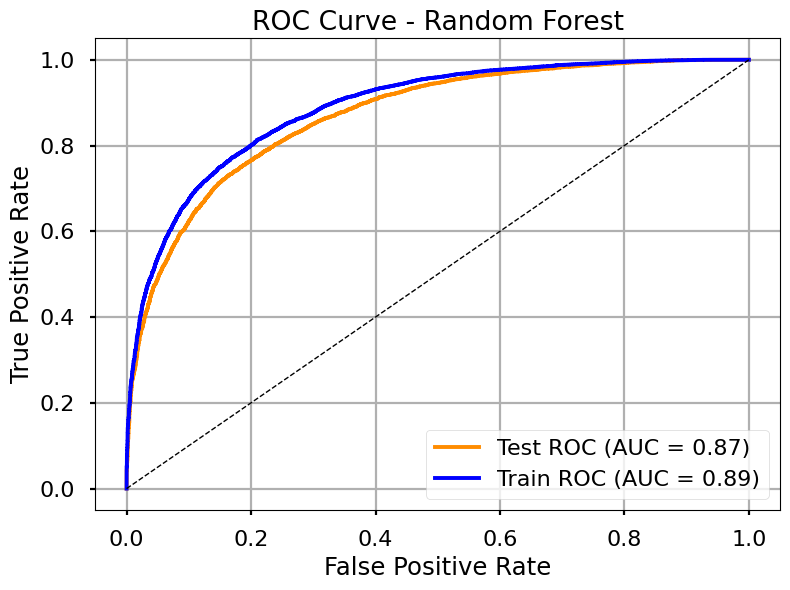

RandomForestClassifier(max_depth=5, max_samples=0.8, n_estimators=300,
                       random_state=0)

In [20]:
random_forest(df1, n_estimators= 300 )

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.67      0.70      2962
           1       0.80      0.85      0.82      4651

    accuracy                           0.78      7613
   macro avg       0.77      0.76      0.76      7613
weighted avg       0.77      0.78      0.77      7613

Accuracy (Test): 0.7759096282674373
Accuracy (Train): 0.785071588073033


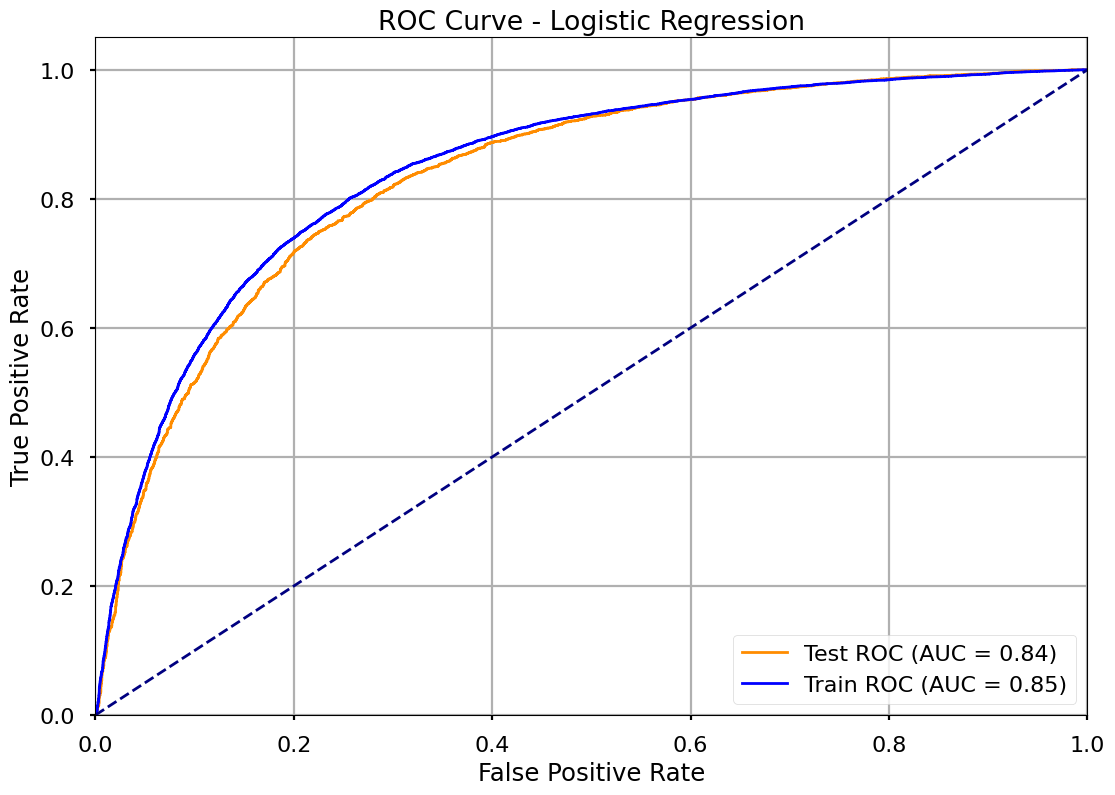

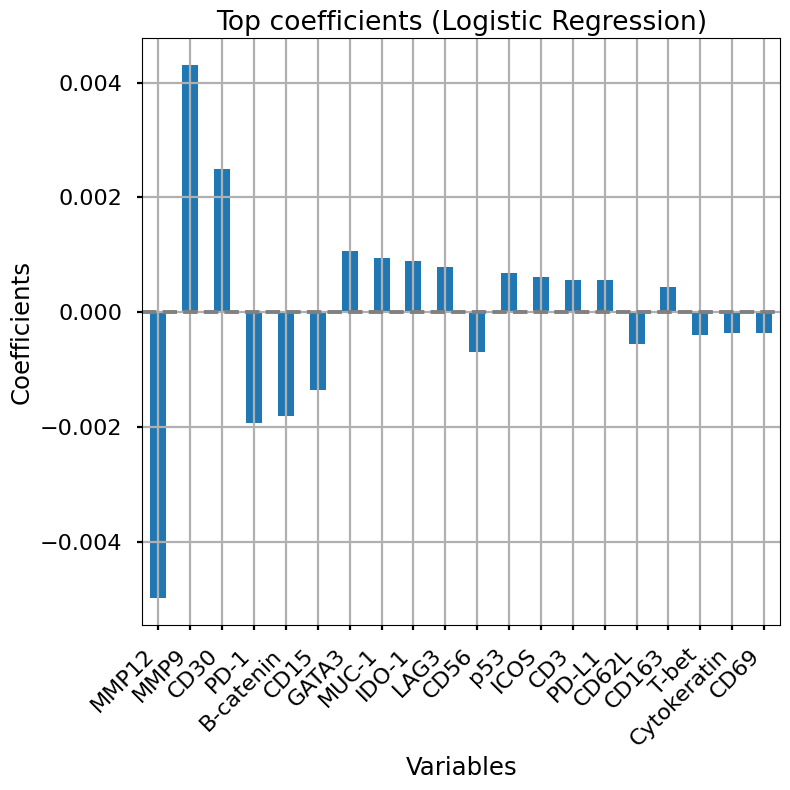

LogisticRegression(l1_ratio=0.2, max_iter=1000, penalty='elasticnet',
                   solver='saga')

In [104]:
logistic_regression(df1, test_size=0.2, max_iter=1000, l1_ratio=0.2)

In [108]:
import shap

explainer = shap.TreeExplainer(modelRF_bal)
shap_RF = explainer(X, check_additivity = False)



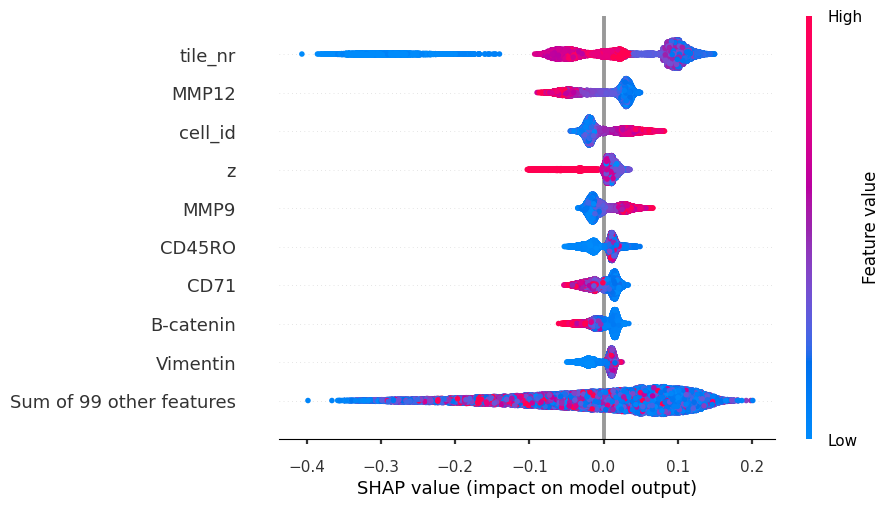

In [109]:
shap.plots.beeswarm (shap_RF[:,:,1])

In [61]:
# Show number of cells per sample
pd.set_option('display.max_rows', 500)
obj[[sample_col, patient_col, group_col, 'Count', 'Spots']].groupby([patient_col, group_col, 'Spots', sample_col]).count()

Count
Patients Groups Spots FileName       
1        1      1     reg001     1301
                2     reg002     2324
2        1      5     reg005      112
                6     reg006      603
3        2      9     reg009     2334
                10    reg010     1970
4        2      13    reg013     1765
                14    reg014     1270
5        1      17    reg017      558
                18    reg018      458
6        2      21    reg021     2483
                22    reg022     2325
7        2      25    reg025      144
                26    reg026      257
8        2      29    reg029     1916
                30    reg030     1909
                31    reg031     1102
9        1      35    reg035     2053
                36    reg036      618
10       1      39    reg039     1225
                40    reg040     1317
11       1      41    reg041     1105
                42    reg042      385
12       2      45    reg045     1914
                46    reg046      808
13       1      51    reg051     1082
                52    reg052     1707
14       2      57    reg057     1166
                58    reg058     1854

In [62]:
pd.set_option('display.max_rows', 10)

### Response status pre/post treatment

In [63]:
code_groups = {
  1: 'Responder, pre-treatment',
  2: 'Non-responder, pre-treatment',
  3: 'Responder, post-treatment',
  4: 'Non-responder, post-treatment',
} 

In [21]:
status_path = data_dir / "41467_2021_26974_MOESM5_ESM - Patients_spots_conditons.xlsx"
status = pd.read_excel(status_path, skiprows=2, usecols=[patient_col, group_col, 'Spots'])
# samples 5, 25, 36, 37, 40, 44 are missing
# now inferred from updated data at https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-021-26974-6/MediaObjects/41467_2021_26974_MOESM1_ESM.pdf
updated_data = [
    # [patient_col, group_col, 'Spots']
    [2, 1, 5],
    [7, 2, 25],
    [9, 1, 36],
    [9, 3, 37],
    [10, 1, 40],
    [11, 3, 44],
    ]
status = pd.concat([status, pd.DataFrame(updated_data, columns=status.columns)], axis=0)
status = status.loc[status[group_col] < 3, :]

status[sample_col] = status['Spots'].apply(lambda x: f'reg{x:03}')
pd.set_option('display.max_rows', 10)

if sample_col in status.columns:
    status.index = status[sample_col]
    status.drop(columns=[sample_col], inplace=True)
    status.index.name = sample_col
status.sort_values('Spots')

,Patients,Groups,Spots
FileName,,,
reg001,1,1,1
reg002,1,1,2
reg005,2,1,5
reg006,2,1,6
reg009,3,2,9
...,...,...,...
reg046,12,2,46
reg051,13,1,51
reg052,13,1,52


In [101]:
status["Count"].sum()

np.int64(38065)

In [129]:
df_test = df1.groupby("sample").mean()
df_test["Groups"] = status ["Groups"].values
df_test = df_test.set_index("Groups",append=True)
df_test

,,FOXP3,GATA3,MUC-1,Vimentin,T-bet,CD62L,Cytokeratin,PD-L1,Ki-67,CD15,...,TregsAll,PD-1+CD8+,CD4+Tcells,PD-1+tumor,CD8+Tcells,Ki67+CD4+,Ki-67+Tregs,ICOS+Tregs,IDO+Tregs,Ki67+tumor
sample,Groups,,,,,,,,,,,,,,,,,,,,,
reg001,1,327.924046,142.223744,173.852356,405.555815,570.032261,492.081788,5.560087,298.124768,239.819238,113.634598,...,0.078401,0.002306,0.012298,0.018447,0.082244,0.001537,0.002306,0.013067,0.000000,0.010761
reg002,1,388.779934,93.621718,132.929563,448.241957,685.927299,532.053876,0.531573,548.526589,204.669888,34.522338,...,0.106713,0.003012,0.014630,0.011618,0.052496,0.001291,0.005594,0.006885,0.000000,0.014630
reg005,1,66.812334,109.415410,97.077487,1882.335356,899.751581,433.380729,2.409986,421.838198,91.921808,7.428863,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008929
reg006,2,292.898286,108.427608,95.102812,1308.114001,636.546820,431.742369,0.998371,309.081470,284.302104,28.162732,...,0.024876,0.001658,0.004975,0.023217,0.008292,0.000000,0.003317,0.000000,0.000000,0.034826
reg009,2,227.966879,243.982579,343.591449,460.065525,696.076747,451.408026,158.856694,529.257648,310.453404,2.740001,...,0.022708,0.021851,0.046701,0.037275,0.048843,0.002142,0.002142,0.003428,0.000428,0.032562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,1,304.890422,164.194402,252.235023,938.237611,613.258670,443.975022,83.083662,829.120285,584.691975,17.624256,...,0.051980,0.006188,0.019802,0.064356,0.044554,0.003713,0.009901,0.014851,0.008663,0.043317
reg051,1,118.258315,293.536382,122.103896,567.452377,714.651648,481.084734,330.033124,418.416742,685.608803,175.630511,...,0.012939,0.003697,0.018484,0.080407,0.010166,0.000924,0.002773,0.001848,0.000000,0.012939
reg052,2,96.560403,345.831114,266.604795,327.541337,807.823900,439.566552,701.537673,625.299708,855.332520,122.071863,...,0.021090,0.001172,0.010545,0.069127,0.002929,0.000000,0.001757,0.001757,0.000586,0.009373


In [137]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_test),
    columns=df_test.columns,
    index=df_test.index
)

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.50      0.50      0.50         6

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.50        12
weighted avg       0.50      0.50      0.50        12

Accuracy (Test): 0.5
Accuracy (Train): 1.0


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


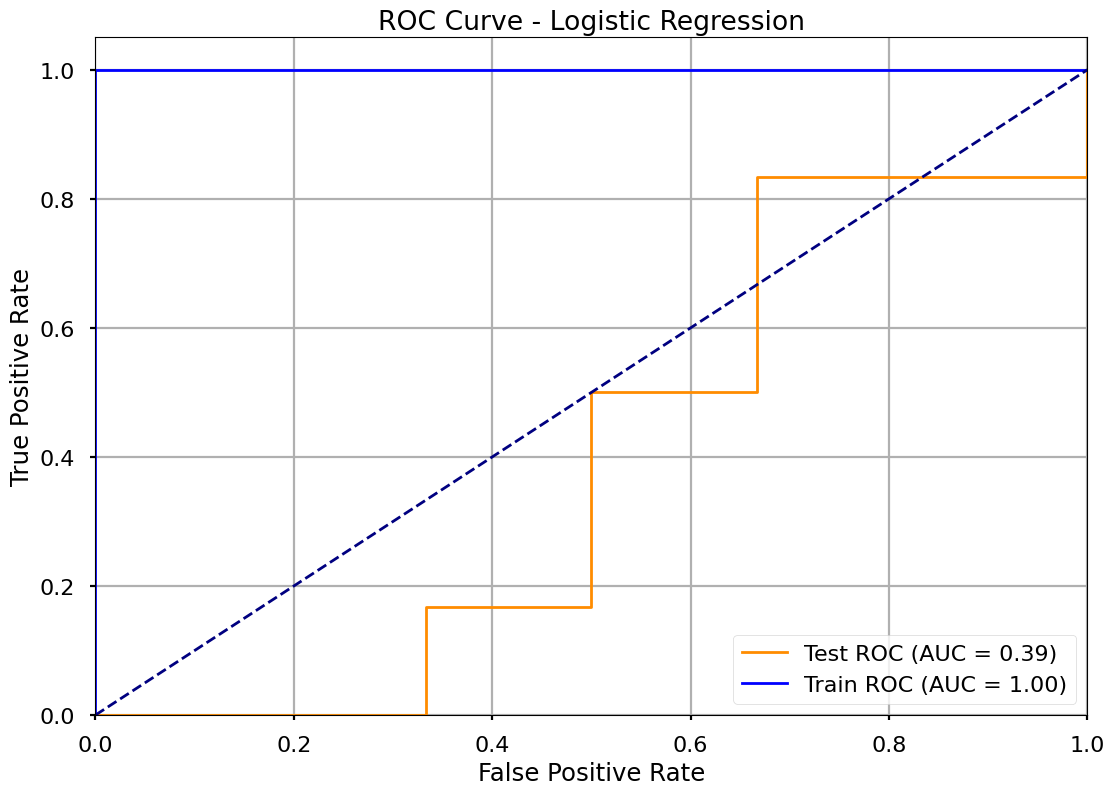

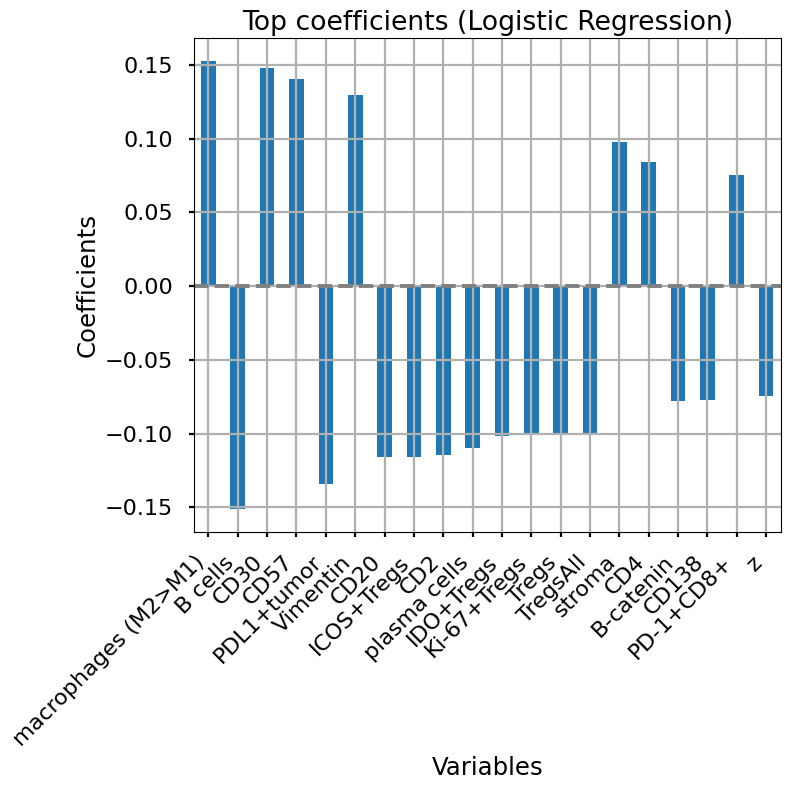

In [138]:
logistic_regression(df_normalized, test_size=0.4, max_iter=15, l1_ratio=1)

In [23]:
# When status had too many missing values after first data release:
# we make a status dataframe from the objects dataframe
status = obj[[sample_col, patient_col, group_col, 'Count', 'Spots']].groupby([patient_col, group_col, 'Spots', sample_col]).count().reset_index()
if sample_col in status.columns:
    status.index = status[sample_col]
    status.drop(columns=[sample_col], inplace=True)
    status.index.name = sample_col

# Drop sample with too few cells
# net_size_threshold = 300
net_size_threshold = 0    # no filtering
status = status.loc[status['Count'] >= net_size_threshold, :]
# status.drop(columns=['Count'], inplace=True)

# update the `object` dataframe
uniq_filenames = set(status.index)
obj = obj.query("FileName in @uniq_filenames")

pd.set_option('display.max_rows', 10)
status

,Patients,Groups,Spots,Count
FileName,,,,
reg001,1,1,1,1301
reg002,1,1,2,2324
reg005,2,1,5,112
reg006,2,1,6,603
reg009,3,2,9,2334
...,...,...,...,...
reg046,12,2,46,808
reg051,13,1,51,1082
reg052,13,1,52,1707


### Survival data

In [47]:
survival_path = data_dir / "cohort_response.ods"
surv = pd.read_excel(survival_path)
surv.index = surv['Patient ID']
surv.drop(columns=['Patient ID'], inplace=True)
surv.index.name = patient_col
surv

,Age at screening (years),Gender,Diagnosis,Disease Stage,Prior therapies,Response status,Biopsy timepoints,CO2 (weeks),Response / progression time (weeks),EOT time (weeks),Death time (weeks),Follow-up time (weeks)
Patients,,,,,,,,,,,,
1,76.14,Male,MF,IIIA,3,Responder,"Pre, EOT",NaN,NaN,104.0,NaN,142
2,60.59,Male,MF,IIIB,4,Responder,"Pre, EOT",NaN,NaN,104.0,NaN,151
3,52.01,Male,SS,IVA,3,Non-responder,"Pre, EOT",NaN,NaN,98.0,98.0,98
4,85.14,Female,SS,IVA,4,Non-responder,"Pre, EOT",NaN,NaN,104.0,142.0,142
5,75.24,Male,MF,IIB,6,Responder,"Pre, EOT",NaN,NaN,104.0,NaN,103
...,...,...,...,...,...,...,...,...,...,...,...,...
10,66.40,Male,MF,IIIA,2,Responder,Pre,NaN,NaN,NaN,119.0,119
11,72.23,Male,SS,IVA,3,Responder,"Pre, Response",NaN,22.0,104.0,NaN,171
12,72.59,Male,SS,IVA,5,Non-responder,"Pre, Progression",NaN,15.0,15.0,NaN,15


## Spatial networks reconstruction

### Load samples of one patient

We will have a look at the spatial networks of the 2 samples pre-treatment of the first patient to check they seem "correct", i.e. not over nor under connected.

### All samples network reconstruction

#### Plot spatial networks

In [24]:
processed_dir = Path('/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process')

In [25]:
trim_dist = 200 # or 'percentile_size'
min_neighbors = 3 # number of nearest nodes to connect for each unconneted node

reconst_dir = processed_dir / f"pretreatment_samples_networks_xy_min_size-{net_size_threshold}_solitary-{min_neighbors}"
save_dir = reconst_dir / "figures"
save_dir.mkdir(parents=True, exist_ok=True)
edges_dir = reconst_dir
nodes_dir = reconst_dir

#### Merge all samples

In [26]:
uniq_patients = obj[patient_col].unique()
uniq_samples = obj[sample_col].unique()
n_uniq_patients = len(uniq_patients)
n_uniq_samples = len(uniq_samples)

In [118]:
# if RUN_LONG:
#     edges_all = pd.DataFrame(data=None, columns=['source', 'target'])
#     # number of nodes previously seen
#     nb_nodes = 0
#     for sample_id in obj[patient_col].unique():
#         print(f"processing sample {sample_id}")
#         select_sample = obj[patient_col] == sample_id
#         filenames = obj.loc[select_sample, sample_col].unique()
#         for filename in filenames:
#             print("    processing filename {}".format(filename))
#             select_file = obj[sample_col] == filename
#             nodes = obj.loc[select_sample & select_file, all_cols]
#             coords = nodes[pos_cols].values
#             pairs = ty.build_delaunay(
#                 coords, 
#                 node_adaptive_trimming=True, 
#                 n_edges=3, 
#                 trim_dist_ratio=2,
#                 min_dist=0, 
#                 trim_dist=trim_dist,
#                 )
#             if min_neighbors > 0:
#                 pairs = ty.link_solitaries(
#                     coords, 
#                     pairs, 
#                     min_neighbors=min_neighbors,
#                     )

#             # increase ids in pairs by the number of nodes in all previously loaded networks
#             pairs = pairs + nb_nodes
#             edges = pd.DataFrame(data=pairs, columns=['source', 'target'])
#             edges[sample_col] = filename
#             # update number of nodes for next network
#             nb_nodes = nb_nodes + coords.shape[0]
#             edges_all = pd.concat([edges_all, edges], ignore_index=True)
#     edges_all.to_csv(reconst_dir / 'sample_all-edges.csv', index=False)
# else:
#     edges_all = pd.read_csv(reconst_dir / 'sample_all-edges.csv')

### Data transfomation and batch correction

#### CLR transformation

In [120]:
plt.style.use('seaborn-v0_8-notebook')

In [ ]:
obj[marker_cols].hist(bins=50, figsize=(20, 20));

In [ ]:
obj_transfo = mosna.transform_data(
    data=obj, 
    groups=sample_col,
    use_cols=marker_cols,
    method='clr')

obj_transfo[marker_cols].hist(bins=50, figsize=(20, 20));

In [123]:
nodes_dir = mosna.transform_nodes(
    nodes_dir=nodes_dir,
    id_level_1='patient',
    id_level_2='sample', 
    use_cols=marker_cols,
    method='clr',
    save_dir='auto',
)

## Response groups characteristics and survival analysis

We will look at what variables define or explain response to therapy or longer survival.  
For this, we will start with the simplest statistics, like proportions of cell types or marker-positive cells, and we will gradulally increase the complexity of variables, looking at interactions between cell types and finally discovering spatial neighborhoods, or "niches", potentially predictive of response to therapy.

### Cell types proportions

In [27]:
group_names = {1: 'Responder', 2:'Non-responder'}
fig_step = "02_cell_types_proportions"

In [102]:
nodes_all[pheno_col]

NameError: name 'nodes_all' is not defined

In [13]:
# we add attributes to nodes to color network figures
nodes_all = obj[pos_cols + [pheno_col]].copy()
nodes_all = nodes_all.join(pd.get_dummies(obj[pheno_col]))
uniq_phenotypes = nodes_all[pheno_col].unique() 

In [14]:
count_types2 = obj[[sample_col, group_col, 'Count']].join(nodes_all[pheno_col]).groupby([sample_col, group_col, pheno_col]).count().unstack()
count_types2.columns = count_types2.columns.droplevel()
count_types2 = count_types2.fillna(value=0).astype(int)
# count_types.index.name = 'sample'
count_types2.to_csv(save_dir / 'count_types_per_sample_per_condition.csv')
count_types2

,cell type,B cells,CD4+ T cells,CD8+ T cells,CLA+ leukocytes,"DCs, CD11c+",IDO+ stromal cells,Langerhans cells,Tregs,epithelium,lymphatics,...,macrophages (M1>M2),macrophages (M2>M1),mast cells,nerves,neutrophils,plasma cells,stroma,tumor cells,"tumor cells, intraepithelial",vasculature
FileName,Groups,,,,,,,,,,,,,,,,,,,,,
reg001,1,23,16,107,12,0,0,22,102,90,15,...,177,20,2,8,24,53,219,214,22,64
reg002,1,11,34,122,8,0,0,20,248,22,8,...,368,63,7,25,12,80,363,563,26,85
reg005,1,0,0,0,0,0,0,0,0,2,0,...,4,6,1,0,0,0,47,4,0,44
reg006,1,6,3,5,3,0,0,12,15,4,5,...,67,58,2,6,1,4,156,151,2,51
reg009,2,2,109,114,4,0,1,78,53,973,7,...,247,20,11,3,0,4,141,286,169,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,2,6,16,36,1,0,0,12,42,134,9,...,105,6,8,3,1,0,111,186,36,50
reg051,1,2,20,11,2,0,0,23,14,429,0,...,80,6,9,3,18,7,142,189,8,95
reg052,1,3,18,5,5,0,0,32,36,1075,4,...,83,7,3,14,23,2,96,230,9,24


In [28]:
count_types2 = pd.read_csv (save_dir / 'count_types_per_sample_per_condition.csv', index_col= [0,1])
count_types2

,,B cells,CD4+ T cells,CD8+ T cells,CLA+ leukocytes,"DCs, CD11c+",IDO+ stromal cells,Langerhans cells,Tregs,epithelium,lymphatics,...,macrophages (M1>M2),macrophages (M2>M1),mast cells,nerves,neutrophils,plasma cells,stroma,tumor cells,"tumor cells, intraepithelial",vasculature
FileName,Groups,,,,,,,,,,,,,,,,,,,,,
reg001,1,23,16,107,12,0,0,22,102,90,15,...,177,20,2,8,24,53,219,214,22,64
reg002,1,11,34,122,8,0,0,20,248,22,8,...,368,63,7,25,12,80,363,563,26,85
reg005,1,0,0,0,0,0,0,0,0,2,0,...,4,6,1,0,0,0,47,4,0,44
reg006,1,6,3,5,3,0,0,12,15,4,5,...,67,58,2,6,1,4,156,151,2,51
reg009,2,2,109,114,4,0,1,78,53,973,7,...,247,20,11,3,0,4,141,286,169,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,2,6,16,36,1,0,0,12,42,134,9,...,105,6,8,3,1,0,111,186,36,50
reg051,1,2,20,11,2,0,0,23,14,429,0,...,80,6,9,3,18,7,142,189,8,95
reg052,1,3,18,5,5,0,0,32,36,1075,4,...,83,7,3,14,23,2,96,230,9,24


In [136]:
from sklearn.preprocessing import StandardScaler
df_count_norm = pd.DataFrame(
    np.log1p(count_types2),
    columns=count_types2.columns,
    index=count_types2.index
)

In [194]:
import math

def plot_distributions(df, bins=30, figsize=(16, 10)):
    n_vars = df.shape[1]
    n_cols = 4  # nombre de colonnes de subplots
    n_rows = math.ceil(n_vars / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(df.columns):
        sns.histplot(df[col], bins=bins, kde=True, ax=axes[i], color="skyblue")
        axes[i].set_title(col)
        axes[i].set_xlabel("Valeur")
        axes[i].set_ylabel("Fréquence")

    # Supprimer les axes vides
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

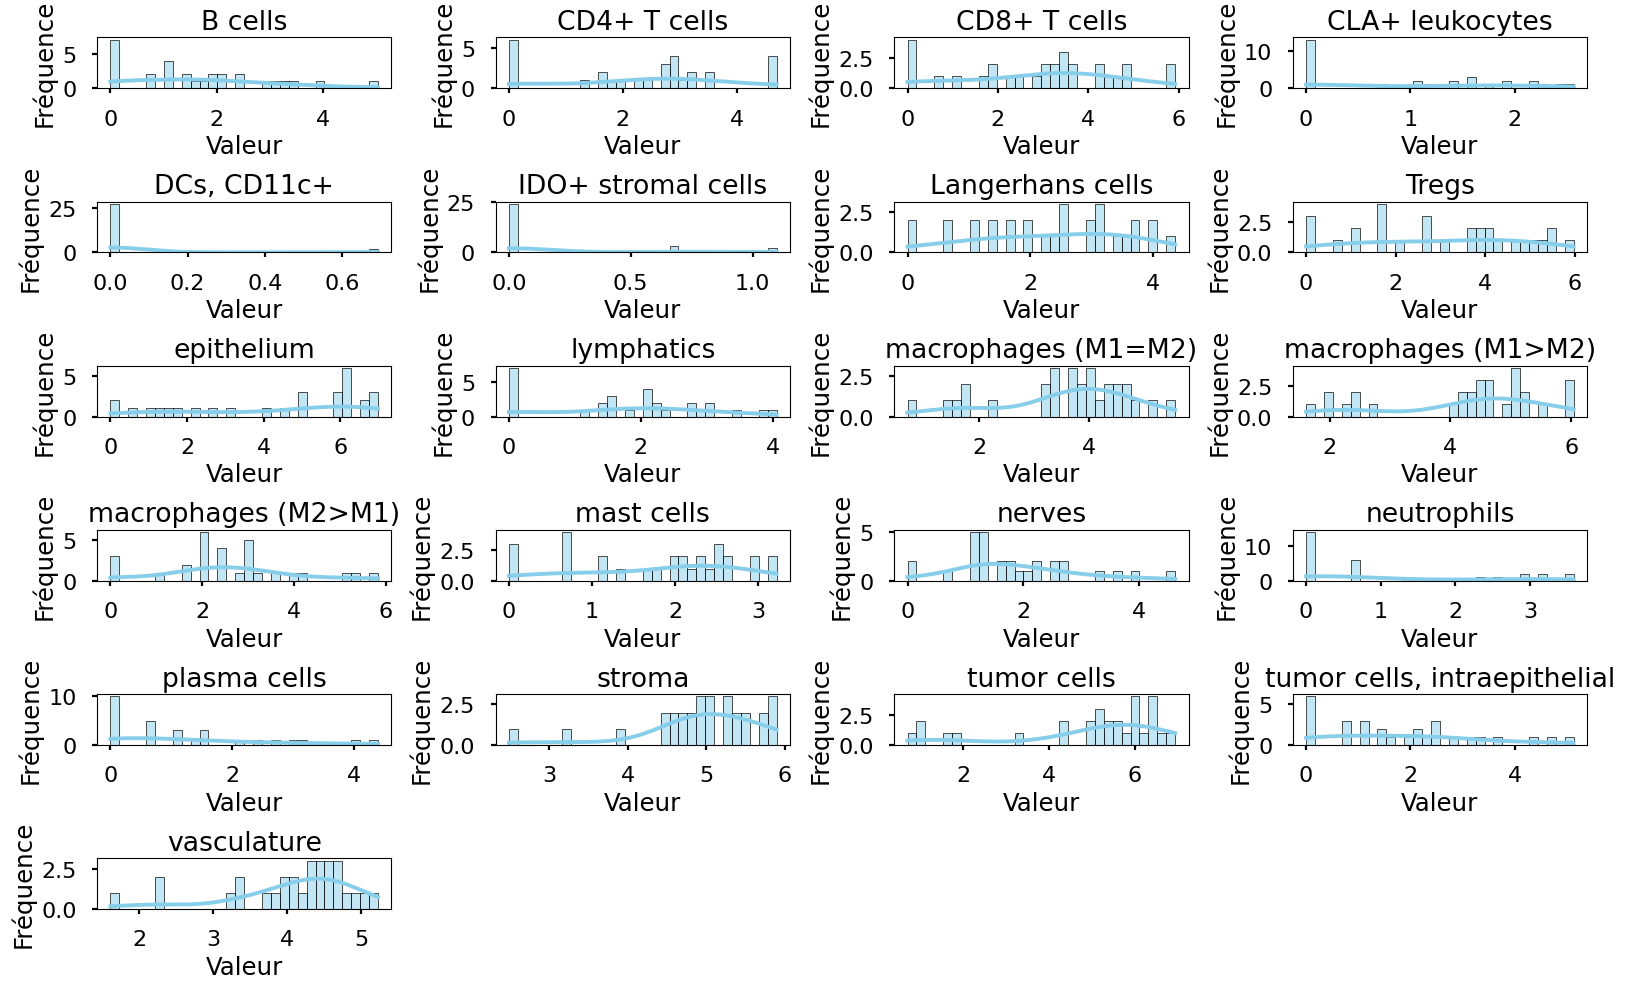

In [195]:
plot_distributions(df_count_norm)


Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.83      0.71      0.77         7

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12

Accuracy (Test): 0.75
Accuracy (Train): 0.9411764705882353


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


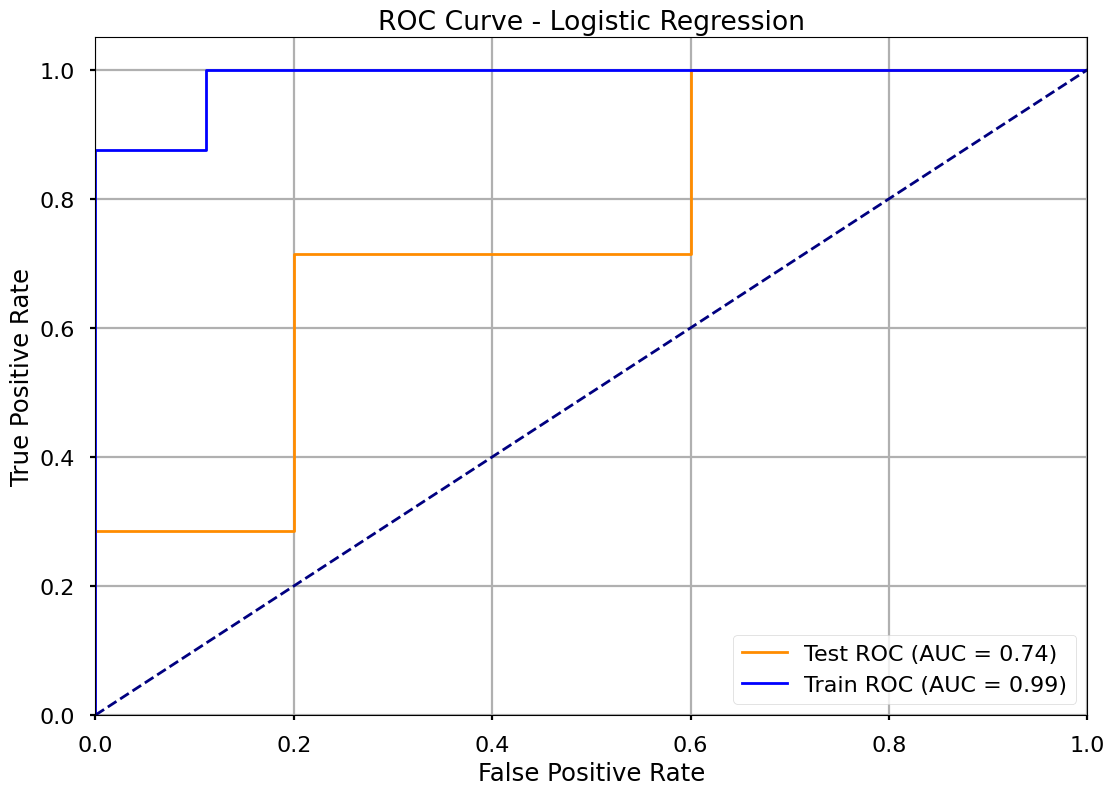

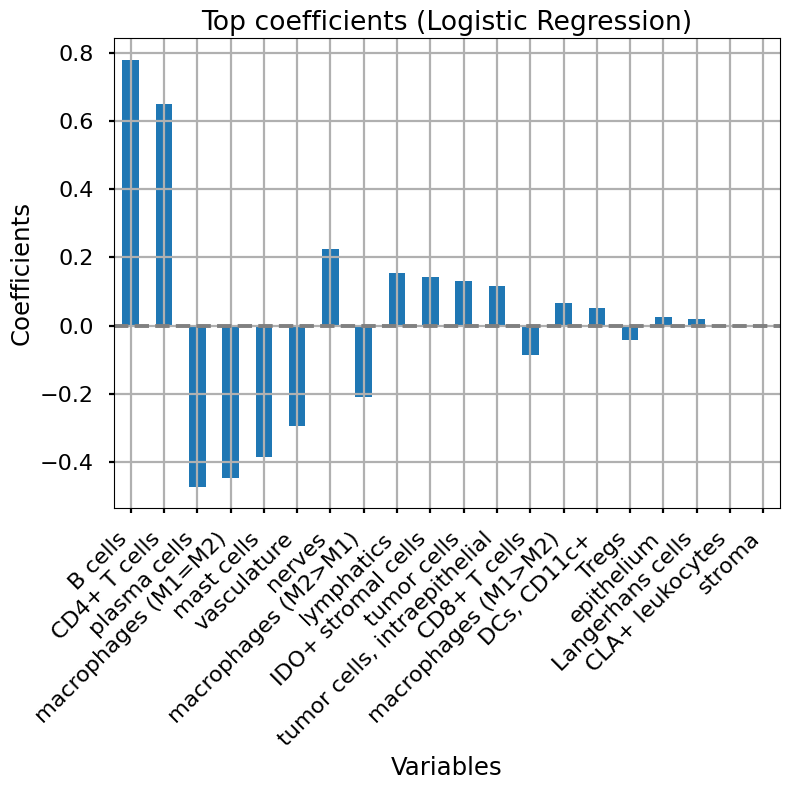

LogisticRegression(l1_ratio=0.1, penalty='elasticnet', solver='saga')

In [197]:
logistic_regression(df_count_norm[pvals2.head(20).index], test_size=0.4, l1_ratio=0.1, max_iter=100)

KeyError: 2

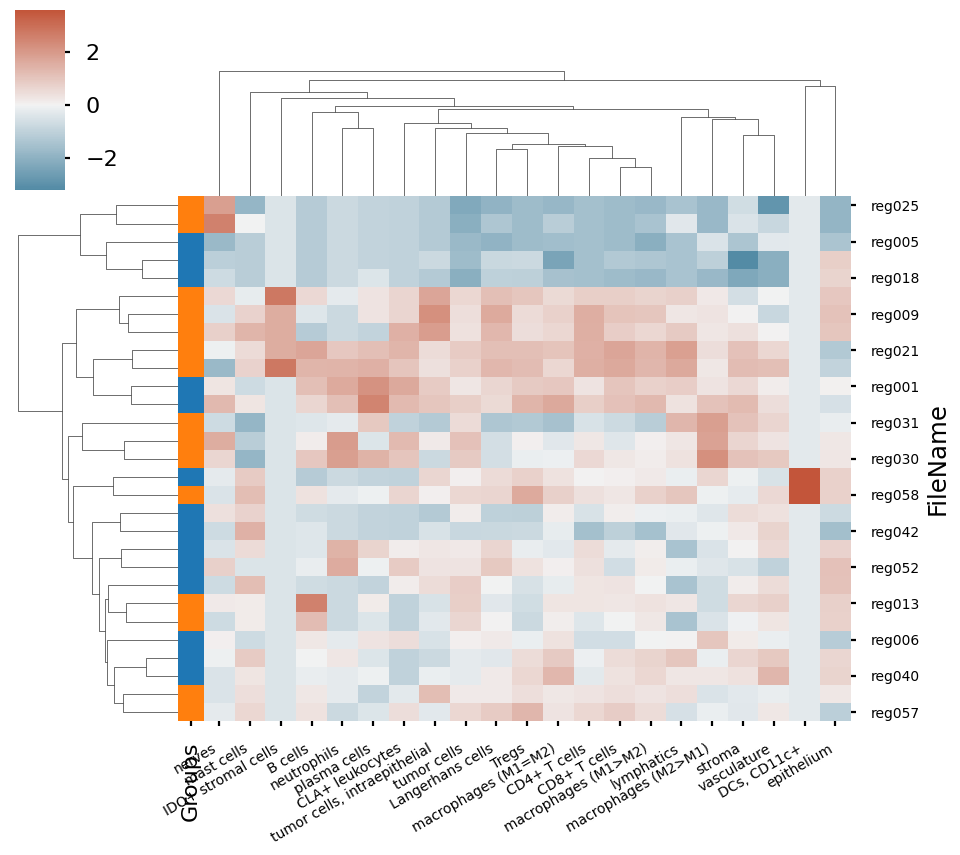

In [191]:
mosna.plot_heatmap(
    df_count_norm.reset_index(), 
    obs_labels= sample_col, 
    group_var=group_col, 
    groups=[1, 2],
    z_score=1,
    group_names=group_names,
    cbar_pos=(0.02, 0.86, 0.05, 0.18),
    legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.1, 1.3)},
    )

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}
Temps d'entraînement : 0.03 secondes

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       1.00      0.57      0.73         7

    accuracy                           0.75        12
   macro avg       0.81      0.79      0.75        12
weighted avg       0.84      0.75      0.74        12

Test Accuracy : 0.75
Train Accuracy : 0.8823529411764706


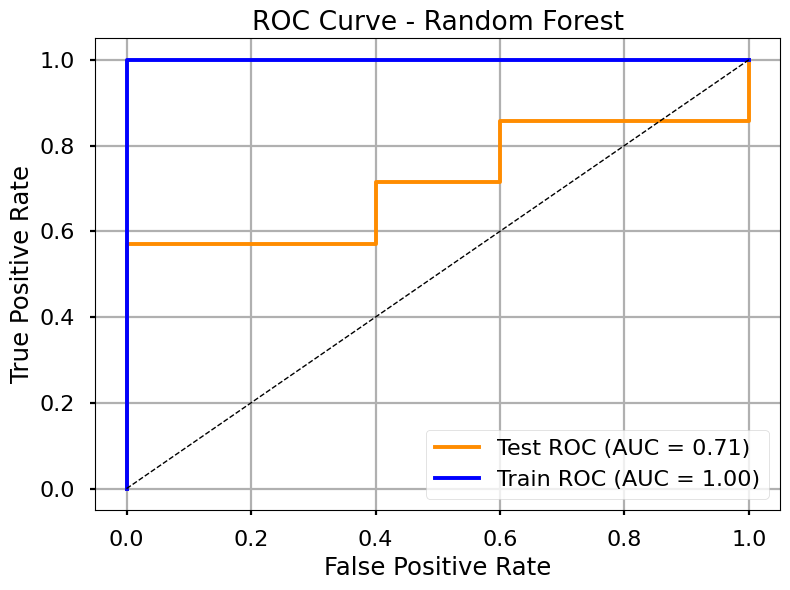

RandomForestClassifier(max_depth=3, max_samples=0.8, n_estimators=15,
                       random_state=0)

In [214]:
random_forest(count_types2[pvals2.head(7).index], n_estimators=15, max_depth=3)

In [142]:
pvals2 = mosna.find_DE_markers(df_count_norm, group_ref=1, group_tgt=2, group_var=group_col)

In [143]:
pvals2.head(10).index

Index(['tumor cells', 'IDO+ stromal cells', 'lymphatics', 'CD4+ T cells',
       'B cells', 'macrophages (M1>M2)', 'CLA+ leukocytes', 'CD8+ T cells',
       'nerves', 'Langerhans cells'],
      dtype='object')

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}
Temps d'entraînement : 0.05 secondes

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.50      0.60      0.55         5
           1       0.67      0.57      0.62         7

    accuracy                           0.58        12
   macro avg       0.58      0.59      0.58        12
weighted avg       0.60      0.58      0.59        12

Test Accuracy : 0.5833333333333334
Train Accuracy : 1.0


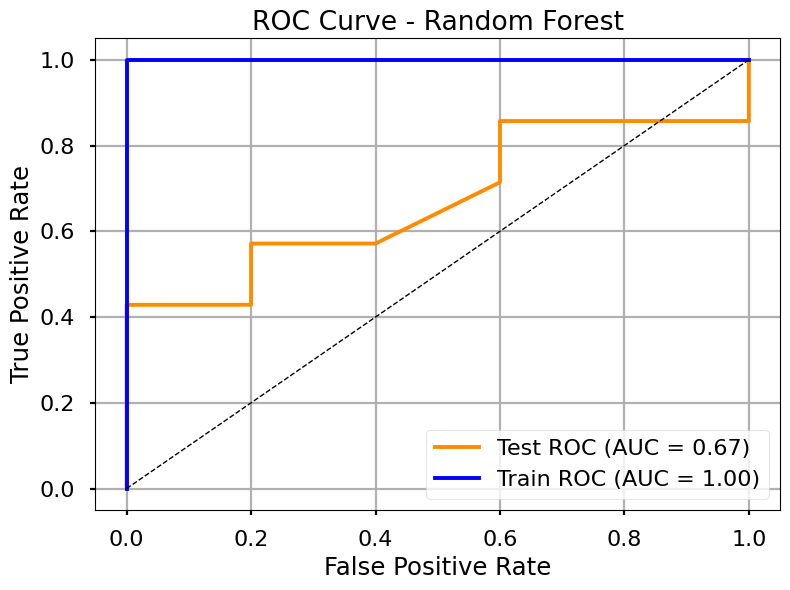

RandomForestClassifier(max_depth=5, max_samples=0.8, n_estimators=30,
                       random_state=0)

In [219]:
random_forest(df_count_norm[pvals2.head(7).index], n_estimators=30)

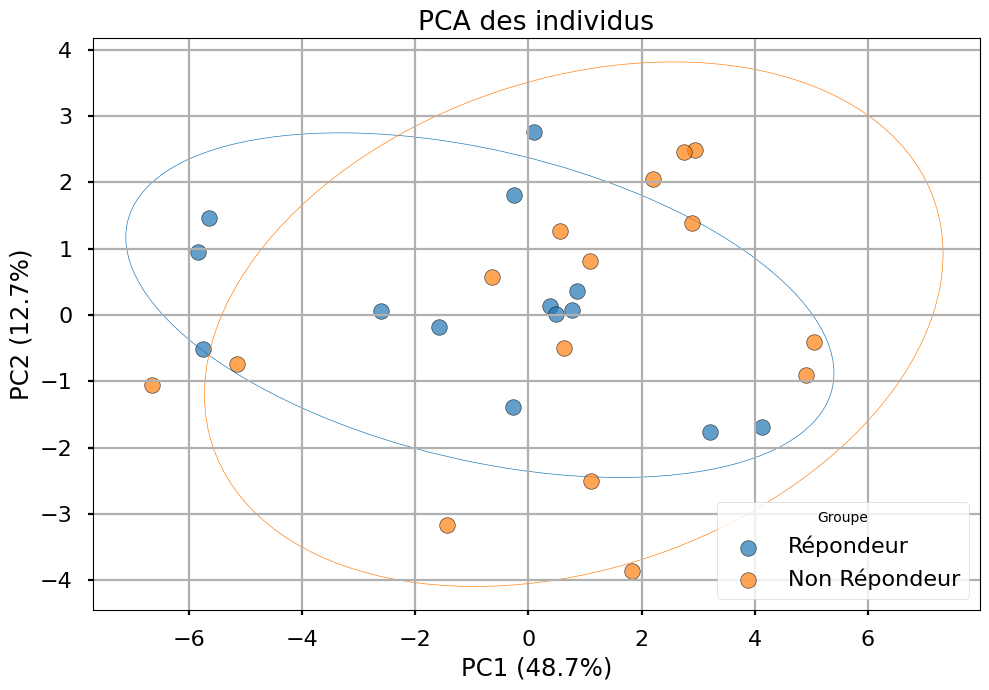

In [144]:
plot_pca(df_count_norm)

In [110]:
# here we don't use `sample_col` but `patient_col` in the group / unstack procedure to aggregate 
# statistics per patient and condition (before / after treatment) rather than per sample.

count_types = obj[[patient_col, group_col, 'Count']].join(nodes_all[pheno_col]).groupby([patient_col, group_col, pheno_col]).count().unstack()
count_types.columns = count_types.columns.droplevel()
count_types = count_types.fillna(value=0).astype(int)
# count_types.index.name = 'sample'
count_types.to_csv(save_dir / 'count_types_per_patient_per_condition.csv')
count_types

NameError: name 'nodes_all' is not defined

In [136]:
plt.style.use('seaborn-v0_8-poster')

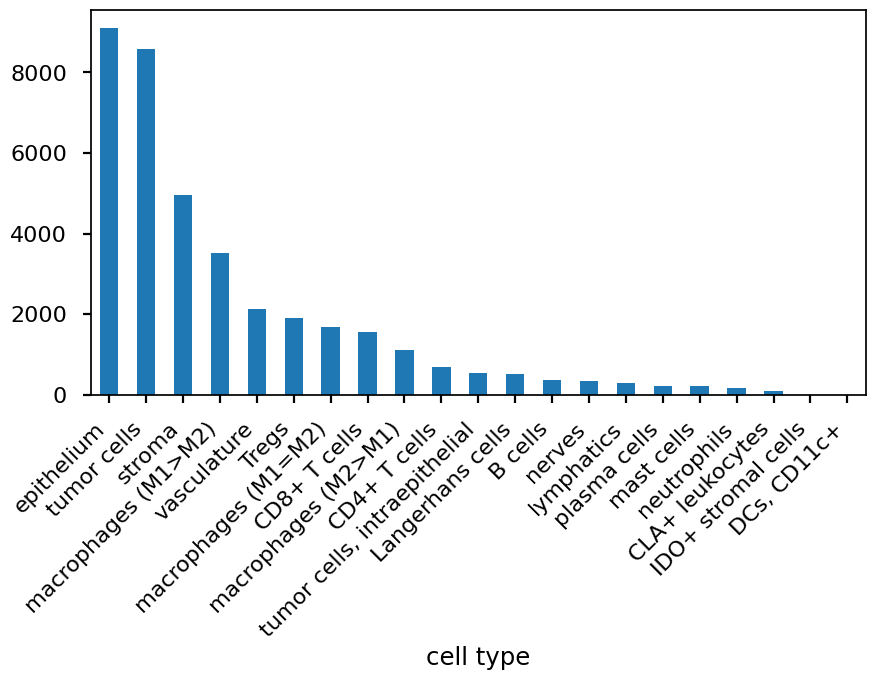

In [137]:
total_count_types = count_types.sum().sort_values(ascending=False)
ax = total_count_types.plot.bar(figsize=(10, 5))
plt.xticks(rotation=45, ha='right');
plt.savefig(save_dir / f'{fig_step}-cell_types_counts.jpg', bbox_inches='tight', facecolor='white', dpi=600)

Instead of counts we use proportions of cell types per patient and condition.

In [29]:
prop_types2 = count_types2.div(count_types2.sum(axis=1), axis=0)
prop_types2

,,B cells,CD4+ T cells,CD8+ T cells,CLA+ leukocytes,"DCs, CD11c+",IDO+ stromal cells,Langerhans cells,Tregs,epithelium,lymphatics,...,macrophages (M1>M2),macrophages (M2>M1),mast cells,nerves,neutrophils,plasma cells,stroma,tumor cells,"tumor cells, intraepithelial",vasculature
FileName,Groups,,,,,,,,,,,,,,,,,,,,,
reg001,1,0.017679,0.012298,0.082244,0.009224,0.000000,0.000000,0.016910,0.078401,0.069178,0.011530,...,0.136049,0.015373,0.001537,0.006149,0.018447,0.040738,0.168332,0.164489,0.016910,0.049193
reg002,1,0.004733,0.014630,0.052496,0.003442,0.000000,0.000000,0.008606,0.106713,0.009466,0.003442,...,0.158348,0.027108,0.003012,0.010757,0.005164,0.034423,0.156196,0.242255,0.011188,0.036575
reg005,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017857,0.000000,...,0.035714,0.053571,0.008929,0.000000,0.000000,0.000000,0.419643,0.035714,0.000000,0.392857
reg006,1,0.009950,0.004975,0.008292,0.004975,0.000000,0.000000,0.019900,0.024876,0.006633,0.008292,...,0.111111,0.096186,0.003317,0.009950,0.001658,0.006633,0.258706,0.250415,0.003317,0.084577
reg009,2,0.000857,0.046701,0.048843,0.001714,0.000000,0.000428,0.033419,0.022708,0.416881,0.002999,...,0.105827,0.008569,0.004713,0.001285,0.000000,0.001714,0.060411,0.122536,0.072408,0.011997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,2,0.007426,0.019802,0.044554,0.001238,0.000000,0.000000,0.014851,0.051980,0.165842,0.011139,...,0.129950,0.007426,0.009901,0.003713,0.001238,0.000000,0.137376,0.230198,0.044554,0.061881
reg051,1,0.001848,0.018484,0.010166,0.001848,0.000000,0.000000,0.021257,0.012939,0.396488,0.000000,...,0.073937,0.005545,0.008318,0.002773,0.016636,0.006470,0.131238,0.174677,0.007394,0.087800
reg052,1,0.001757,0.010545,0.002929,0.002929,0.000000,0.000000,0.018746,0.021090,0.629760,0.002343,...,0.048623,0.004101,0.001757,0.008202,0.013474,0.001172,0.056239,0.134739,0.005272,0.014060


In [ ]:
prop_types = count_types.div(count_types.sum(axis=1), axis=0)
prop_types

,cell type,B cells,CD4+ T cells,CD8+ T cells,CLA+ leukocytes,"DCs, CD11c+",IDO+ stromal cells,Langerhans cells,Tregs,epithelium,lymphatics,...,macrophages (M1>M2),macrophages (M2>M1),mast cells,nerves,neutrophils,plasma cells,stroma,tumor cells,"tumor cells, intraepithelial",vasculature
Patients,Groups,,,,,,,,,,,,,,,,,,,,,
1,1,0.009379,0.013793,0.063172,0.005517,0.000000,0.000000,0.011586,0.096552,0.030897,0.006345,...,0.150345,0.022897,0.002483,0.009103,0.009931,0.036690,0.160552,0.214345,0.013241,0.041103
2,1,0.008392,0.004196,0.006993,0.004196,0.000000,0.000000,0.016783,0.020979,0.008392,0.006993,...,0.099301,0.089510,0.004196,0.008392,0.001399,0.005594,0.283916,0.216783,0.002797,0.132867
3,2,0.000465,0.048327,0.043216,0.003253,0.000000,0.000465,0.030204,0.023002,0.408690,0.005576,...,0.092240,0.009061,0.007667,0.003950,0.000000,0.000929,0.076208,0.126859,0.063662,0.019981
4,2,0.058649,0.006590,0.014827,0.000000,0.000000,0.000000,0.005272,0.002965,0.296870,0.002306,...,0.066557,0.003295,0.003954,0.002965,0.000000,0.001318,0.117298,0.325206,0.001647,0.061285
5,1,0.000000,0.000000,0.000984,0.000000,0.000000,0.000000,0.004921,0.005906,0.898622,0.000000,...,0.016732,0.001969,0.001969,0.002953,0.000000,0.000984,0.033465,0.006890,0.000984,0.017717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,1,0.002754,0.005507,0.028718,0.000000,0.000000,0.000000,0.007081,0.042486,0.291503,0.010228,...,0.125492,0.011408,0.007868,0.003147,0.001574,0.001180,0.162864,0.064516,0.001967,0.123131
11,1,0.001342,0.006711,0.014765,0.000000,0.000671,0.000000,0.014765,0.053691,0.306040,0.004698,...,0.065101,0.029530,0.024832,0.004027,0.000000,0.000000,0.195302,0.117450,0.011409,0.095973
12,2,0.005878,0.018001,0.039309,0.001837,0.000000,0.000735,0.020206,0.059882,0.316312,0.008450,...,0.100661,0.008450,0.004409,0.005143,0.000735,0.001470,0.072741,0.212344,0.042983,0.038942


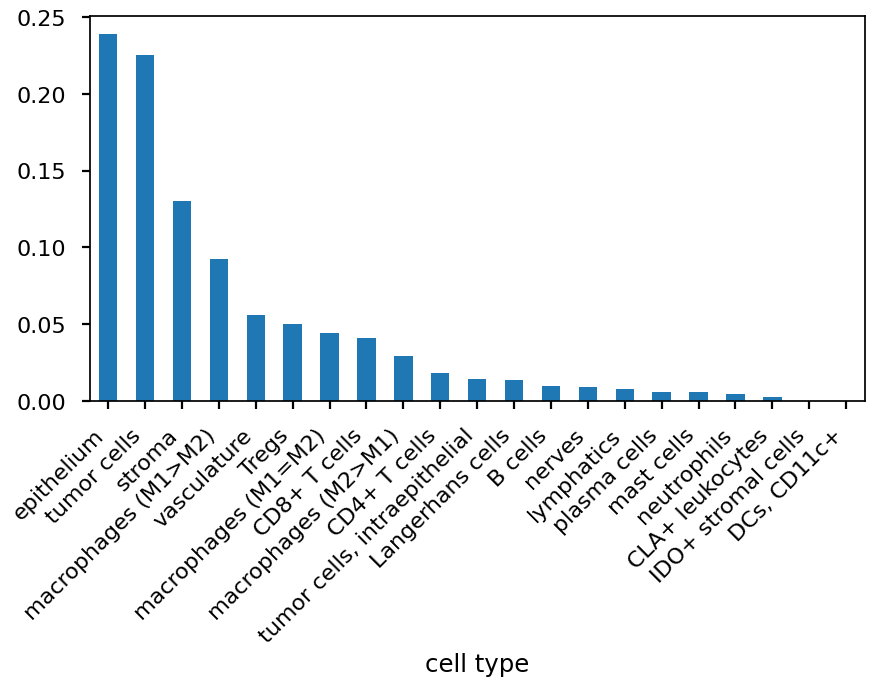

In [139]:
total_prop_types = total_count_types / total_count_types.sum()
ax = total_prop_types.plot.bar(figsize=(10, 5))
plt.xticks(rotation=45, ha='right');
plt.savefig(save_dir / f'{fig_step}-cell_types_proportions.jpg', bbox_inches='tight', facecolor='white', dpi=600)

In [140]:
total_prop_types

cell type
epithelium             0.239012
tumor cells            0.225667
stroma                 0.130120
macrophages (M1>M2)    0.092473
vasculature            0.056220
                         ...   
mast cells             0.005858
neutrophils            0.004729
CLA+ leukocytes        0.002286
IDO+ stromal cells     0.000184
DCs, CD11c+            0.000053
Length: 21, dtype: float64

There are 0 significant variables in `pval`


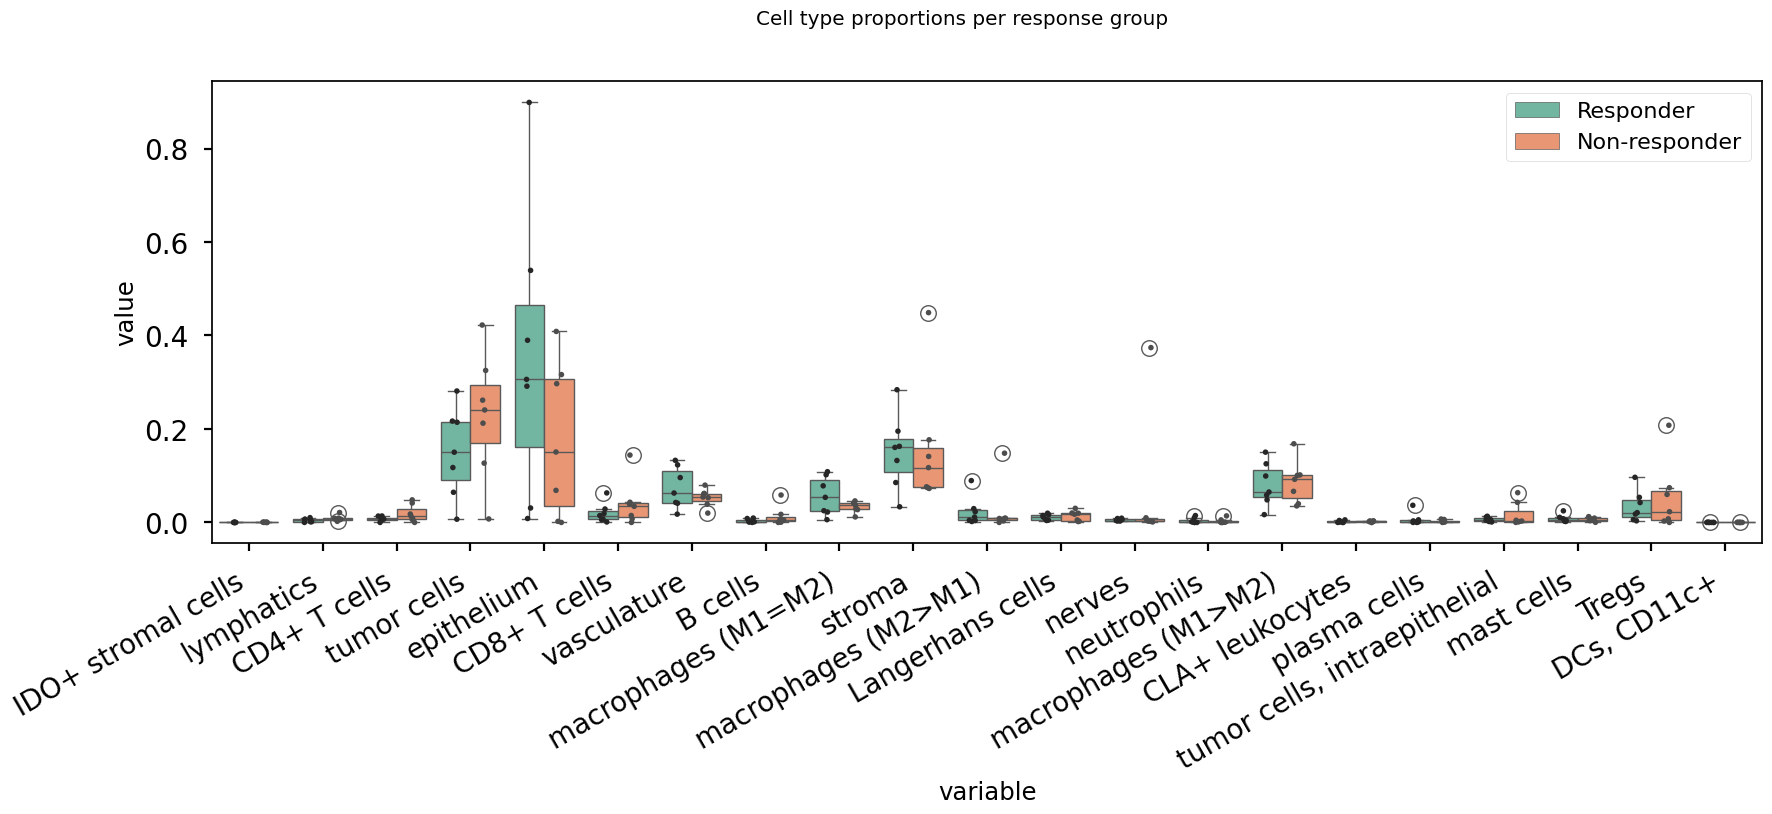

In [142]:
fig, ax = mosna.plot_distrib_groups(
    prop_types, 
    group_var=group_col,
    groups=[1, 2], 
    pval_data=pvals, 
    pval_col='pval', 
    max_cols=-1, 
    multi_ind_to_col=True,
    group_names=group_names,
    )
fig.suptitle("Cell type proportions per response group", y=1.0);
plt.savefig(save_dir / f'{fig_step}-distributions_per_response_group.jpg', bbox_inches='tight', facecolor='white', dpi=600)

Because some variables have generally higher values than others, that give them more weight to compare samples.  
To compensate for this effect we should standardize values per variable.

In [36]:
# With this dataset, when we filter networks without enough nodes
# we can't split patients in 5 groups having at least one occurrence
# of both groups (one patient of group 2 is deleted).

if net_size_threshold == 300:
    cv_train = 4
    cv_adapt = False
    cv_max = 4
else:
    cv_train = 5
    cv_adapt = False
    cv_max = 5

In [146]:
y

array([0, 2, 0, 2, 1, 3, 1, 3, 0, 2, 1, 3, 1, 3, 1, 3, 0, 2, 0, 0, 2, 1,
       3, 0, 2, 1, 3])

In [42]:
prop_types2.to_csv("/home/geremi/Desktop/PFE/Dataset/Codex_prop_TC")

In [63]:
prop_types2 = pd.read_csv ("/home/geremi/Desktop/PFE/Dataset/Codex_prop_TC", index_col= [0,1])
prop_types2

,,B cells,CD4+ T cells,CD8+ T cells,CLA+ leukocytes,"DCs, CD11c+",IDO+ stromal cells,Langerhans cells,Tregs,epithelium,lymphatics,...,macrophages (M1>M2),macrophages (M2>M1),mast cells,nerves,neutrophils,plasma cells,stroma,tumor cells,"tumor cells, intraepithelial",vasculature
FileName,Groups,,,,,,,,,,,,,,,,,,,,,
reg001,1,0.017679,0.012298,0.082244,0.009224,0.000000,0.000000,0.016910,0.078401,0.069178,0.011530,...,0.136049,0.015373,0.001537,0.006149,0.018447,0.040738,0.168332,0.164489,0.016910,0.049193
reg002,1,0.004733,0.014630,0.052496,0.003442,0.000000,0.000000,0.008606,0.106713,0.009466,0.003442,...,0.158348,0.027108,0.003012,0.010757,0.005164,0.034423,0.156196,0.242255,0.011188,0.036575
reg005,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017857,0.000000,...,0.035714,0.053571,0.008929,0.000000,0.000000,0.000000,0.419643,0.035714,0.000000,0.392857
reg006,1,0.009950,0.004975,0.008292,0.004975,0.000000,0.000000,0.019900,0.024876,0.006633,0.008292,...,0.111111,0.096186,0.003317,0.009950,0.001658,0.006633,0.258706,0.250415,0.003317,0.084577
reg009,2,0.000857,0.046701,0.048843,0.001714,0.000000,0.000428,0.033419,0.022708,0.416881,0.002999,...,0.105827,0.008569,0.004713,0.001285,0.000000,0.001714,0.060411,0.122536,0.072408,0.011997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,2,0.007426,0.019802,0.044554,0.001238,0.000000,0.000000,0.014851,0.051980,0.165842,0.011139,...,0.129950,0.007426,0.009901,0.003713,0.001238,0.000000,0.137376,0.230198,0.044554,0.061881
reg051,1,0.001848,0.018484,0.010166,0.001848,0.000000,0.000000,0.021257,0.012939,0.396488,0.000000,...,0.073937,0.005545,0.008318,0.002773,0.016636,0.006470,0.131238,0.174677,0.007394,0.087800
reg052,1,0.001757,0.010545,0.002929,0.002929,0.000000,0.000000,0.018746,0.021090,0.629760,0.002343,...,0.048623,0.004101,0.001757,0.008202,0.013474,0.001172,0.056239,0.134739,0.005272,0.014060


Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.42      1.00      0.59         5
           1       0.00      0.00      0.00         7

    accuracy                           0.42        12
   macro avg       0.21      0.50      0.29        12
weighted avg       0.17      0.42      0.25        12

Accuracy (Test): 0.4166666666666667
Accuracy (Train): 0.5294117647058824


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

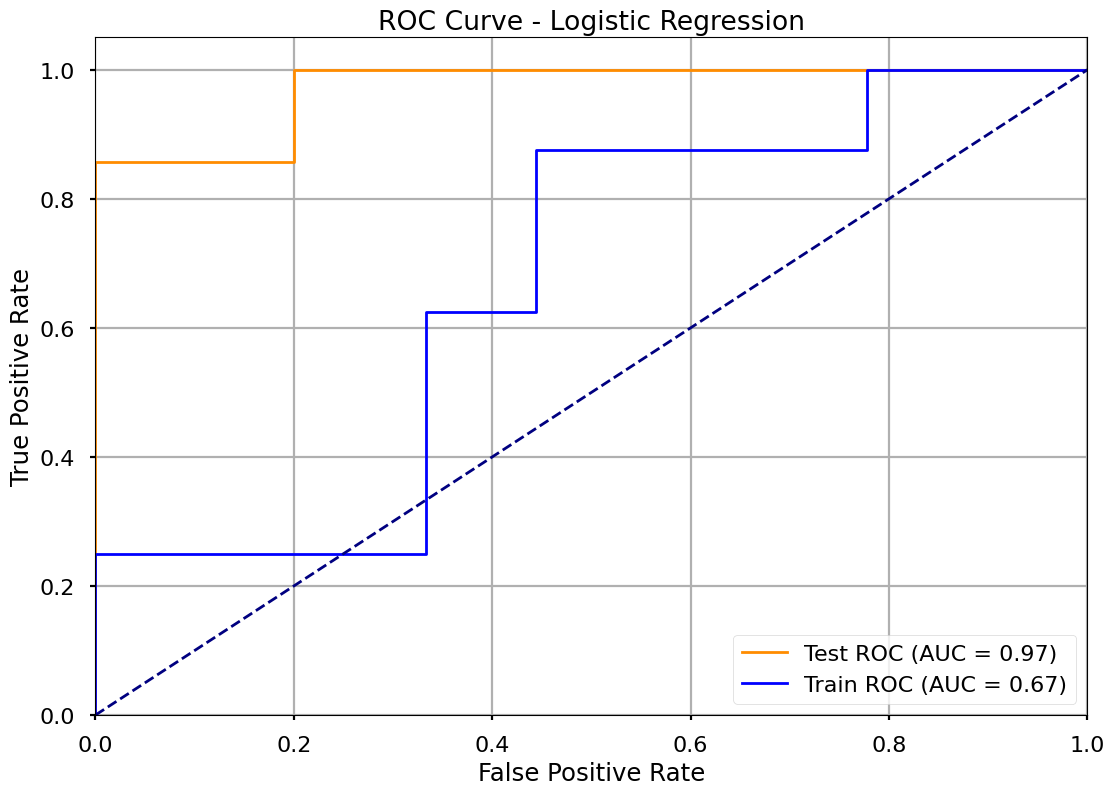

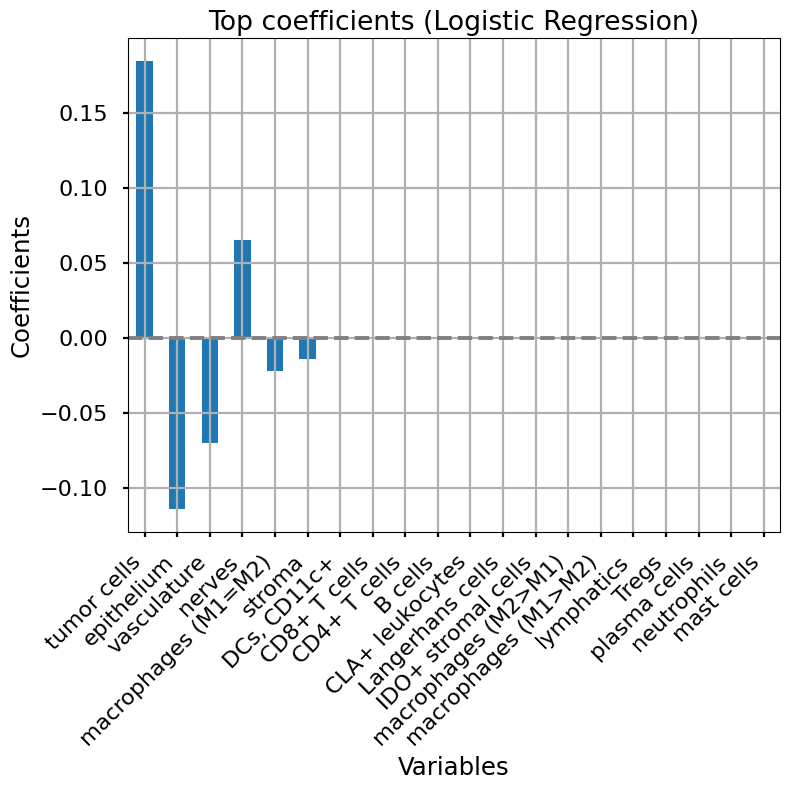

In [86]:
logistic_regression(prop_types2, max_iter = 100, l1_ratio= 0.1, test_size=0.4)

Top 20 variables sélectionnées par variance.


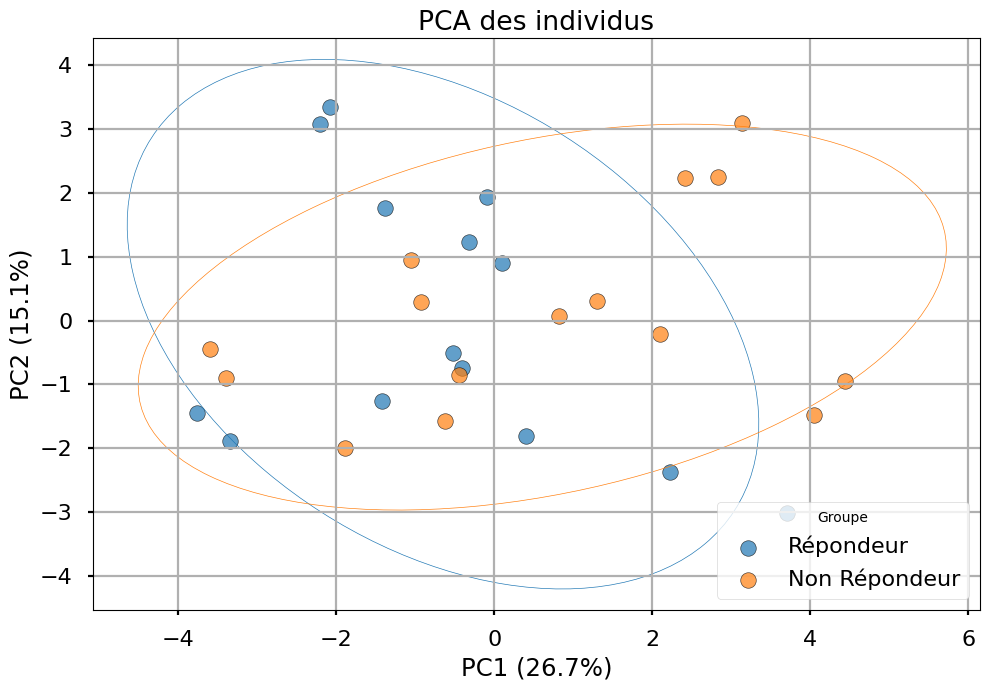

In [33]:
plot_pca (prop_types2, n_vars = 20)

In [ ]:
models = mosna.logistic_regression(
    prop_types.reset_index(),
    split_train_test = True,
    test_size = 0.25,
    y_name=group_col,
    col_drop=[patient_col],
    cv_train=cv_train, 
    cv_adapt=cv_adapt,
    #l1_ratios_list = [['Ridge',[0]], ['Lasso',[1]],['Elastic_net',[0.5]]],
    l1_ratios_list = [['Elastic_net',[0]]],
    cv_max =5,
    figsize=(8,6),
    save_plot_figures=True,
    dir_save=save_dir,
    str_prefix=f'{fig_step}_',
    )

In [60]:
pvals = mosna.find_DE_markers(prop_types2, group_ref=1, group_tgt=2, group_var=group_col)

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.42      1.00      0.59         5
           1       0.00      0.00      0.00         7

    accuracy                           0.42        12
   macro avg       0.21      0.50      0.29        12
weighted avg       0.17      0.42      0.25        12

Accuracy (Test): 0.4166666666666667
Accuracy (Train): 0.5294117647058824


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

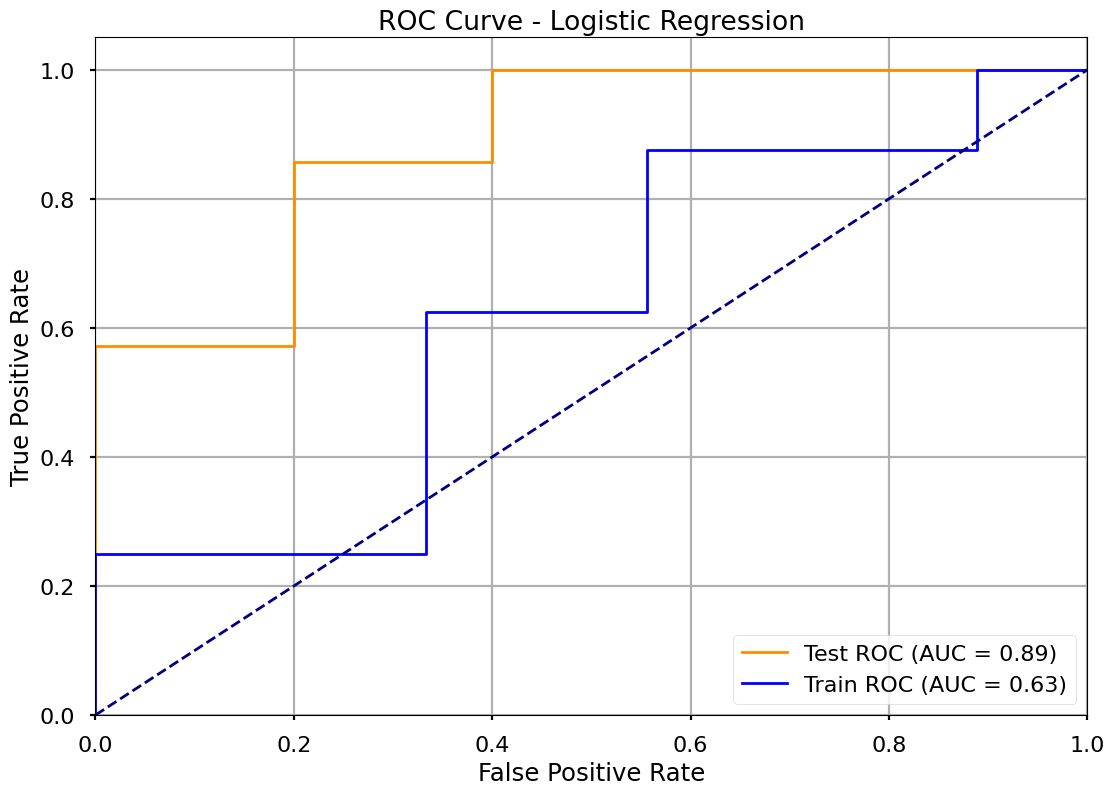

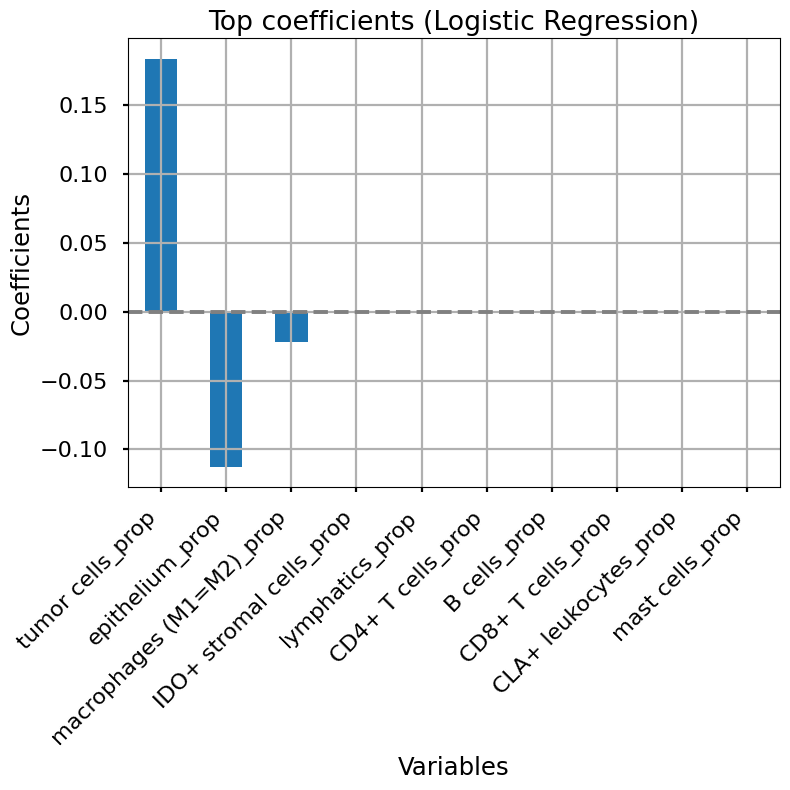

LogisticRegression(l1_ratio=0.1, max_iter=50, penalty='elasticnet',
                   solver='saga')

In [100]:
logistic_regression(prop_types2[pvals.head(10).index], test_size=0.4, max_iter=50, l1_ratio=0.1)

In [ ]:
logistic_regression (df_count_norm[])

In [64]:
prop_types2 = prop_types2.rename(columns=lambda col: f"{col}_prop")
pvals_cleaned = mosna.find_DE_markers(prop_types2, group_ref=1, group_tgt=2, group_var=group_col)
pvals_cleaned.head(10)

,pval,pval_corr
IDO+ stromal cells_prop,0.022202,0.395887
tumor cells_prop,0.052120,0.395887
CD4+ T cells_prop,0.056555,0.395887
lymphatics_prop,0.118726,0.468208
B cells_prop,0.129470,0.468208
epithelium_prop,0.156018,0.468208
macrophages (M1=M2)_prop,0.156069,0.468208
CD8+ T cells_prop,0.325513,0.812911
CLA+ leukocytes_prop,0.348390,0.812911
mast cells_prop,0.394509,0.828468


Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.60      0.50         5
           1       0.60      0.43      0.50         7

    accuracy                           0.50        12
   macro avg       0.51      0.51      0.50        12
weighted avg       0.53      0.50      0.50        12

Accuracy (Test): 0.5
Accuracy (Train): 0.8235294117647058


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


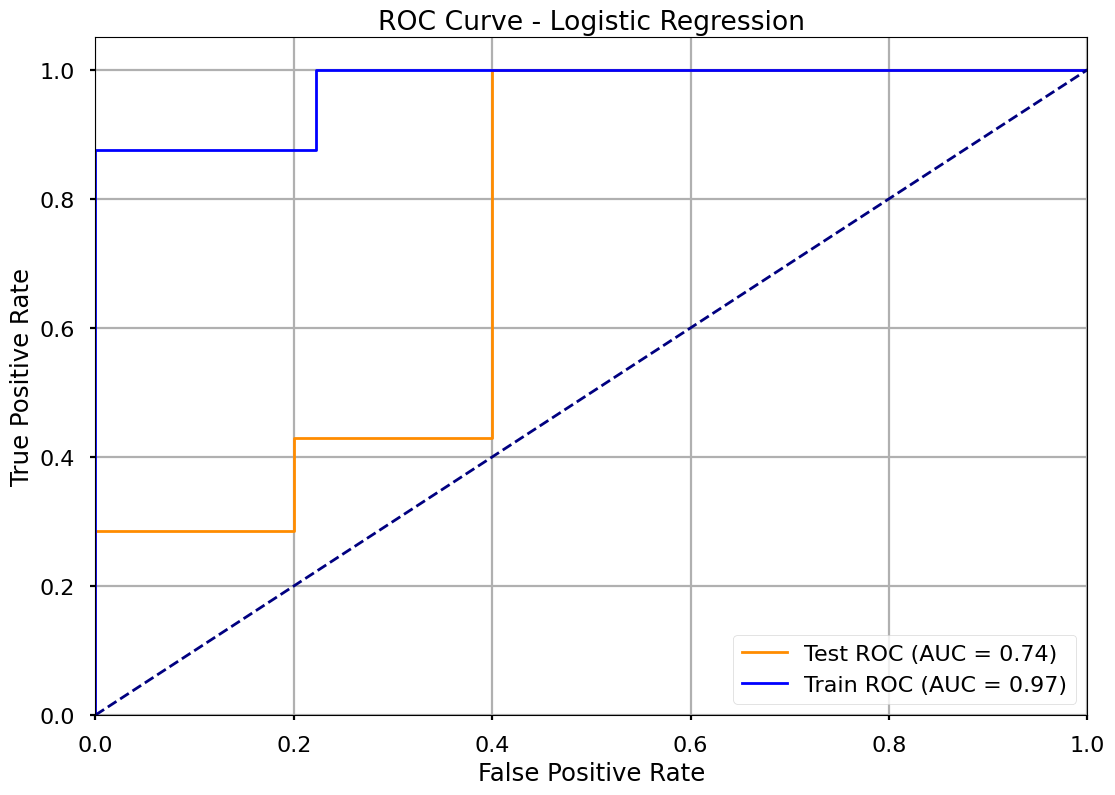

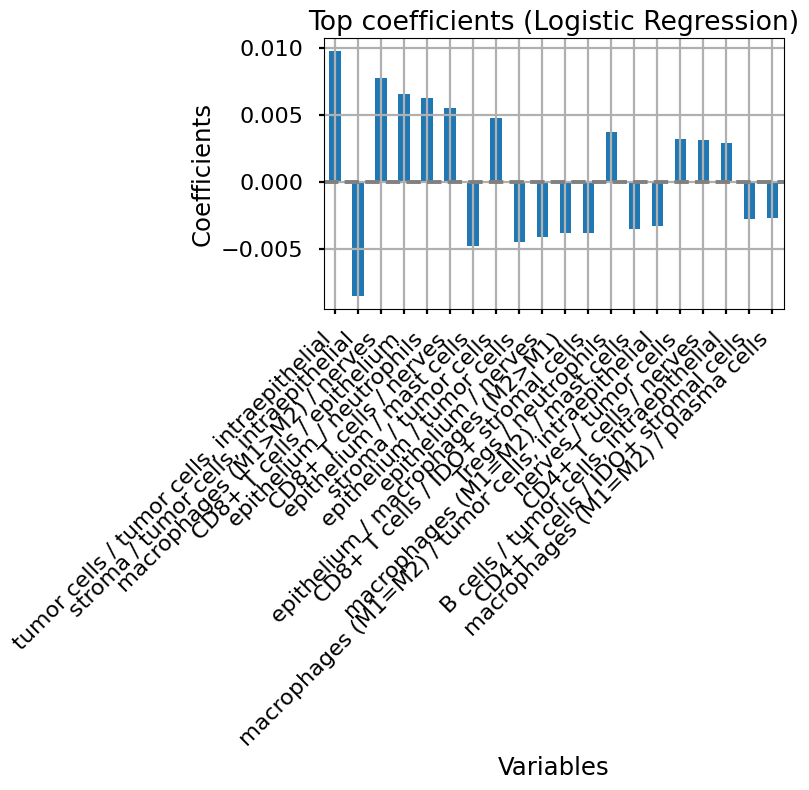

In [40]:
logistic_regression(prop_types_comp_cleaned, max_iter = 50, test_size= 0.4, l1_ratio=0.1)

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.80      0.57      0.67         7

    accuracy                           0.67        12
   macro avg       0.69      0.69      0.67        12
weighted avg       0.70      0.67      0.67        12

Accuracy (Test): 0.6666666666666666
Accuracy (Train): 0.7058823529411765


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


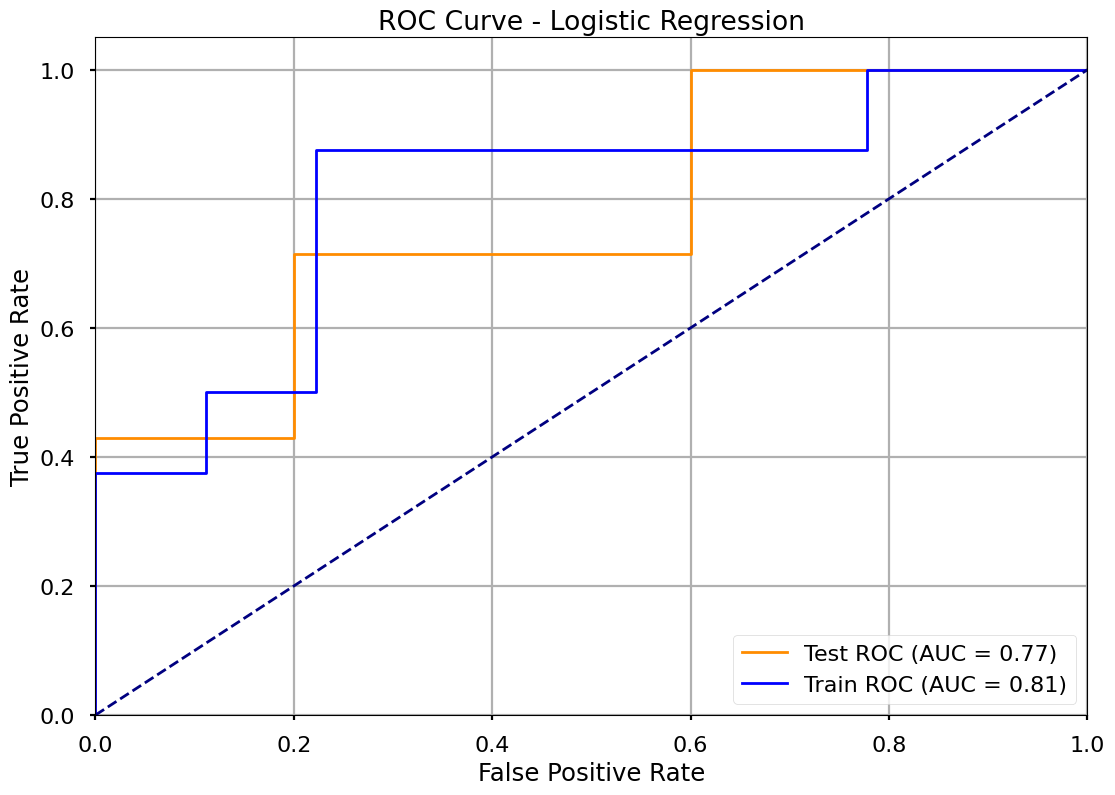

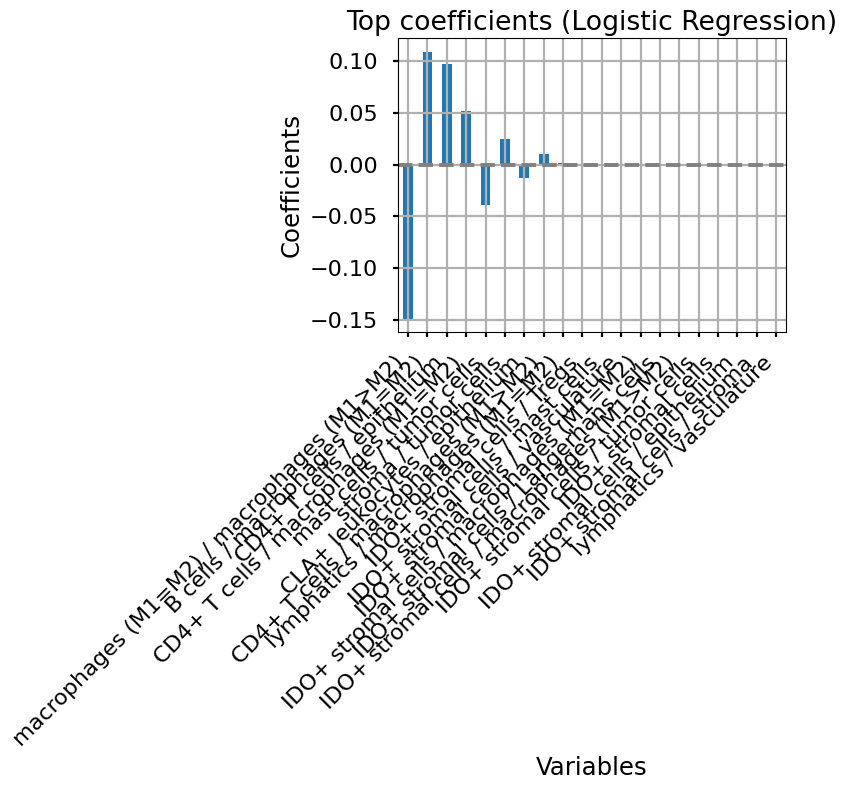

In [48]:
logistic_regression (prop_types_comp_cleaned[best_pval_names], max_iter=200,test_size=0.4, l1_ratio=0.1)

Top 20 variables sélectionnées par variance.


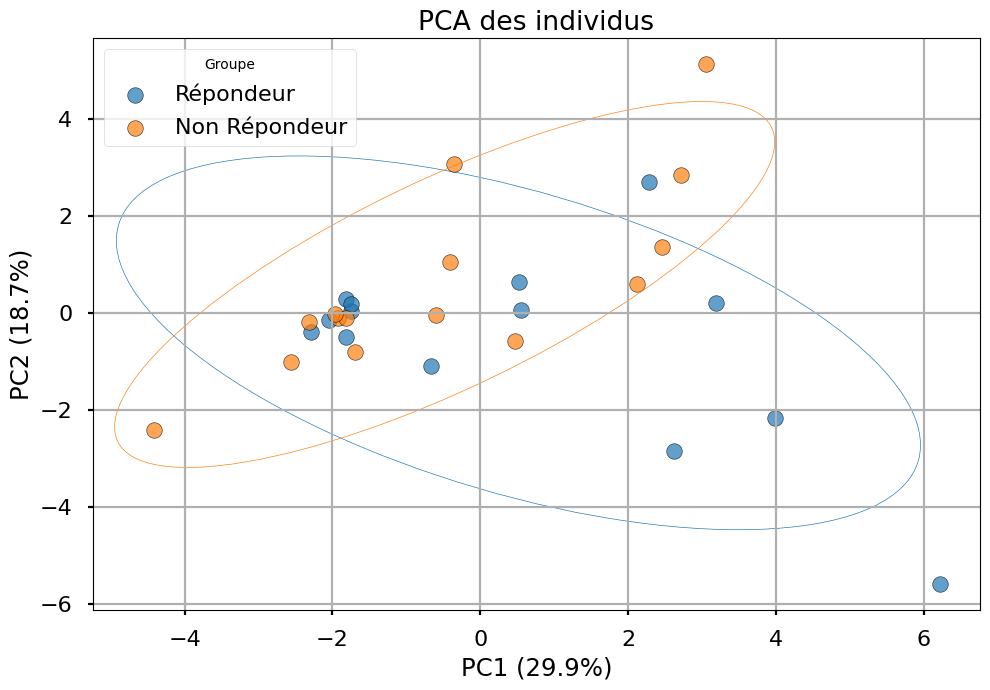

In [50]:
plot_pca(prop_types_comp_cleaned, n_vars=20)

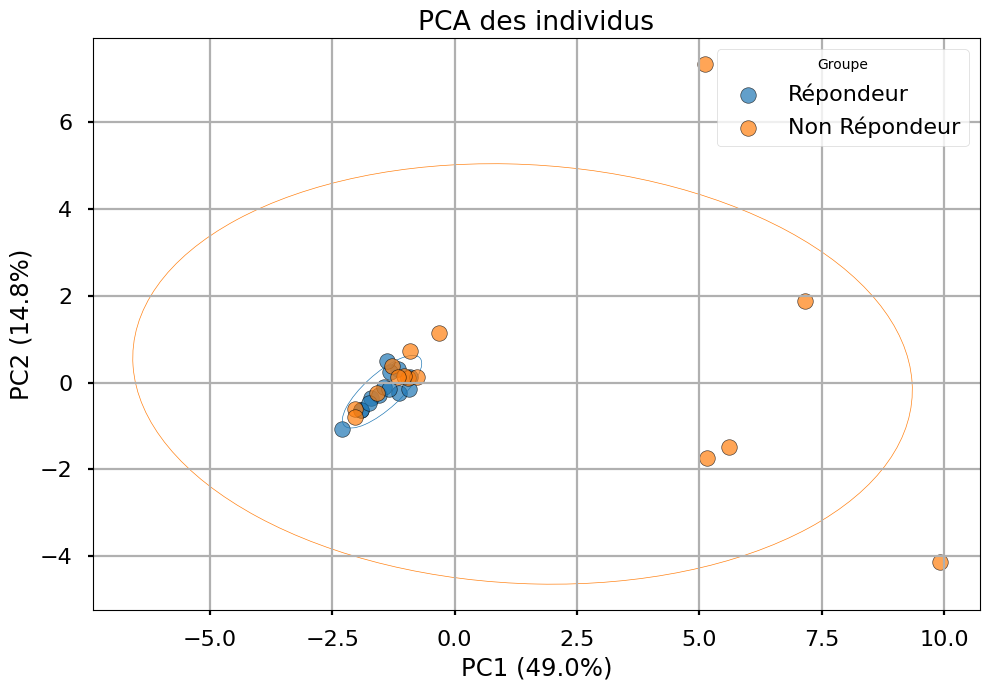

In [51]:
plot_pca (prop_types_comp_cleaned[best_pval_names])

### Proportions of cell type proportions

Simple ratios can be problematic as they can lead to extreme values, such as in the case of x/0. To avoid that, we use proportions instead, i.e. a / (a + b), so all values are between 0 and 1.

In [170]:
# `find_DE_markers` can make composite variables, but we do it beforehand to reuse them
composed_variables = mosna.make_composed_variables(prop_types, method='proportion', order=1)
prop_types_comp = pd.concat([prop_types, composed_variables], axis=1)
pvals = mosna.find_DE_markers(prop_types_comp, group_ref=1, group_tgt=2, group_var=group_col)

In [171]:
pd.set_option('display.max_rows', 20)
pvals.head(20)

,pval,pval_corr
lymphatics / ( lymphatics + macrophages (M1=M2) ),0.004079,0.696813
lymphatics / ( lymphatics + vasculature ),0.026224,0.696813
lymphatics / ( lymphatics + macrophages (M2>M1) ),0.040692,0.696813
tumor cells / ( tumor cells + vasculature ),0.053030,0.696813
CD8+ T cells / ( CD8+ T cells + IDO+ stromal cells ),0.053349,0.696813
IDO+ stromal cells / ( IDO+ stromal cells + macrophages (M2>M1) ),0.053349,0.696813
IDO+ stromal cells / ( IDO+ stromal cells + epithelium ),0.053349,0.696813
IDO+ stromal cells / ( IDO+ stromal cells + Tregs ),0.053349,0.696813
"IDO+ stromal cells / ( IDO+ stromal cells + tumor cells, intraepithelial )",0.053349,0.696813
nerves / ( nerves + tumor cells ),0.072844,0.696813


### Diminuer la longueur des légendes, les faire passer sur deux lignes pour pouvoir agrandir le graphique, + essayer de diminduer la largeur des boxplots si possible

In [173]:
# we need to clean-up data for further analyses and visualizations
# otherwise some visualization tools and ML models break with NaN

# with proportions of variables there are 3x fewer NaNs
prop_types_comp_cleaned, select_finite = mosna.clean_data(
    prop_types_comp, 
    method='mixed',
    thresh=0.9,
    )

There are 113 non finite values (3.5%)
Imputing data


In [174]:
pvals_cleaned = mosna.find_DE_markers(prop_types_comp_cleaned, group_ref=1, group_tgt=2, group_var=group_col)
pvals_cleaned.head(10)

,pval,pval_corr
lymphatics / ( lymphatics + macrophages (M1=M2) ),0.004079,0.829539
lymphatics / ( lymphatics + vasculature ),0.026224,0.829539
lymphatics / ( lymphatics + macrophages (M2>M1) ),0.040692,0.829539
tumor cells / ( tumor cells + vasculature ),0.053030,0.829539
lymphatics / ( lymphatics + macrophages (M1>M2) ),0.072844,0.829539
nerves / ( nerves + tumor cells ),0.072844,0.829539
lymphatics / ( lymphatics + stroma ),0.072844,0.829539
IDO+ stromal cells,0.075413,0.829539
IDO+ stromal cells / ( IDO+ stromal cells + tumor cells ),0.075413,0.829539
CD8+ T cells / ( CD8+ T cells + IDO+ stromal cells ),0.075413,0.829539


In [175]:
# Here there is no additional significant variable after data imputation, so we don't plot anything

# fig, ax = mosna.plot_distrib_groups(
#     prop_types_comp_cleaned, 
#     group_var=group_col,
#     groups=[1, 2], 
#     pval_data=pvals_cleaned, 
#     pval_col='pval', 
#     max_cols=20, 
#     multi_ind_to_col=True,
#     group_names=group_names,
#     )
# fig.suptitle("Cell type ratios per response group", y=1.0);
# plt.savefig(save_dir / f'{fig_step}-distributions_of_proportions_per_response_group_after_imputation.jpg', bbox_inches='tight', facecolor='white', dpi=600)

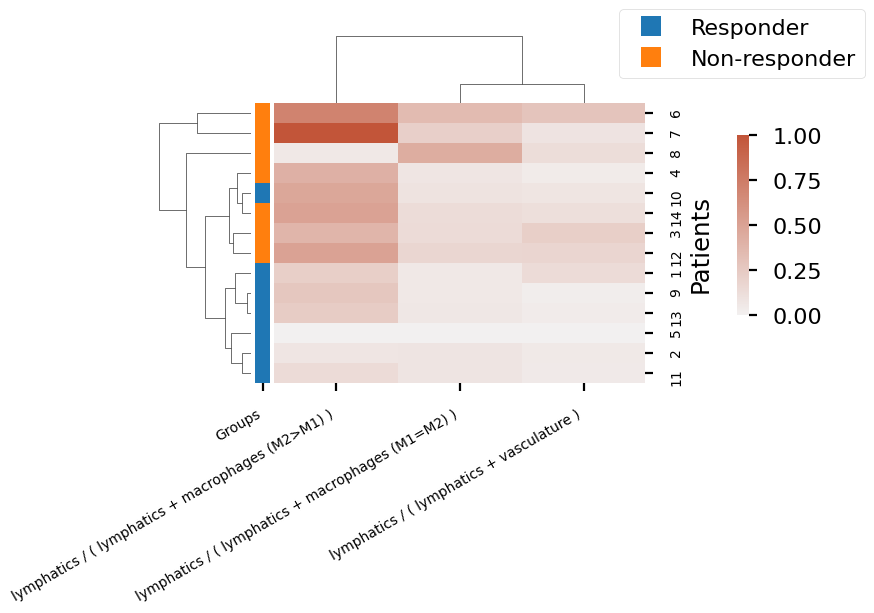

In [178]:
best_pval_names = pvals_cleaned.loc[pvals_cleaned['pval'] < 0.05, :].index
# or to select only 20 variables:
# best_pval_names = pvals.head(20).index
mosna.plot_heatmap(
    prop_types_comp_cleaned[best_pval_names].reset_index(), 
    obs_labels=patient_col, 
    group_var=group_col, 
    groups=[1, 2],
    z_score=None,
    figsize=(6, 10),
    group_names=group_names,
    cbar_pos=(1, 0.7, 0.02, 0.18),
    legend_opt={'loc': 'lower left', 'bbox_to_anchor': (0.9, 1.05)},
    # fontsize=15,
    );
plt.savefig(save_dir / f'{fig_step}-clustering_on_ratios_imputed_selected.jpg', bbox_inches='tight', facecolor='white', dpi=600)

Training took 6.375s


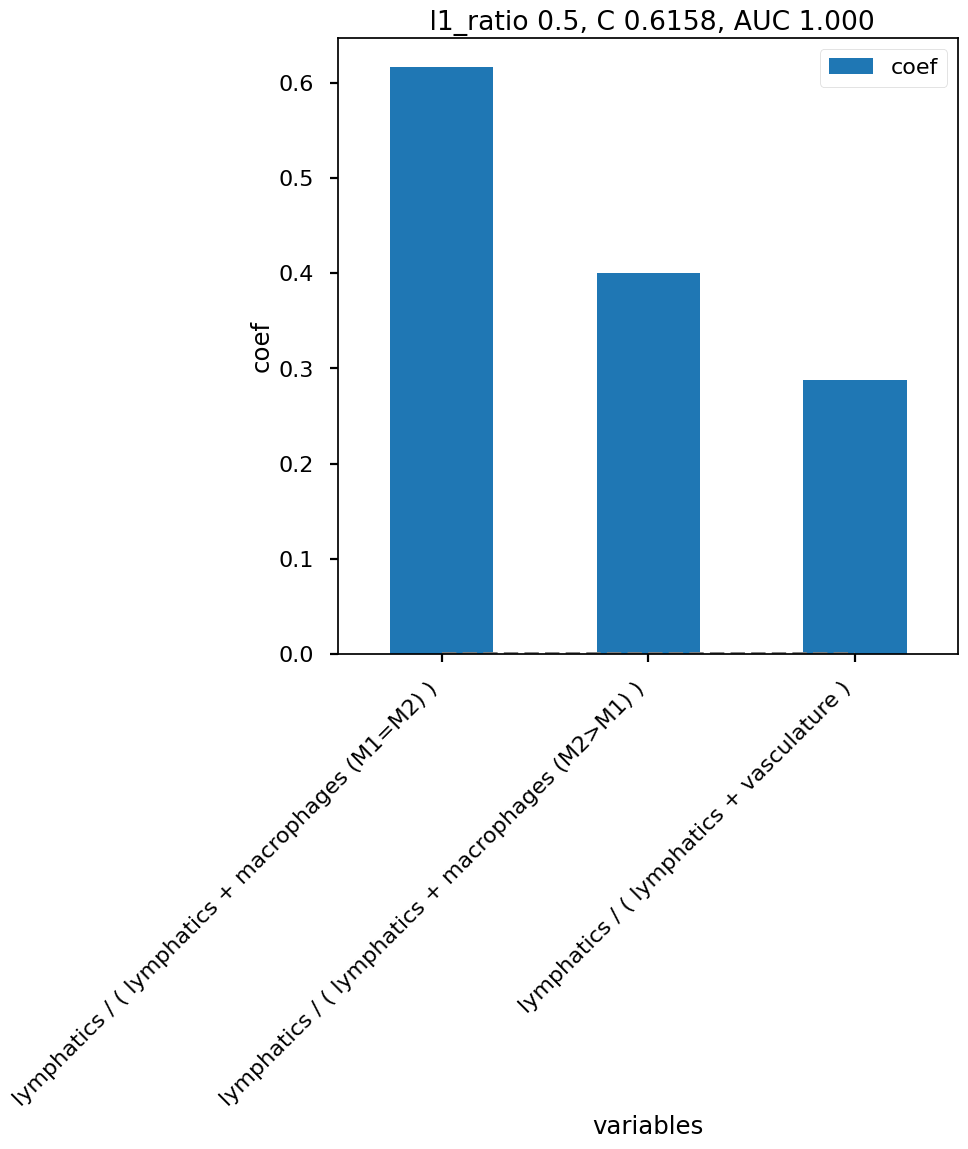

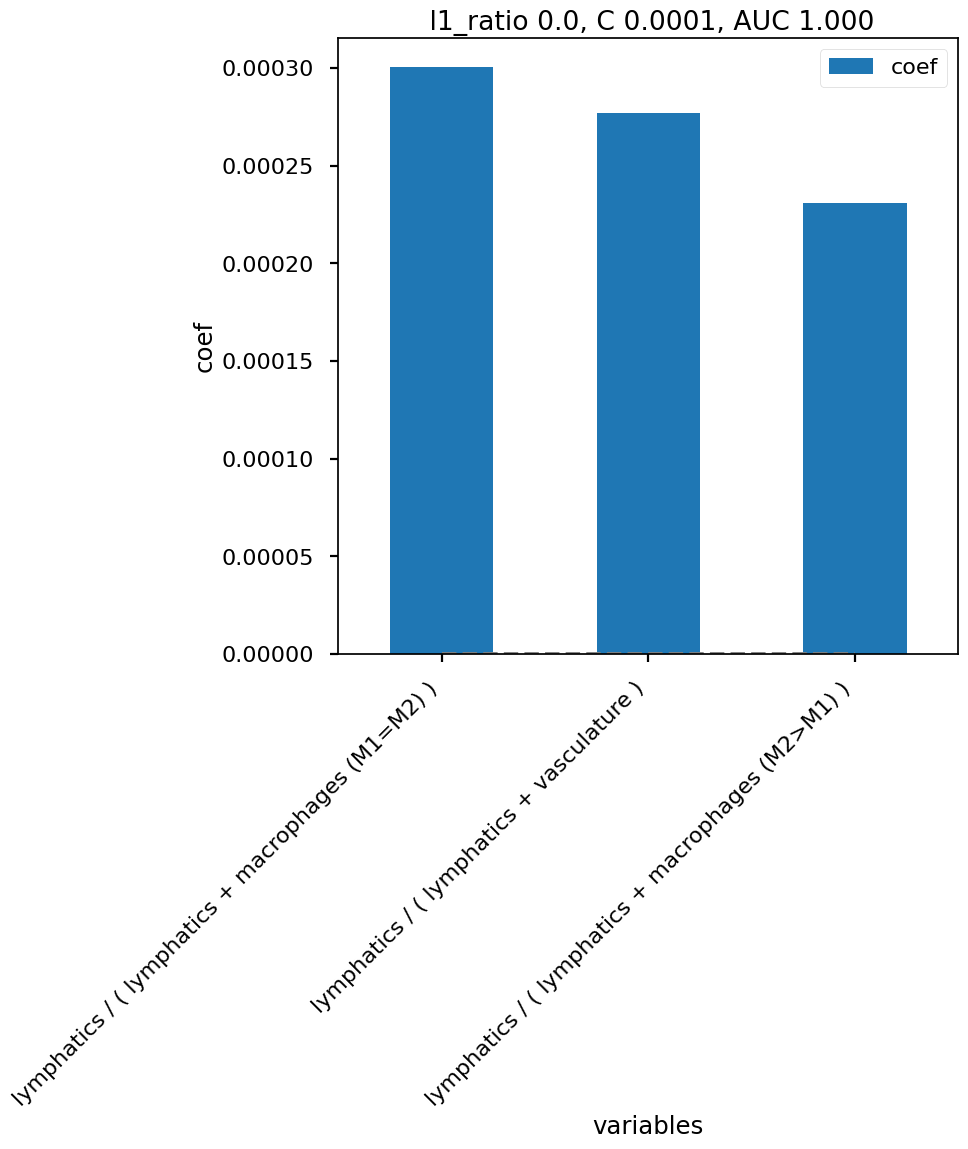

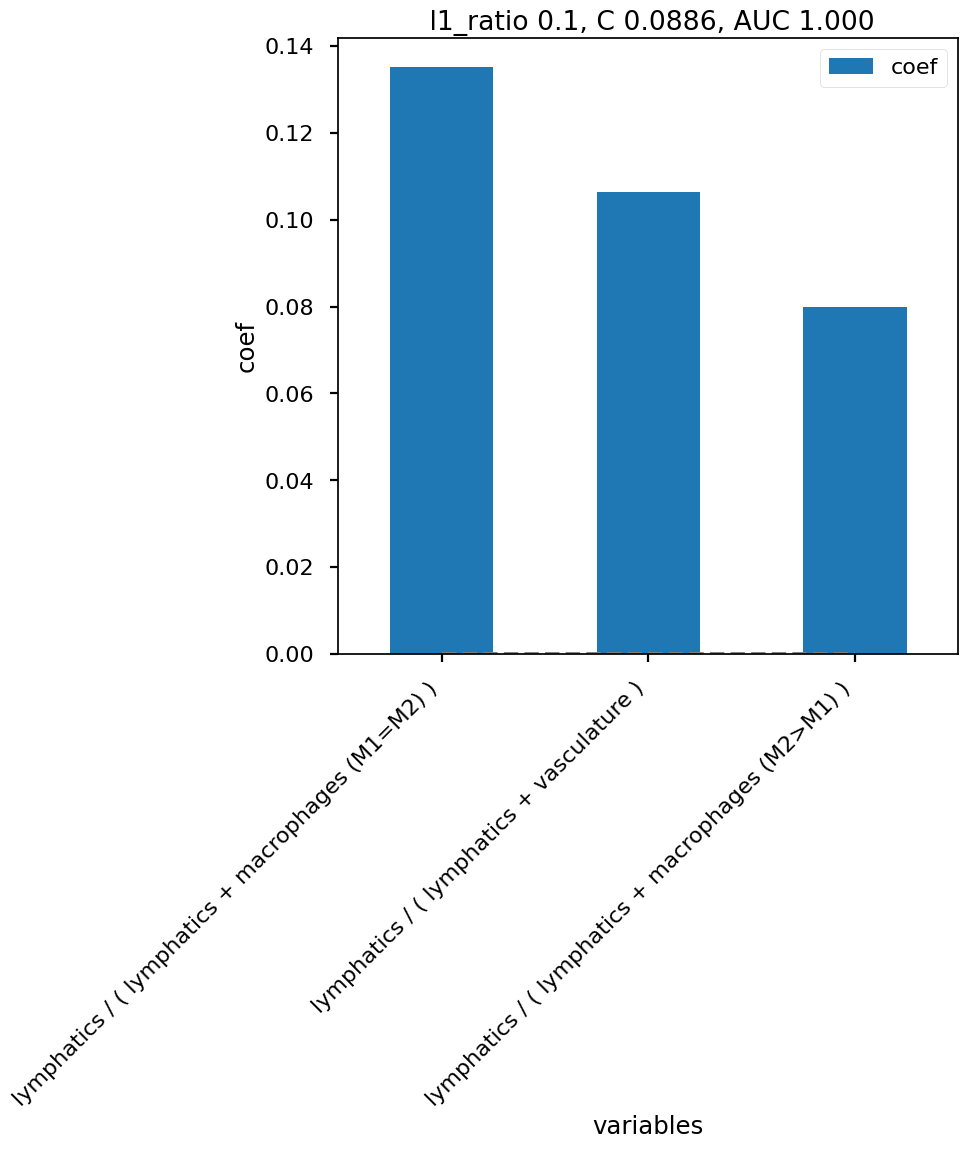

In [180]:
# Train ML model with best variables only

models = mosna.logistic_regression(
    prop_types_comp_cleaned[best_pval_names],
    y_name=group_col,
    col_drop=[patient_col],
    cv_train=cv_train, 
    cv_adapt=cv_adapt, 
    cv_max=cv_max,
    save_plot_figures=True,
    dir_save=save_dir,
    str_prefix=f'{fig_step}_on_ratios2_selected_',
    )

### Second order of cell types ratios

In [181]:
# `find_DE_markers` can make composite variables, but we do it beforehand to reuse them
composed_variables = mosna.make_composed_variables(prop_types, method='ratio', order=2)
prop_types_comp = pd.concat([prop_types, composed_variables], axis=1)
pvals = mosna.find_DE_markers(prop_types_comp, group_ref=1, group_tgt=2, group_var=group_col)

KeyboardInterrupt: 

In [ ]:
pvals.head(20)

In [ ]:
n_sig = (pvals['pval'] < 0.05).sum()
print(f'There are {n_sig} significant variables (non corrected)')

The first variables related to cell types proportions are composed variables of the 2nd order (ratio of ratios), only `lymphatics / macrophages (M1=M2)` appear in the simpler composed variables, but all corrected pvalues are > 0.05. This is because mosna produced *a lot* of composed variables.

In [ ]:
fig, ax = mosna.plot_distrib_groups(
    prop_types_comp, 
    group_var=group_col,
    groups=[1, 2], 
    pval_data=pvals, 
    pval_col='pval', 
    max_cols=20, 
    multi_ind_to_col=True,
    )

Some variables hide the distribution of other variables by their much larger range, we can exclude them to better see the other variables:

In [ ]:
# we need to clean-up data for further analyses and visualizations
prop_types_comp_cleaned, select_finite = mosna.clean_data(
    prop_types_comp, 
    method='mixed',
    thresh=0.9,
    )

In [ ]:
pvals = mosna.find_DE_markers(prop_types_comp_cleaned, group_ref=1, group_tgt=2, group_var=group_col)
pvals = pvals.sort_values(by='pval', ascending=True)

In [ ]:
n_sig = (pvals['pval'] < 0.05).sum()
print(f'There are {n_sig} significant variables (non corrected) after data imputation')

In [ ]:
pd.set_option('display.max_rows', None)
pvals.head(20)

In [ ]:
pd.set_option('display.max_rows', 10)

By selecting the variables with p-values under 5%, although their corresponding corrected p-values are not significant, we can notice a much better separation between patients groups.  
We must be careful though: we have computed a lot of composed variables, and selected those who happened to have the best p-values.

In [ ]:
models = mosna.logistic_regression(
    prop_types_comp_cleaned[best_pval_names], 
    y_name=group_col,
    col_drop=[patient_col], 
    cv_train=cv_train, 
    cv_adapt=cv_adapt, 
    cv_max=cv_max,
    save_plot_figures=True,
    dir_save=save_dir,
    str_prefix=f'{fig_step}_on_ratios_of_ratios_',
    )

We have seen that cell types proportions don't explain response of patient to therapy. But maybe interactions between cell types play a role in response?  
To answer this question we will look at the *mixing matrix* and *assortativity* of tissue networks.  

## Cell types interactions

We compute cell types interactions per sample to aggregate latter per patient or condition.

###  Assortativity and Mixing Matrix

#### Computation of assortativity

In [ ]:
grouping = sample_col
n_shuffle = 500
load_dir = reconst_dir
dir_assort = load_dir / "assortativity"
filename = dir_assort / f'network_interactions_stats_grouping-{grouping}_n_shuffle-{n_shuffle}.csv'

if RUN_LONG or not filename.exists():
    print("Computing z-scored assortativity")
    start = time()
    net_stats = mosna.groups_assort_mixmat(
        net_dir=reconst_dir, 
        attributes_col=pheno_col, 
        make_onehot=False,
        id_level_1='patient',
        id_level_2='sample', 
        extension='parquet',
        n_shuffle=n_shuffle,
        parallel_groups='max',  # or False
        memory_limit='2 GB',
        save_intermediate_results=True)
    end = time()
    duration = end - start
    print(f"Assortativity took {duration:.3f}s for n_suffle {n_shuffle}")

    net_stats.index = net_stats['id']
    net_stats.drop(columns=['id'], inplace=True)

    if not os.path.exists(dir_assort):
        os.makedirs(dir_assort)
    net_stats.to_csv(filename)
else:
    print("Loading z-scored assortativity")
    net_stats = pd.read_csv(filename, index_col=0)

fig_step = '03_assortativity_per_sample'

Computing z-scored assortativity



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<string>", line 1, in <module>
  File "/home/geremi/miniconda3/envs/mosna/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/home/geremi/miniconda3/envs/mosna/lib/python3.10/multiprocessing/spawn.py", line 129, in _main
    return self._bootstrap(parent_sentinel)
  File "/home/geremi/miniconda3/envs/mosna/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/geremi/miniconda3/envs/mosna/lib/python3.10/multip

Assortativity took 995.414s for n_suffle 500


In [ ]:
pd.set_option('display.max_rows', 10)
net_stats

,# total,% B cells,% CD4+ T cells,% CD8+ T cells,% Langerhans cells,% Tregs,% epithelium,% lymphatics,% macrophages (M1=M2),% macrophages (M1>M2),...,plasma cells - IDO+ stromal cells RAW,IDO+ stromal cells - B cells MEAN,neutrophils - IDO+ stromal cells MEAN,plasma cells - IDO+ stromal cells MEAN,IDO+ stromal cells - B cells STD,neutrophils - IDO+ stromal cells STD,plasma cells - IDO+ stromal cells STD,IDO+ stromal cells - B cells Z,neutrophils - IDO+ stromal cells Z,plasma cells - IDO+ stromal cells Z
id,,,,,,,,,,,,,,,,,,,,,
patient-10_sample-reg040,1317,0.002278,0.004556,0.024298,0.009112,0.044799,0.294609,0.005315,0.132118,0.114655,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-4_sample-reg014,1270,0.019685,0.003937,0.013386,0.007874,0.00315,0.340945,NaN,0.030709,0.074803,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-14_sample-reg058,1854,0.003776,0.009709,0.014563,0.012406,0.211435,0.242718,0.010248,0.047465,0.096009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-4_sample-reg013,1765,0.086686,0.008499,0.015864,0.003399,0.002833,0.265156,0.003966,0.027762,0.060623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-3_sample-reg010,1970,NaN,0.050254,0.036548,0.026396,0.02335,0.398985,0.008629,0.036548,0.076142,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
patient-10_sample-reg039,1225,0.003265,0.006531,0.033469,0.004898,0.04,0.288163,0.01551,0.083265,0.137143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-3_sample-reg009,2334,0.000857,0.046701,0.048843,0.033419,0.022708,0.416881,0.002999,0.03599,0.105827,...,0.0,0.0,NaN,0.000001,0.000003,NaN,0.000008,-0.044766,NaN,-0.100504
patient-14_sample-reg057,1166,0.006003,0.021441,0.066038,0.025729,0.202401,0.004288,0.001715,0.043739,0.110635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Example of Mixing Matrix

In [ ]:
sample_id = 'patient-1_sample-reg001'
raw_cols = [x for x in net_stats.columns if x.endswith('RAW') and not x.startswith('assort')]
z_cols = [x for x in net_stats.columns if x.endswith('Z') and not x.startswith('assort')]

mixmat_raw = mosna.series_to_mixmat(net_stats.loc[sample_id, raw_cols], discard=' RAW').astype(float)
mixmat_z = mosna.series_to_mixmat(net_stats.loc[sample_id, z_cols], discard=' Z').astype(float)
assort_raw = net_stats.loc[sample_id, "assort"]
assort_z = net_stats.loc[sample_id, "assort Z"]

# select_cols = np.logical_and(mixmat_raw.isna(axis=0) == 0, mixmat_z.isna(axis=0) == 0)

Raw assortativity by cell types: 0.18
Z-scored assortativity by cell types: 23.40


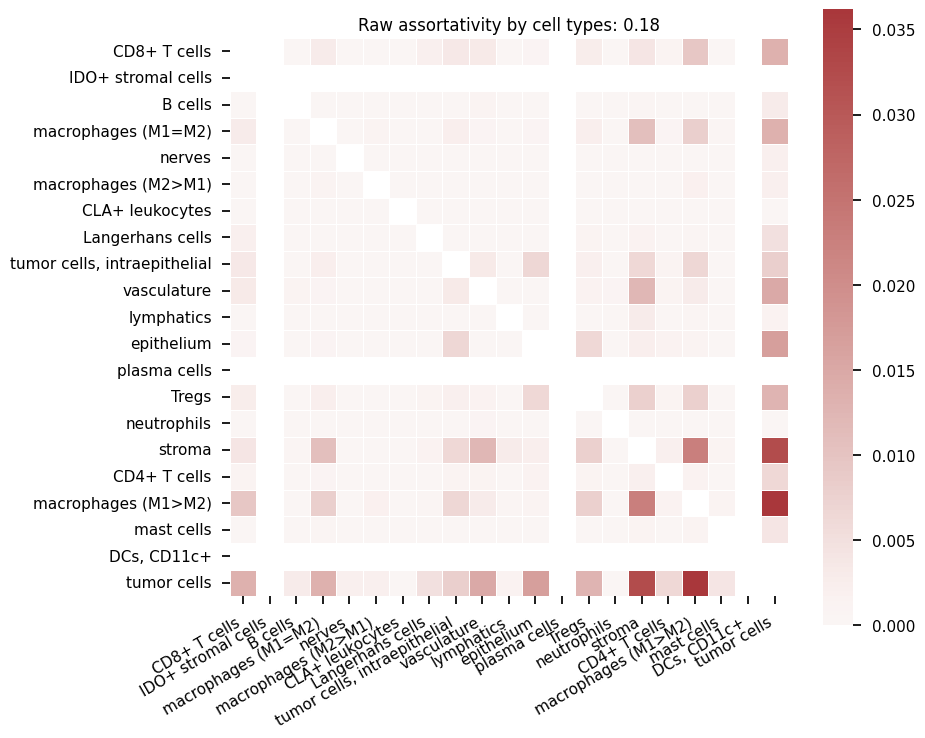

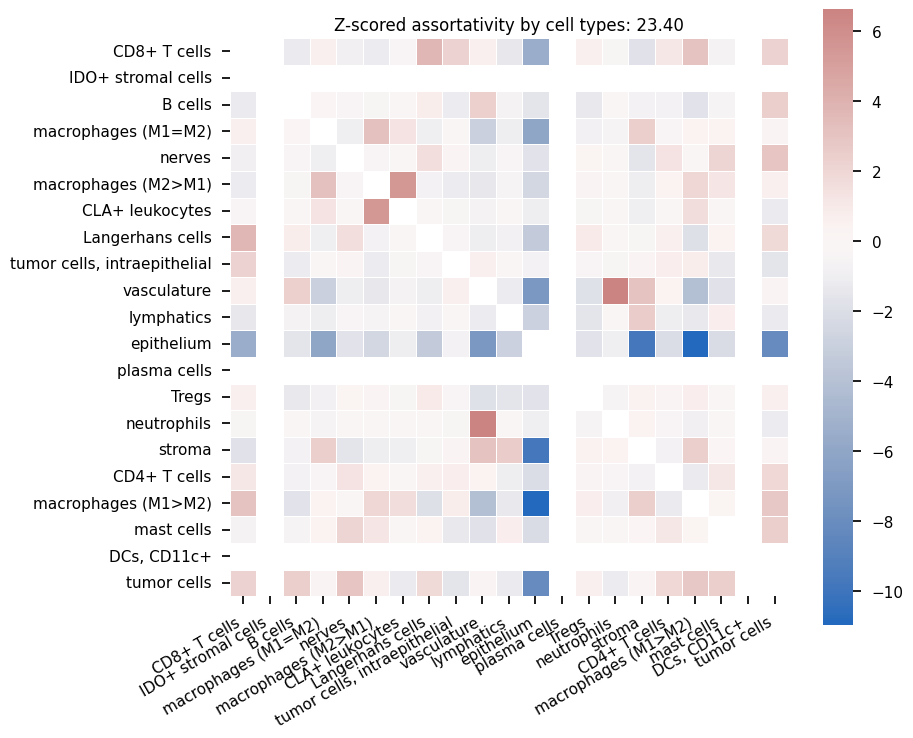

In [218]:
# Hide diagonal
# # Generate a mask for the upper triangle
# mask = np.triu(np.ones_like(mixmat_raw, dtype=bool))
# Generate a mask for the diagonal
mask = np.eye(mixmat_raw.shape[0], dtype=bool)

# sns.set_context('talk')
sns.set_context("notebook")
figsize = (9, 8)

title = "Raw assortativity by cell types: {:.2f}".format(assort_raw)
print(title)
f, ax = plt.subplots(figsize=figsize)
sns.heatmap(mixmat_raw, mask=mask, center=0, cmap="vlag", annot=False, square=True, linewidths=.5, ax=ax)
ax.set_title(title)
plt.xticks(rotation=30, ha='right');
plt.xticks(rotation=30, ha='right');#, fontsize=20);
# plt.yticks(fontsize=20);
plt.savefig(save_dir / f"{fig_step}_assortativity_raw_sample-{sample_id}_diagonal", bbox_inches='tight', facecolor='white')

title = "Z-scored assortativity by cell types: {:.2f}".format(assort_z)
print(title)
f, ax = plt.subplots(figsize=figsize)
sns.heatmap(mixmat_z, mask=mask, center=0, cmap="vlag", annot=False, square=True, linewidths=.5, ax=ax)
ax.set_title(title)
plt.xticks(rotation=30, ha='right');
plt.savefig(save_dir / f"{fig_step}_assortativity_z-scored_sample-{sample_id}_diagonal", bbox_inches='tight', facecolor='white')

In [ ]:
if RUN_LONG:
    for sample_id in net_stats.index:

        raw_cols = [x for x in net_stats.columns if x.endswith('RAW') and not x.startswith('assort')]
        z_cols = [x for x in net_stats.columns if x.endswith('Z') and not x.startswith('assort')]

        mixmat_raw = mosna.series_to_mixmat(net_stats.loc[sample_id, raw_cols], discard=' RAW').astype(float)
        mixmat_z = mosna.series_to_mixmat(net_stats.loc[sample_id, z_cols], discard=' Z').astype(float)
        assort_raw = net_stats.loc[sample_id, "assort"]
        assort_z = net_stats.loc[sample_id, "assort Z"]

        # sns.set_context('talk')
        sns.set_context("notebook")
        figsize = (9, 8)

        title = "Raw assortativity by cell types: {:.2f}".format(assort_raw)
        print(title)
        f, ax = plt.subplots(figsize=figsize)
        sns.heatmap(mixmat_raw, center=0, cmap="vlag", annot=False, linewidths=.5, ax=ax)
        ax.set_title(title)
        plt.xticks(rotation=30, ha='right');
        plt.xticks(rotation=30, ha='right');
        # plt.xticks(rotation=30, ha='right', fontsize=20);
        # plt.yticks(fontsize=20);
        plt.savefig(save_dir / f"assortativity_raw_{sample_id}", bbox_inches='tight', facecolor='white')

        title = "Z-scored assortativity by cell types: {:.2f}".format(assort_z)
        print(title)
        f, ax = plt.subplots(figsize=figsize)
        sns.heatmap(mixmat_z, center=0, cmap="vlag", annot=False, linewidths=.5, ax=ax)
        ax.set_title(title)
        plt.xticks(rotation=30, ha='right');
        plt.savefig(save_dir / "assortativity_z-scored_{sample_id}", bbox_inches='tight', facecolor='white')

        # Hide diagonal
        # # Generate a mask for the upper triangle
        # mask = np.triu(np.ones_like(mixmat_raw, dtype=bool))
        # Generate a mask for the diagonal
        mask = np.eye(mixmat_raw.shape[0], dtype=bool)

        # sns.set_context('talk')
        sns.set_context("notebook")
        figsize = (9, 8)

        title = "Raw assortativity by cell types: {:.2f}".format(assort_raw)
        print(title)
        f, ax = plt.subplots(figsize=figsize)
        sns.heatmap(mixmat_raw, mask=mask, center=0, cmap="vlag", annot=False, square=True, linewidths=.5, ax=ax)
        ax.set_title(title)
        plt.xticks(rotation=30, ha='right');
        plt.xticks(rotation=30, ha='right');#, fontsize=20);
        # plt.yticks(fontsize=20);
        plt.savefig(save_dir / f"assortativity_raw_{sample_id}_diagonal", bbox_inches='tight', facecolor='white')

        title = "Z-scored assortativity by cell types: {:.2f}".format(assort_z)
        print(title)
        f, ax = plt.subplots(figsize=figsize)
        sns.heatmap(mixmat_z, mask=mask, center=0, cmap="vlag", annot=False, square=True, linewidths=.5, ax=ax)
        ax.set_title(title)
        plt.xticks(rotation=30, ha='right');
        plt.savefig(save_dir / "assortativity_z-scored_{sample_id}_diagonal", bbox_inches='tight', facecolor='white')

After removing highly self-assortative cell-types, we can notice that ~~most cell types tend to avoid other cell types in this sample.~~

# Assortativity and patients response

In [189]:
z_cols = [x for x in net_stats.columns if x.endswith('Z')]
z_net_stats = net_stats[z_cols]

In [ ]:
z_net_stats.to_csv('/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process/pretreatment_samples_networks_xy_min_size-0_solitary-3/assortativity/M_M_global')

In [32]:
z_net_stats = pd.read_csv ('/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process/pretreatment_samples_networks_xy_min_size-0_solitary-3/assortativity/M_M_global', index_col= 0 )
z_net_stats

,assort Z,B cells - B cells Z,CD4+ T cells - B cells Z,CD4+ T cells - CD4+ T cells Z,CD8+ T cells - B cells Z,CD8+ T cells - CD4+ T cells Z,CD8+ T cells - CD8+ T cells Z,Langerhans cells - B cells Z,Langerhans cells - CD4+ T cells Z,Langerhans cells - CD8+ T cells Z,...,macrophages (M2>M1) - IDO+ stromal cells Z,mast cells - IDO+ stromal cells Z,nerves - IDO+ stromal cells Z,stroma - IDO+ stromal cells Z,tumor cells - IDO+ stromal cells Z,"tumor cells, intraepithelial - IDO+ stromal cells Z",vasculature - IDO+ stromal cells Z,IDO+ stromal cells - B cells Z,neutrophils - IDO+ stromal cells Z,plasma cells - IDO+ stromal cells Z
id,,,,,,,,,,,,,,,,,,,,,
patient-10_sample-reg040,47.373121,-0.156813,-0.261973,-0.261488,0.762673,0.250091,5.948726,-0.377047,1.335255,0.333333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-4_sample-reg014,46.301606,7.596524,-0.754354,-0.214535,-0.647140,1.039422,-0.777722,-0.991045,-0.429546,-0.915830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-14_sample-reg058,47.697650,-0.278960,-0.669385,0.683198,2.127269,1.286638,5.010030,0.882442,-1.222268,0.080840,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-4_sample-reg013,58.109504,24.442070,1.563820,3.204244,-2.064984,0.585197,0.659895,0.794877,1.301955,0.737113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-3_sample-reg010,52.830785,NaN,NaN,8.865137,NaN,-2.957335,8.063748,NaN,-0.362373,2.535871,...,-0.210214,-0.238919,-0.181818,-0.723307,1.581962,-0.585277,-0.405309,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
patient-10_sample-reg039,39.367081,17.367182,-0.400815,2.633942,3.840726,0.459349,0.191206,-0.333333,-0.419693,-1.079206,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient-3_sample-reg009,51.712912,NaN,-0.758091,6.070553,0.576871,1.009794,5.545749,-0.677016,0.988686,1.971417,...,-0.229416,-0.169725,-0.077693,-0.603590,1.651316,-0.688244,-0.261488,-0.044766,NaN,-0.100504
patient-14_sample-reg057,13.741738,2.459748,0.176978,-1.196626,1.022958,0.632521,1.641990,-1.035808,0.329421,0.029152,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
processed_dir

PosixPath('/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process')

In [57]:
# Have a look at nan values
for name, value in z_net_stats.isna().sum().items():
    print(name, ' ' * (52- len(name)), value)

assort Z                                              0
B cells - B cells Z                                   10
CD4+ T cells - B cells Z                              8
CD4+ T cells - CD4+ T cells Z                         6
CD8+ T cells - B cells Z                              7
CD8+ T cells - CD4+ T cells Z                         6
CD8+ T cells - CD8+ T cells Z                         5
Langerhans cells - B cells Z                          7
Langerhans cells - CD4+ T cells Z                     6
Langerhans cells - CD8+ T cells Z                     4
Langerhans cells - Langerhans cells Z                 4
Tregs - B cells Z                                     7
Tregs - CD4+ T cells Z                                6
Tregs - CD8+ T cells Z                                4
Tregs - Langerhans cells Z                            3
Tregs - Tregs Z                                       4
epithelium - B cells Z                                7
epithelium - CD4+ T cells Z                    

In [197]:
plt.style.use('seaborn-v0_8-notebook') #'seaborn-v0_8-notebook' or 'seaborn-v0_8-poster'

There are some nan values due to interactions between rare cell types that never happened.  
We can have a first look at the sample, but it would be more informative to have a look at samples before therapy, grouping them per patient.

In [58]:
# impute non finite values in data for further analyses and visualizations
z_net_stats_cleaned, select_finite = mosna.clean_data(
    z_net_stats, 
    method='mixed',
    thresh=0.8,
    )
print("Final z_net_stats shape:", z_net_stats_cleaned.shape)

There are 2373 non finite values (35.4%)
Imputing data
Final z_net_stats shape: (29, 191)


In [59]:
# Add back patient id to the network stats dataframe
def parse_patient(s):
    return s.split('_')[0][8:]

# if patient_col not in z_net_stats_cleaned.columns:
#     z_net_stats_cleaned[patient_col] = [parse_patient(s) for s in z_net_stats_cleaned.index]

# Add back sample id to the network stats dataframe
def parse_sample(s):
    return s.split('_')[1][7:]

# if sample_col not in z_net_stats_cleaned.columns:
#     z_net_stats_cleaned[sample_col] = [parse_sample(s) for s in z_net_stats_cleaned.index]
# z_net_stats_cleaned.index = z_net_stats_cleaned[sample_col]

z_net_stats_cleaned.index = [parse_sample(s) for s in z_net_stats_cleaned.index]
z_net_stats_cleaned.index.name = sample_col


In [194]:
z_net_stats_cleaned

,assort Z,B cells - B cells Z,CD4+ T cells - B cells Z,CD4+ T cells - CD4+ T cells Z,CD8+ T cells - B cells Z,CD8+ T cells - CD4+ T cells Z,CD8+ T cells - CD8+ T cells Z,Langerhans cells - B cells Z,Langerhans cells - CD4+ T cells Z,Langerhans cells - CD8+ T cells Z,...,macrophages (M1>M2) - CLA+ leukocytes Z,macrophages (M2>M1) - CLA+ leukocytes Z,mast cells - CLA+ leukocytes Z,nerves - CLA+ leukocytes Z,neutrophils - CLA+ leukocytes Z,plasma cells - CLA+ leukocytes Z,stroma - CLA+ leukocytes Z,tumor cells - CLA+ leukocytes Z,"tumor cells, intraepithelial - CLA+ leukocytes Z",vasculature - CLA+ leukocytes Z
FileName,,,,,,,,,,,,,,,,,,,,,
reg040,47.373121,-0.156813,-0.261973,-0.261488,0.762673,0.250091,5.948726,-0.377047,1.335255,0.333333,...,0.373273,0.449611,-0.335740,0.250861,-0.155067,-0.461323,1.057860,-0.516411,-0.607443,0.338824
reg014,46.301606,7.596524,-0.754354,-0.214535,-0.647140,1.039422,-0.777722,-0.991045,-0.429546,-0.915830,...,0.597476,0.694669,-0.310334,0.677378,-0.081262,0.033784,1.798696,-0.000672,0.045924,-0.901507
reg058,47.697650,-0.278960,-0.669385,0.683198,2.127269,1.286638,5.010030,0.882442,-1.222268,0.080840,...,-0.163311,-0.400709,-0.500533,-0.175863,-0.077693,-0.142857,2.166851,-0.319491,-0.239522,0.869873
reg013,58.109504,24.442070,1.563820,3.204244,-2.064984,0.585197,0.659895,0.794877,1.301955,0.737113,...,0.837823,0.603088,-0.283222,0.655138,-0.071524,-0.198962,1.284587,0.357614,-0.027598,-0.725615
reg010,52.830785,3.766442,-0.670709,8.865137,0.244736,-2.957335,8.063748,0.621887,-0.362373,2.535871,...,0.920477,-0.688814,-0.782619,-0.693623,-0.098301,-0.198758,1.792629,-0.513348,3.183657,0.312232
reg029,37.519237,-0.156813,1.581339,1.456763,-0.340693,2.780264,-0.351805,-0.214535,-0.423283,-0.336913,...,0.889056,0.808200,-0.135388,-0.918270,-0.966183,-0.151831,-1.100577,0.999025,-0.406887,-1.325041
reg051,45.689836,-0.089803,-0.480017,1.130731,-0.335480,0.881702,1.426758,1.651555,1.103344,-0.199095,...,1.406787,-0.214535,-0.294884,-0.169725,-0.424736,-0.275917,1.465396,-0.700623,-0.298872,-1.011888
reg006,15.343623,-0.342746,-0.379896,-0.163383,1.571017,-0.333608,3.260047,0.458192,1.376494,2.168006,...,-0.611593,0.421920,-0.238919,-0.407494,-0.169725,-0.357030,-0.602459,0.659293,-0.224544,-0.270220
reg041,33.358314,5.281633,-0.630850,-0.462358,0.855347,2.085407,3.300862,0.586123,0.118890,1.556375,...,0.760111,1.292881,-0.314095,0.200693,-0.366512,-0.550677,0.876887,-0.825652,-0.630208,0.445054


Let's add information about patients' group and time of biopsy

In [60]:
if sample_col in status.columns:
    status.index = status[sample_col]
    status.drop(columns=[sample_col], inplace=True)
    status.index.name = 'id'
if 'Count' in status.columns:
    status = status.drop(columns=['Count'])
# status.sort_values('Spots')
status

,Patients,Groups,Spots
FileName,,,
reg001,1,1,1
reg002,1,1,2
reg005,2,1,5
reg006,2,1,6
reg009,3,2,9
...,...,...,...
reg046,12,2,46
reg051,13,1,51
reg052,13,1,52


In [61]:
# pd.set_option('display.max_rows', 10)
# reg026 and reg044 not in biopsies
z_net_stats_cleaned = pd.concat([status, z_net_stats_cleaned], axis=1, join='inner')#.sort_values('Spots')
z_net_stats_cleaned.drop(columns=['Spots'], inplace=True)
z_net_stats_cleaned.index.name = sample_col
z_net_stats_cleaned

,Patients,Groups,assort Z,B cells - B cells Z,CD4+ T cells - B cells Z,CD4+ T cells - CD4+ T cells Z,CD8+ T cells - B cells Z,CD8+ T cells - CD4+ T cells Z,CD8+ T cells - CD8+ T cells Z,Langerhans cells - B cells Z,...,macrophages (M1>M2) - CLA+ leukocytes Z,macrophages (M2>M1) - CLA+ leukocytes Z,mast cells - CLA+ leukocytes Z,nerves - CLA+ leukocytes Z,neutrophils - CLA+ leukocytes Z,plasma cells - CLA+ leukocytes Z,stroma - CLA+ leukocytes Z,tumor cells - CLA+ leukocytes Z,"tumor cells, intraepithelial - CLA+ leukocytes Z",vasculature - CLA+ leukocytes Z
FileName,,,,,,,,,,,,,,,,,,,,,
reg001,1,1,24.190942,1.134907,-1.243968,-0.678786,0.860589,2.366711,1.573080,1.344357,...,0.071937,-1.022584,-0.328124,-0.651496,-1.106672,-1.659605,-1.175809,-0.504106,-1.065578,3.521080
reg002,1,1,12.379904,-0.375650,3.270044,1.400757,-1.251090,2.228154,2.902544,-0.681232,...,-1.233805,-0.192801,-0.344592,-0.701626,-0.465250,-0.506037,0.836719,-1.797433,0.703797,1.187530
reg005,2,1,3.043484,0.139458,0.729398,0.279345,0.505833,1.341190,1.628415,-0.324010,...,-0.438484,0.098409,0.526577,-0.391789,0.063673,-0.412022,0.210534,-0.716870,-0.081757,0.422466
reg006,2,1,15.343623,-0.342746,-0.379896,-0.163383,1.571017,-0.333608,3.260047,0.458192,...,-0.611593,0.421920,-0.238919,-0.407494,-0.169725,-0.357030,-0.602459,0.659293,-0.224544,-0.270220
reg009,3,2,51.712912,3.891996,-0.758091,6.070553,0.576871,1.009794,5.545749,-0.677016,...,-0.207997,1.874686,-0.316641,-0.175863,-0.083802,-0.156813,-1.219271,0.225850,-0.540277,-0.539420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,12,2,23.398796,6.026715,-0.766431,-0.870370,-1.219096,1.164041,0.593253,0.812697,...,1.616956,5.500000,-0.241050,-0.142857,-0.044766,-0.437031,-0.955827,-1.246885,-0.515660,-0.601507
reg051,13,1,45.689836,-0.089803,-0.480017,1.130731,-0.335480,0.881702,1.426758,1.651555,...,1.406787,-0.214535,-0.294884,-0.169725,-0.424736,-0.275917,1.465396,-0.700623,-0.298872,-1.011888
reg052,13,1,47.704148,-0.119159,-0.394176,0.748555,-0.238919,-0.549152,-0.198749,-0.590616,...,-1.159249,-0.370203,-0.198749,1.637557,0.959654,-0.219586,2.909902,1.277193,2.136550,-0.664411


In [65]:
dir_assort = '/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process/pretreatment_samples_networks_xy_min_size-0_solitary-3/assortativity/'

In [67]:
z_net_stats_cleaned.to_csv('/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process/pretreatment_samples_networks_xy_min_size-0_solitary-3/assortativity/assortativity_per_sample.csv')

In [33]:
z_net_stats_cleaned = pd.read_csv ('/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process/pretreatment_samples_networks_xy_min_size-0_solitary-3/assortativity/assortativity_per_sample.csv', index_col=0)

In [34]:
z_net_stats_cleaned = z_net_stats_cleaned.set_index(group_col, append=True)


In [35]:
z_net_stats_cleaned = z_net_stats_cleaned.drop("Patients" , axis=1)
z_net_stats_cleaned = z_net_stats_cleaned.drop("assort Z" , axis=1)
z_net_stats_cleaned

,,B cells - B cells Z,CD4+ T cells - B cells Z,CD4+ T cells - CD4+ T cells Z,CD8+ T cells - B cells Z,CD8+ T cells - CD4+ T cells Z,CD8+ T cells - CD8+ T cells Z,Langerhans cells - B cells Z,Langerhans cells - CD4+ T cells Z,Langerhans cells - CD8+ T cells Z,Langerhans cells - Langerhans cells Z,...,macrophages (M1>M2) - CLA+ leukocytes Z,macrophages (M2>M1) - CLA+ leukocytes Z,mast cells - CLA+ leukocytes Z,nerves - CLA+ leukocytes Z,neutrophils - CLA+ leukocytes Z,plasma cells - CLA+ leukocytes Z,stroma - CLA+ leukocytes Z,tumor cells - CLA+ leukocytes Z,"tumor cells, intraepithelial - CLA+ leukocytes Z",vasculature - CLA+ leukocytes Z
FileName,Groups,,,,,,,,,,,,,,,,,,,,,
reg001,1,1.134907,-1.243968,-0.678786,0.860589,2.366711,1.573080,1.344357,-1.284031,1.420423,0.064685,...,0.071937,-1.022584,-0.328124,-0.651496,-1.106672,-1.659605,-1.175809,-0.504106,-1.065578,3.521080
reg002,1,-0.375650,3.270044,1.400757,-1.251090,2.228154,2.902544,-0.681232,-0.417920,0.570735,0.808659,...,-1.233805,-0.192801,-0.344592,-0.701626,-0.465250,-0.506037,0.836719,-1.797433,0.703797,1.187530
reg005,1,0.139458,0.729398,0.279345,0.505833,1.341190,1.628415,-0.324010,0.126600,0.311743,1.385462,...,-0.438484,0.098409,0.526577,-0.391789,0.063673,-0.412022,0.210534,-0.716870,-0.081757,0.422466
reg006,1,-0.342746,-0.379896,-0.163383,1.571017,-0.333608,3.260047,0.458192,1.376494,2.168006,-0.822662,...,-0.611593,0.421920,-0.238919,-0.407494,-0.169725,-0.357030,-0.602459,0.659293,-0.224544,-0.270220
reg009,2,3.891996,-0.758091,6.070553,0.576871,1.009794,5.545749,-0.677016,0.988686,1.971417,2.640220,...,-0.207997,1.874686,-0.316641,-0.175863,-0.083802,-0.156813,-1.219271,0.225850,-0.540277,-0.539420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,2,6.026715,-0.766431,-0.870370,-1.219096,1.164041,0.593253,0.812697,0.657941,3.694238,5.569688,...,1.616956,5.500000,-0.241050,-0.142857,-0.044766,-0.437031,-0.955827,-1.246885,-0.515660,-0.601507
reg051,1,-0.089803,-0.480017,1.130731,-0.335480,0.881702,1.426758,1.651555,1.103344,-0.199095,2.660568,...,1.406787,-0.214535,-0.294884,-0.169725,-0.424736,-0.275917,1.465396,-0.700623,-0.298872,-1.011888
reg052,1,-0.119159,-0.394176,0.748555,-0.238919,-0.549152,-0.198749,-0.590616,0.105397,-0.711791,5.307921,...,-1.159249,-0.370203,-0.198749,1.637557,0.959654,-0.219586,2.909902,1.277193,2.136550,-0.664411


In [36]:
pvals3 = mosna.find_DE_markers(z_net_stats_cleaned, group_ref=2, group_tgt=1, group_var = z_net_stats_cleaned.index.get_level_values('Groups'))
best_pval_names = pvals3.head(20).index

In [ ]:
models = mosna.logistic_regression(
    z_net_stats_cleaned,
    y_name=group_col,
    col_drop=[sample_col, patient_col],
    cv_train=cv_train, 
    cv_adapt=cv_adapt, 
    cv_max=cv_max,
    save_plot_figures=True,
    dir_save=save_dir,
    str_prefix=f'{fig_step}_',
    )

In [81]:
len(best_pval_names)

20

In [24]:
z_net_stats_cleaned [best_pval_names]

,,plasma cells - CLA+ leukocytes Z,vasculature - vasculature Z,lymphatics - B cells Z,plasma cells - macrophages (M2>M1) Z,nerves - CD4+ T cells Z,tumor cells - nerves Z,"tumor cells, intraepithelial - B cells Z",mast cells - lymphatics Z,plasma cells - neutrophils Z,macrophages (M1=M2) - lymphatics Z,vasculature - CLA+ leukocytes Z,Tregs - CLA+ leukocytes Z,vasculature - tumor cells Z,tumor cells - tumor cells Z,nerves - Langerhans cells Z,mast cells - Langerhans cells Z,lymphatics - Langerhans cells Z,CLA+ leukocytes - B cells Z,neutrophils - macrophages (M1>M2) Z,nerves - B cells Z
FileName,Groups,,,,,,,,,,,,,,,,,,,,
reg001,1,-1.659605,13.057826,2.263928,-0.100286,-0.754759,-0.809686,0.711362,-0.392232,0.329340,-2.278864,3.521080,1.776472,-0.577223,5.762444,0.444105,-0.442315,-1.204341,0.813928,-0.316023,-0.890154
reg002,1,-0.506037,12.025998,-0.448616,-0.013847,2.706018,-1.723903,1.677698,-0.384297,-0.853473,-0.888859,1.187530,-1.712346,-2.776964,2.444617,-0.061247,-0.550348,-0.617620,-0.459113,0.735977,1.689083
reg005,1,-0.412022,5.045250,-0.325441,-0.343385,1.115307,-1.361647,0.494786,1.371451,0.812569,-0.566525,0.422466,-0.817242,-1.781775,-0.519594,-0.544041,1.410527,0.958968,0.098695,0.216615,0.020013
reg006,1,-0.357030,9.627806,-0.478663,-0.713289,-0.409271,-1.922572,2.458286,-0.270562,5.031480,-0.899198,-0.270220,-0.607535,-4.619045,13.932369,0.439679,1.930739,-0.701849,-0.356034,2.033942,-0.579451
reg009,2,-0.156813,13.412089,-0.225245,1.606967,-0.943831,-0.102935,1.232412,-0.445489,-0.059364,3.134758,-0.539420,1.985137,6.065588,9.578975,0.636763,-0.801559,1.667876,-0.149983,0.321011,-0.127515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,2,-0.437031,14.372614,-0.599683,0.124939,1.289911,2.972316,-1.183610,0.722969,-0.258602,-1.113342,-0.601507,-0.508525,0.304631,1.877060,1.547227,0.383139,-0.861886,-0.193247,-0.905955,-0.358703
reg051,1,-0.275917,14.989882,-0.446562,-0.461463,-0.532736,4.477996,-0.248135,-0.635228,0.419132,-0.094894,-1.011888,-0.354593,-0.638525,11.801733,1.083137,-1.054031,-0.060755,-0.149983,0.724116,7.386173
reg052,1,-0.219586,8.204641,-0.169725,-0.224544,1.315821,-0.719670,-0.267506,-0.187608,-0.397457,-0.722978,-0.664411,-0.780789,2.791629,10.987304,-1.146353,-0.545308,0.972203,-0.204980,4.041090,-0.390702


Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.75      0.86      0.80         7

    accuracy                           0.75        12
   macro avg       0.75      0.73      0.73        12
weighted avg       0.75      0.75      0.74        12

Accuracy (Test): 0.75
Accuracy (Train): 0.8235294117647058


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


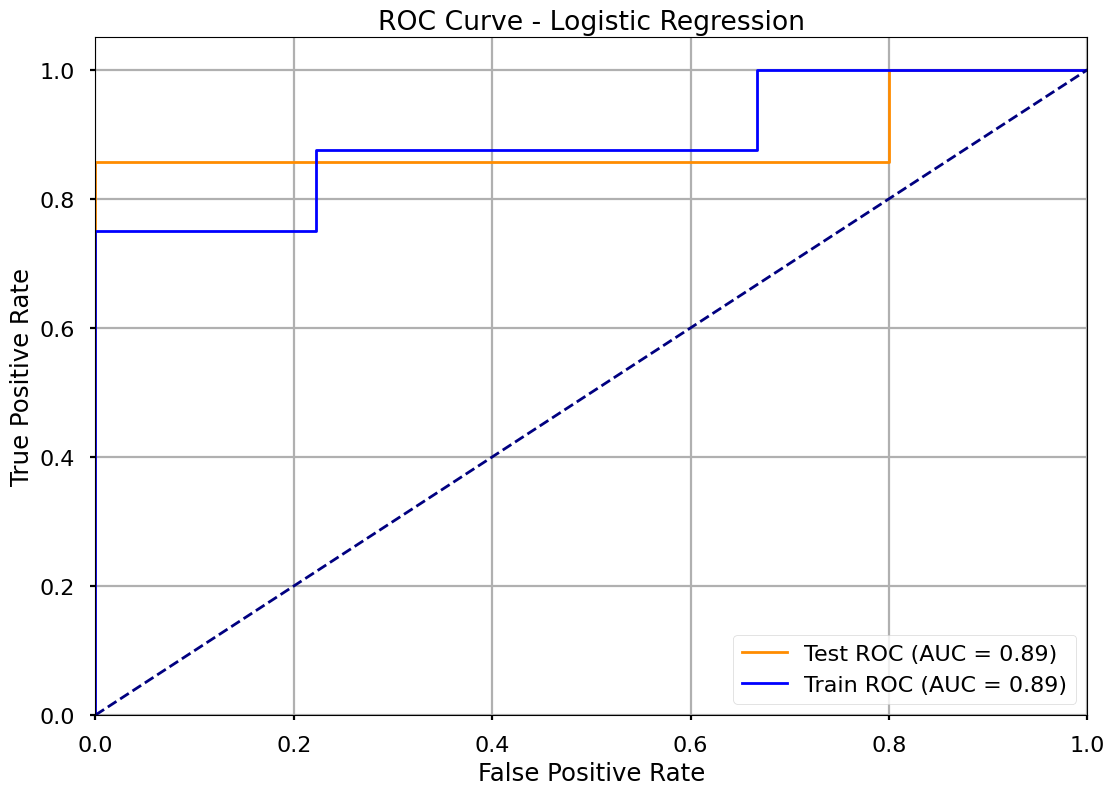

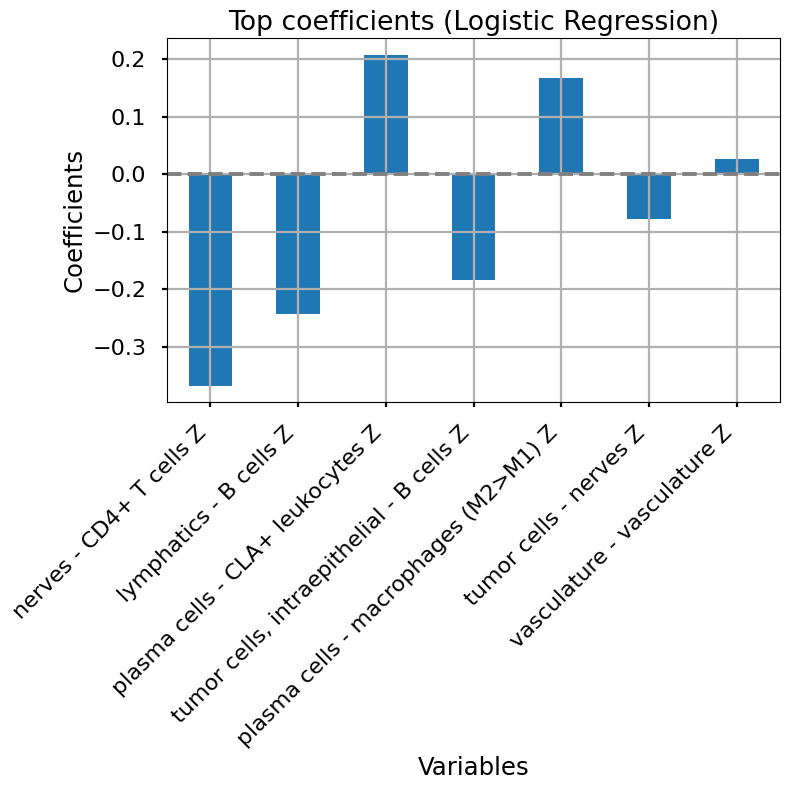

LogisticRegression(l1_ratio=0.1, max_iter=40, penalty='elasticnet',
                   solver='saga')

In [37]:
logistic_regression (z_net_stats_cleaned[pvals3.head(7).index], max_iter=40, test_size= 0.4, l1_ratio= 0.1)

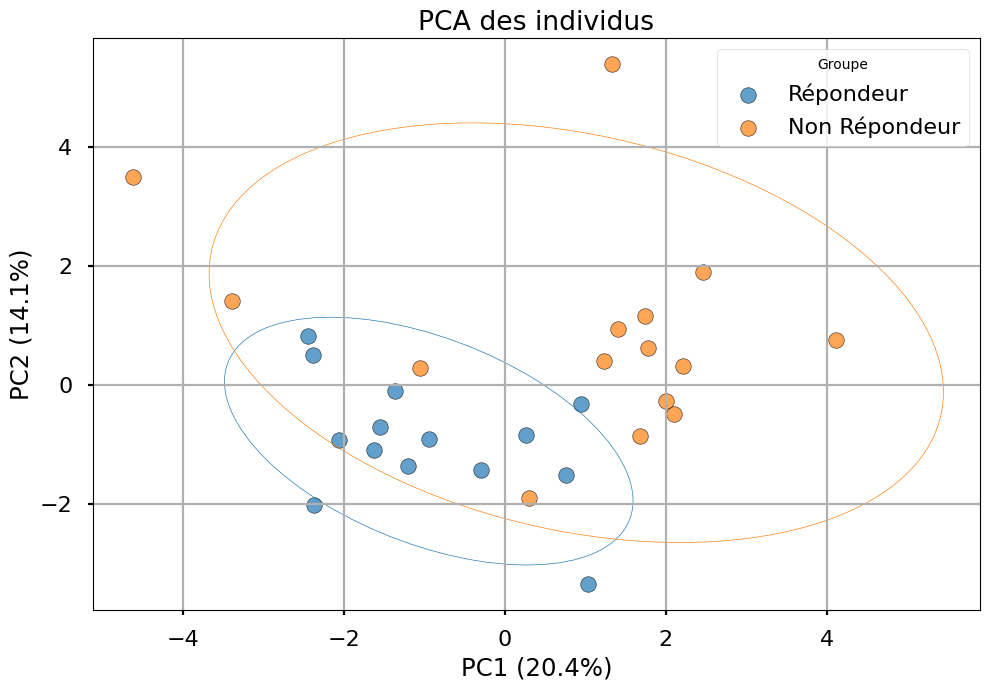

In [26]:
plot_pca (z_net_stats_cleaned[best_pval_names])

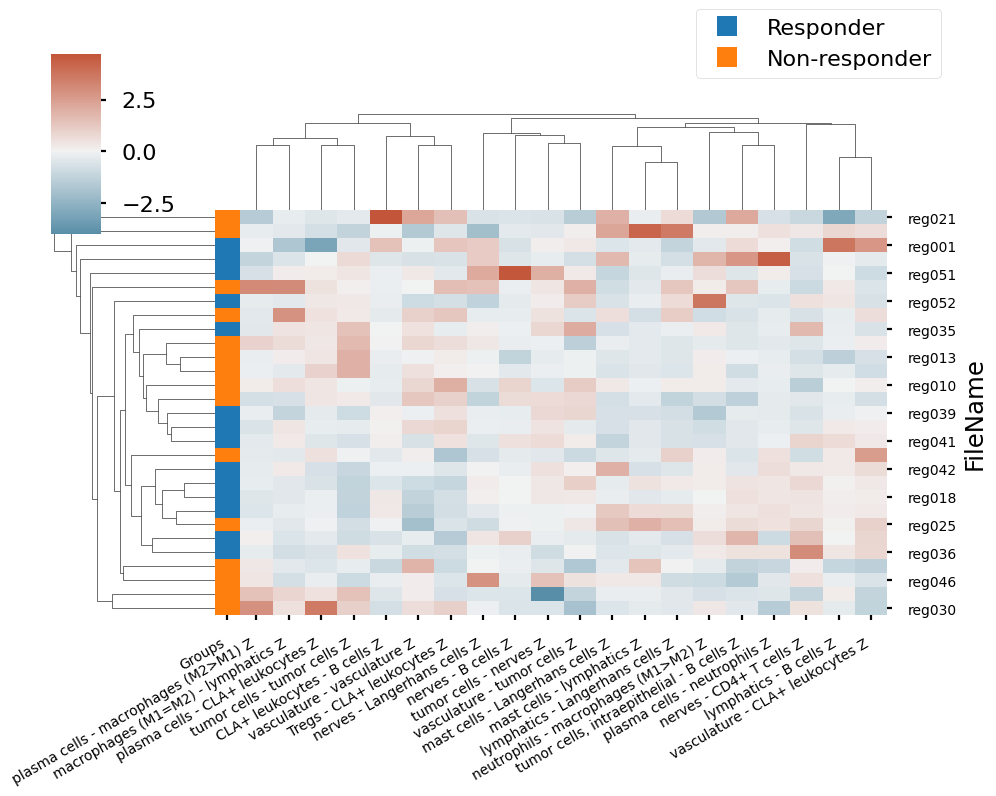

In [27]:
mosna.plot_heatmap(
    z_net_stats_cleaned[best_pval_names].reset_index(), 
    obs_labels= sample_col, 
    group_var=group_col, 
    groups=[1, 2],
    z_score=1,
    group_names=group_names,
    cbar_pos=(0.02, 0.86, 0.05, 0.18),
    legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.1, 1.3)},
    )

## Cellular neighborhoods

The mixing matrix and assortativity give us information about the global network organization.  
Here we will see how to use the *Neighbors Aggregation Statistics* method to find local "cellular communities", or "neighborhoods", or "niches", that can be relevant to understand disease progression or response to therapies.  

#### re-initialization

In [ ]:
# For WIP and avoid re-executing individual cells, to be deleted...

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from time import time
import joblib
from pathlib import Path
from time import time
from tqdm import tqdm
import copy
import matplotlib as mpl
import napari
import colorcet as cc
import composition_stats as cs
from sklearn.impute import KNNImputer

from tysserand import tysserand as ty
from mosna import mosna

import matplotlib as mpl
mpl.rcParams["figure.facecolor"] = 'white'
mpl.rcParams["axes.facecolor"] = 'white'
mpl.rcParams["savefig.facecolor"] = 'white'

# If need to reload modules after their modification
from importlib import reload
ty = reload(ty)
mosna = reload(mosna)

RUN_LONG = False

data_dir = Path("../data/raw/CODEX_CTCL")
try:
    objects_path = data_dir / "41467_2021_26974_MOESM3_ESM_-_Objects.parquet"
    obj = pd.read_parquet(data_dir / "41467_2021_26974_MOESM3_ESM_-_Objects.parquet")
except FileNotFoundError:
    objects_path = data_dir / "41467_2021_26974_MOESM3_ESM_-_Objects.xlsx"
    obj = pd.read_excel(objects_path, skiprows=2)
    # for latter use
    obj.to_parquet(data_dir / "41467_2021_26974_MOESM3_ESM_-_Objects.parquet")

# sample_cols = obj.columns[:10]
obj.rename(columns={'X': 'x', 'Y': 'y', 'Z':'z', 'ClusterName': 'cell type'}, inplace=True)
patient_col = 'Patients'
sample_col = 'FileName'
group_col = 'Groups'
pos_cols = ['x', 'y']
pheno_col = 'cell type'  # unique columns with all cell types
sample_cols = [sample_col, pheno_col, patient_col, 'Spots' ,group_col]
marker_cols = obj.columns[9:67]
marker_cols = [x for x in marker_cols if x != 'HOECHST1:Cyc_1_ch_1']
# pos_cols = obj.columns[69:76]
# slices are 5µm thick, so data is pseudo-2D, including z leads to spatial networks reconstruction artifacts
cell_type_cols = list(obj.columns[75:96]) # one-hot encoded cell types
marker_posit_cols = list(obj.columns[100:-1])
all_cols = sample_cols + marker_cols + pos_cols + cell_type_cols + marker_posit_cols
net_cols = pos_cols + [pheno_col] + cell_type_cols + marker_cols
nb_clusters = obj[pheno_col].unique().size

# Select only pre-treatment samples
obj = obj.loc[obj[group_col] < 3, :]
obj.index = np.arange(len(obj))

code_groups = {
  1: 'Responder, pre-treatment',
  2: 'Non-responder, pre-treatment',
  3: 'Responder, post-treatment',
  4: 'Non-responder, post-treatment',
} 

status_path = data_dir / "41467_2021_26974_MOESM5_ESM - Patients_spots_conditons.xlsx"
# status = pd.read_excel(status_path, skiprows=2, usecols=[patient_col, group_col, 'Spots'])
# # samples 5, 25, 36, 37, 40, 44 are missing
# # now inferred from updated data at https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-021-26974-6/MediaObjects/41467_2021_26974_MOESM1_ESM.pdf
# updated_data = [
#     [2, 1, 5],
#     [7, 2, 25],
#     [9, 1, 36],
#     [9, 3, 37],
#     [10, 1, 40],
#     [11, 3, 44],
#     ]
# status = pd.concat([status, pd.DataFrame(updated_data, columns=status.columns)], axis=0)

# status[sample_col] = status['Spots'].apply(lambda x: f'reg{x:03}')
# # pd.set_option('display.max_rows', 100)

# if sample_col in status.columns:
#     status.index = status[sample_col]
#     status.drop(columns=[sample_col], inplace=True)
#     status.index.name = 'id'
# status.sort_values('Spots')

# When status had too many missing values after first data release:
# we make a status dataframe from the objects dataframe
status = obj[[sample_col, patient_col, group_col, 'Count', 'Spots']].groupby([patient_col, group_col, 'Spots', sample_col]).count().reset_index()
if sample_col in status.columns:
    status.index = status[sample_col]
    status.drop(columns=[sample_col], inplace=True)
    status.index.name = sample_col

# Drop sample with too few cells
# net_size_threshold = 300
net_size_threshold = 0    # no filtering
status = status.loc[status['Count'] >= net_size_threshold, :]
status.sort_values('Spots')
# status.drop(columns=['Count'], inplace=True)

# update the `object` dataframe
uniq_filenames = set(status.index)
obj = obj.query("FileName in @uniq_filenames")

pd.set_option('display.max_rows', 10)


survival_path = data_dir / "cohort_response.ods"
surv = pd.read_excel(survival_path)
surv.index = surv['Patient ID']
surv.drop(columns=['Patient ID'], inplace=True)
surv.index.name = patient_col


# make common color mapper
cycle_cmap = False

nodes_labels = obj[pheno_col]
uniq = pd.Series(nodes_labels).value_counts().index

if nodes_labels is not None:
    nb_clust = nodes_labels.max()
    uniq = pd.Series(nodes_labels).value_counts().index

    # choose colormap
    clusters_cmap = mosna.make_cluster_cmap(uniq)
    # make color mapper
    # series to sort by decreasing order
    n_colors = len(clusters_cmap)
    celltypes_color_mapper = {x: clusters_cmap[i % n_colors] for i, x in enumerate(uniq)}

processed_dir = Path('../data/processed/CODEX_CTCL')
dir_fig_save = processed_dir / 'figures'


trim_dist = 200 # or 'percentile_size'
min_neighbors = 3 # number of nearest nodes to connect for each unconneted node

reconst_dir = processed_dir / f"pretreatment_samples_networks_xy_min_size-{net_size_threshold}_solitary-{min_neighbors}"
save_dir = reconst_dir / "figures"
save_dir.mkdir(parents=True, exist_ok=True)
edges_dir = reconst_dir
nodes_dir = reconst_dir

uniq_patients = obj[patient_col].unique()
uniq_samples = obj[sample_col].unique()
n_uniq_patients = len(uniq_patients)
n_uniq_samples = len(uniq_samples)

# we add attributes to nodes to color network figures
nodes_all = obj[pos_cols + [pheno_col]].copy()
nodes_all = nodes_all.join(pd.get_dummies(obj[pheno_col]))
uniq_phenotypes = nodes_all[pheno_col].unique() 

count_types = obj[[patient_col, group_col, 'Count']].join(nodes_all[pheno_col]).groupby([patient_col, group_col, pheno_col]).count().unstack()
count_types.columns = count_types.columns.droplevel()
count_types = count_types.fillna(value=0).astype(int)
total_count_types = count_types.sum().sort_values(ascending=False)
prop_types = count_types.div(count_types.sum(axis=1), axis=0)

# With this dataset, when we filter networks without enough nodes
# we can't split patients in 5 groups having at least one occurrence
# of both groups (one patient of group 2 is deleted).

if net_size_threshold == 300:
    cv_train = 4
    cv_adapt = False
    cv_max = 4
else:
    cv_train = 5
    cv_adapt = False
    cv_max = 5

fig_step = '04_niches'


In [47]:
status["Groups"]

FileName
reg001    1
reg002    1
reg005    1
reg006    1
reg009    2
         ..
reg046    2
reg051    1
reg052    1
reg057    2
reg058    2
Name: Groups, Length: 29, dtype: int64

### On markers

In [39]:
nodes_dir = Path('/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process/pretreatment_samples_networks_xy_min_size-0_solitary-3/transfo-clr/batch_correction-scanorama_on-patient/')

In [40]:
method = 'NAS'
# method = 'SCAN-IT'

order = 1
var_type = 'markers'
stat_funcs='default'
stat_names='default'
# stat_funcs = np.mean
# stat_names = 'mean'
# aggreg_vars = marker_cols

# directory of spatial omic features
if method == 'NAS':
    sof_dir = nodes_dir / f"nas_on-{var_type}_stats-{stat_names}_order-{order}"    
    sof_dir.mkdir(parents=True, exist_ok=True)
elif method == 'SCAN-IT':
    sof_dir = nodes_dir / f"scanit_on-{var_type}"    
    sof_dir.mkdir(parents=True, exist_ok=True)

# For UMAP visualization
marker = '.'
size_points = 10

# read column names in stored nodes files
node_file = list(nodes_dir.glob('nodes_*.parquet'))[0]
attributes_col = pd.read_parquet(node_file).columns[:-2]

In [91]:
attributes_col

Index(['x', 'y', 'cell type', 'B cells', 'CD4+ T cells', 'CD8+ T cells',
       'CLA+ leukocytes', 'DCs, CD11c+', 'IDO+ stromal cells',
       'Langerhans cells', 'Tregs', 'epithelium', 'lymphatics',
       'macrophages (M1=M2)', 'macrophages (M1>M2)', 'macrophages (M2>M1)',
       'mast cells', 'nerves', 'neutrophils', 'plasma cells', 'stroma',
       'tumor cells', 'tumor cells, intraepithelial', 'vasculature', 'FOXP3',
       'GATA3', 'MUC-1', 'Vimentin', 'T-bet', 'CD62L', 'Cytokeratin', 'PD-L1',
       'Ki-67', 'CD15', 'CD30', 'CD2', 'GranzymeB', 'CD5', 'CD39', 'MMP9',
       'CD4', 'LAG3', 'CD25', 'CD56', 'CD20', 'PD-1', 'CD11c', 'CLA-CD162',
       'IDO-1', 'VISTA', 'HLA-DR', 'ICOS', 'BCL-2', 'CD3', 'CD69', 'CD8',
       'CD7', 'CD45RA', 'CD45', 'CD1a', 'CD57', 'B-catenin', 'CD45RO', 'CD71',
       'CD34', 'CD68', 'CD38', 'CollagenIV', 'CD31', 'Podoplanin', 'CD138',
       'CD163', 'Mastcell-tryptase', 'MMP12', 'CD164', 'p53', 'CCR6', 'CD16',
       'CD11b', 'CCR4', 'EGFR'],
    

In [41]:
filename = sof_dir / f'aggregation_statistics.parquet'

if filename.exists():
    print('Load aggregation statistics')
    var_aggreg = pd.read_parquet(filename)
else:
    var_aggreg = mosna.compute_spatial_omic_features_all_networks(
        method=method,
        nodes_dir=nodes_dir,
        edges_dir=edges_dir, 
        attributes_col=attributes_col, 
        use_attributes=marker_cols, # use all attributes 
        make_onehot=False, 
        stat_funcs=stat_funcs,
        stat_names=stat_names,
        id_level_1='patient',
        save_intermediate_results=False, 
        dir_save_interm=None,
        verbose=1,
        # memory_limit='1GB',
        )
    var_aggreg.to_parquet(filename, index=False)

Load aggregation statistics


In [42]:
# retrieve network info and remove it from NAS table
var_aggreg_samples_info = var_aggreg[['patient', 'sample']]
var_aggreg.drop(columns=['patient', 'sample'], inplace=True)

In [37]:
pd.set_option('display.max_rows', 10)

In [38]:
var_aggreg

,FOXP3 mean,GATA3 mean,MUC-1 mean,Vimentin mean,T-bet mean,CD62L mean,Cytokeratin mean,PD-L1 mean,Ki-67 mean,CD15 mean,...,CD163 std,Mastcell-tryptase std,MMP12 std,CD164 std,p53 std,CCR6 std,CD16 std,CD11b std,CCR4 std,EGFR std
0,0.048506,0.008585,0.152455,0.131534,0.092022,-0.018372,-0.000759,-0.250504,0.123442,-0.077497,...,0.014538,0.026680,0.042944,0.047310,0.007066,0.035903,0.040469,0.036959,0.130980,0.013144
1,0.016792,0.042475,0.151302,0.123320,0.093144,0.026516,-0.071895,-0.288258,0.132296,-0.048057,...,0.032259,0.046539,0.125708,0.032326,0.014287,0.021949,0.045828,0.016293,0.066610,0.009142
2,0.041519,0.012845,0.142418,0.133051,0.096724,0.022345,-0.065089,-0.259008,0.122777,-0.041383,...,0.033847,0.028157,0.036774,0.084916,0.029704,0.066235,0.030456,0.088401,0.026824,0.019199
3,0.031330,0.060589,0.134270,0.126796,0.103649,0.031454,-0.114886,-0.278210,0.127350,-0.066787,...,0.059358,0.034492,0.057301,0.157527,0.031037,0.026097,0.026779,0.014536,0.067269,0.021077
4,0.008261,0.043282,0.143687,0.110320,0.041382,-0.012589,-0.043857,-0.254808,0.116523,-0.054983,...,0.035705,0.076878,0.115815,0.034272,0.122587,0.020677,0.029943,0.042601,0.023309,0.016827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38060,0.027964,-0.001741,0.188714,0.131289,0.112537,0.017386,-0.051704,-0.360067,0.130259,-0.067425,...,0.007024,0.016628,0.046985,0.005825,0.020481,0.010325,0.007932,0.021633,0.033067,0.012794
38061,0.021881,-0.013411,0.178708,0.122438,0.101658,0.003665,-0.065999,-0.347365,0.129531,-0.039245,...,0.028046,0.030166,0.115553,0.014272,0.027342,0.027704,0.044370,0.056925,0.080481,0.022288
38062,0.030815,0.030031,0.160647,0.128631,0.098487,0.027579,-0.102788,-0.371128,0.125004,-0.056065,...,0.028239,0.038197,0.051439,0.012393,0.019686,0.015862,0.037738,0.017485,0.089343,0.018583
38063,0.032601,0.020041,0.163760,0.116561,0.096262,0.005325,-0.067185,-0.375795,0.122611,-0.051454,...,0.024050,0.020325,0.057267,0.011335,0.021494,0.013624,0.043019,0.026986,0.082076,0.019282


In [43]:
var_aggreg_samples_info

,patient,sample
0,10,reg040
1,10,reg040
2,10,reg040
3,10,reg040
4,10,reg040
...,...,...
38060,12,reg046
38061,12,reg046
38062,12,reg046
38063,12,reg046


# Predictions avec les stats NAS

In [44]:
# Ajouter la colonne "sample" dans var_aggreg
var_aggreg_with_sample = var_aggreg.copy()
var_aggreg_with_sample["sample"] = var_aggreg_samples_info["sample"].values

# Grouper par échantillon et calculer la moyenne
var_aggreg_mean_per_sample = var_aggreg_with_sample.groupby("sample").sum()
var_aggreg_mean_per_sample

,FOXP3 mean,GATA3 mean,MUC-1 mean,Vimentin mean,T-bet mean,CD62L mean,Cytokeratin mean,PD-L1 mean,Ki-67 mean,CD15 mean,...,CD163 std,Mastcell-tryptase std,MMP12 std,CD164 std,p53 std,CCR6 std,CD16 std,CD11b std,CCR4 std,EGFR std
sample,,,,,,,,,,,,,,,,,,,,,
reg001,7.703378,24.129727,167.629605,168.745961,114.580887,41.175853,-224.012886,-322.302332,157.215313,-23.404520,...,34.023113,32.025080,62.832857,33.113777,30.731655,31.638194,25.726902,47.286327,81.047339,18.890921
reg002,66.315890,64.706739,330.150387,285.069589,202.046825,30.222329,-203.046647,-640.465563,280.369721,-117.893852,...,116.102708,75.696778,174.864828,106.332237,54.786194,64.148790,90.917893,73.143413,163.034936,38.100196
reg005,11.036362,0.297007,17.178547,13.955269,12.048483,0.265402,8.298730,-32.545715,14.386942,-7.925772,...,3.093124,4.092144,5.281544,1.235043,1.322512,2.090272,3.279010,1.961802,7.497014,1.420280
reg006,4.462636,24.630841,87.899161,70.784804,57.162806,19.834153,-80.562133,-182.402544,73.323511,-18.110990,...,15.132753,18.853627,51.212073,25.953416,13.596103,22.444880,11.808875,17.833909,22.476729,8.995177
reg009,82.619330,71.195776,302.027189,282.446085,207.909198,72.021291,-155.233131,-732.961901,267.978797,-123.710135,...,139.989528,75.952456,180.745071,49.036044,64.818492,69.788880,63.957017,48.701858,188.479230,36.581880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,13.187139,21.644437,111.148776,99.495089,72.280445,1.194011,-122.572306,-235.220140,100.091872,-32.662366,...,23.001620,31.207273,73.662174,12.844098,16.670583,20.121543,17.957573,23.146960,42.318384,12.750530
reg051,6.644090,33.008551,161.399084,132.335016,84.852013,10.766936,-168.584402,-274.246800,138.119210,-65.084638,...,54.558433,39.152841,67.565697,25.021974,17.725011,25.909066,27.746175,47.200348,47.052274,19.035460
reg052,97.500811,18.448838,250.651100,214.019370,164.124932,14.366438,-41.340165,-481.399493,208.441768,-102.360004,...,62.428945,50.729576,140.481093,55.162747,26.267189,41.616857,52.777959,40.061837,119.143667,21.327470


In [45]:
# Ajouter la colonne 'Groups'
var_aggreg_mean_per_sample["Groups"] = status["Groups"].values

# Mettre 'Groups' comme second niveau d'index (en plus de 'sample')
var_aggreg_mean_per_sample = var_aggreg_mean_per_sample.set_index("Groups", append=True)
var_aggreg_mean_per_sample

,,FOXP3 mean,GATA3 mean,MUC-1 mean,Vimentin mean,T-bet mean,CD62L mean,Cytokeratin mean,PD-L1 mean,Ki-67 mean,CD15 mean,...,CD163 std,Mastcell-tryptase std,MMP12 std,CD164 std,p53 std,CCR6 std,CD16 std,CD11b std,CCR4 std,EGFR std
sample,Groups,,,,,,,,,,,,,,,,,,,,,
reg001,1,7.703378,24.129727,167.629605,168.745961,114.580887,41.175853,-224.012886,-322.302332,157.215313,-23.404520,...,34.023113,32.025080,62.832857,33.113777,30.731655,31.638194,25.726902,47.286327,81.047339,18.890921
reg002,1,66.315890,64.706739,330.150387,285.069589,202.046825,30.222329,-203.046647,-640.465563,280.369721,-117.893852,...,116.102708,75.696778,174.864828,106.332237,54.786194,64.148790,90.917893,73.143413,163.034936,38.100196
reg005,1,11.036362,0.297007,17.178547,13.955269,12.048483,0.265402,8.298730,-32.545715,14.386942,-7.925772,...,3.093124,4.092144,5.281544,1.235043,1.322512,2.090272,3.279010,1.961802,7.497014,1.420280
reg006,1,4.462636,24.630841,87.899161,70.784804,57.162806,19.834153,-80.562133,-182.402544,73.323511,-18.110990,...,15.132753,18.853627,51.212073,25.953416,13.596103,22.444880,11.808875,17.833909,22.476729,8.995177
reg009,2,82.619330,71.195776,302.027189,282.446085,207.909198,72.021291,-155.233131,-732.961901,267.978797,-123.710135,...,139.989528,75.952456,180.745071,49.036044,64.818492,69.788880,63.957017,48.701858,188.479230,36.581880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
reg046,2,13.187139,21.644437,111.148776,99.495089,72.280445,1.194011,-122.572306,-235.220140,100.091872,-32.662366,...,23.001620,31.207273,73.662174,12.844098,16.670583,20.121543,17.957573,23.146960,42.318384,12.750530
reg051,1,6.644090,33.008551,161.399084,132.335016,84.852013,10.766936,-168.584402,-274.246800,138.119210,-65.084638,...,54.558433,39.152841,67.565697,25.021974,17.725011,25.909066,27.746175,47.200348,47.052274,19.035460
reg052,1,97.500811,18.448838,250.651100,214.019370,164.124932,14.366438,-41.340165,-481.399493,208.441768,-102.360004,...,62.428945,50.729576,140.481093,55.162747,26.267189,41.616857,52.777959,40.061837,119.143667,21.327470


Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.67      0.53         6
           1       0.33      0.17      0.22         6

    accuracy                           0.42        12
   macro avg       0.39      0.42      0.38        12
weighted avg       0.39      0.42      0.38        12

Accuracy (Test): 0.4166666666666667
Accuracy (Train): 0.9411764705882353


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


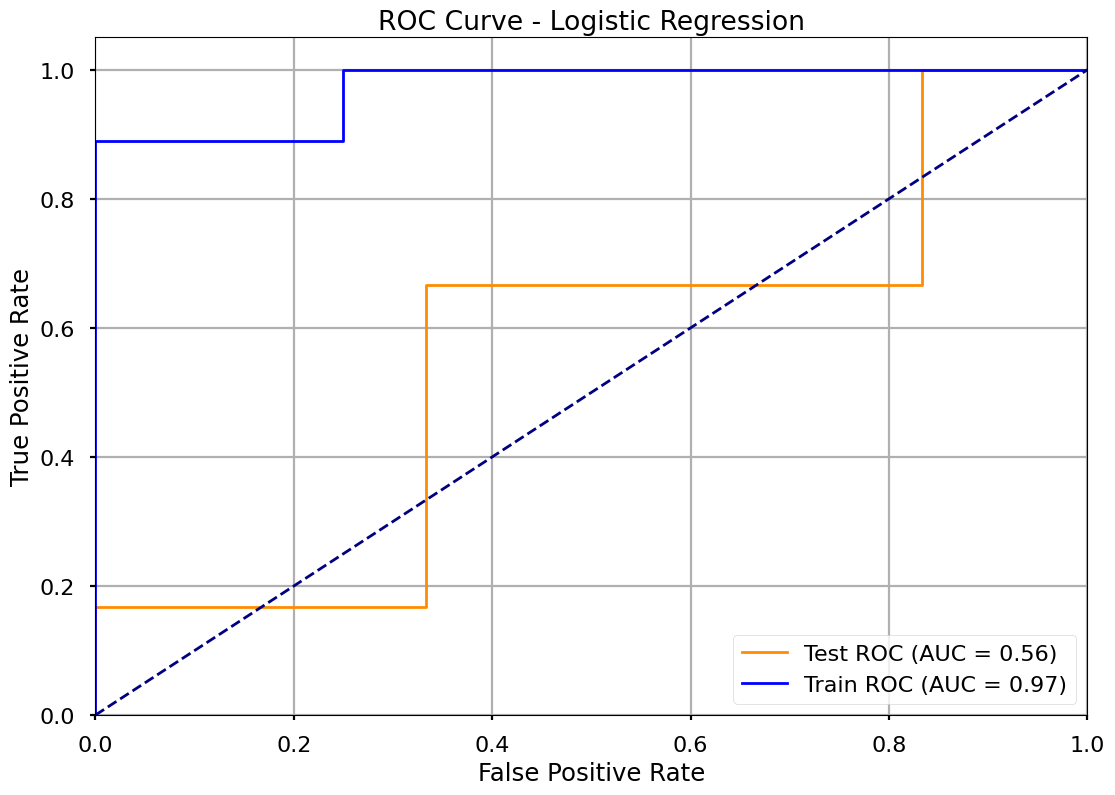

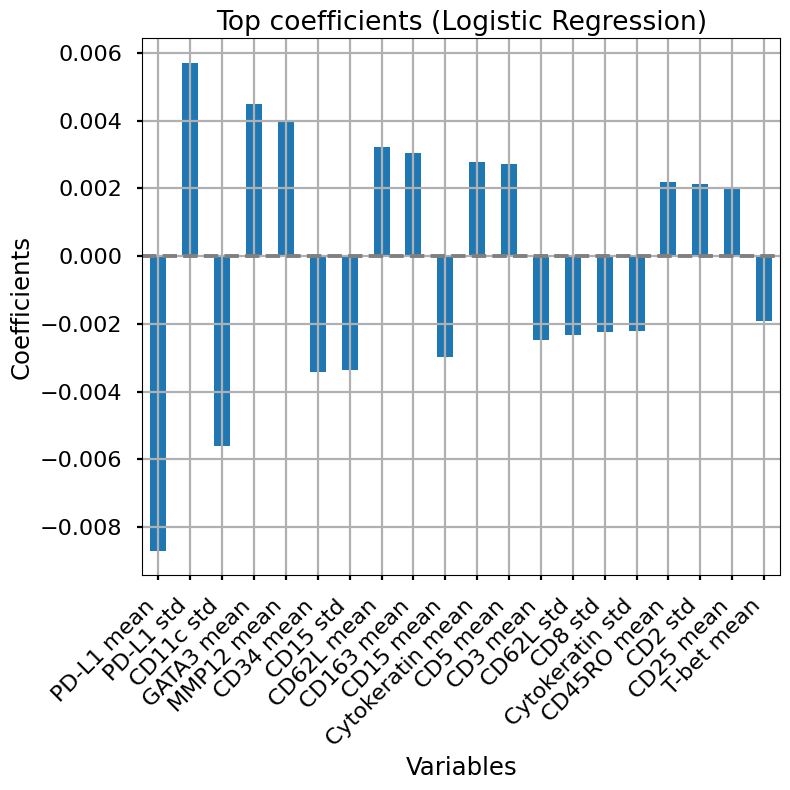

In [141]:
logistic_regression(var_aggreg_mean_per_sample, test_size=0.4, max_iter=200, l1_ratio=0.1)

Top 20 variables sélectionnées par variance.


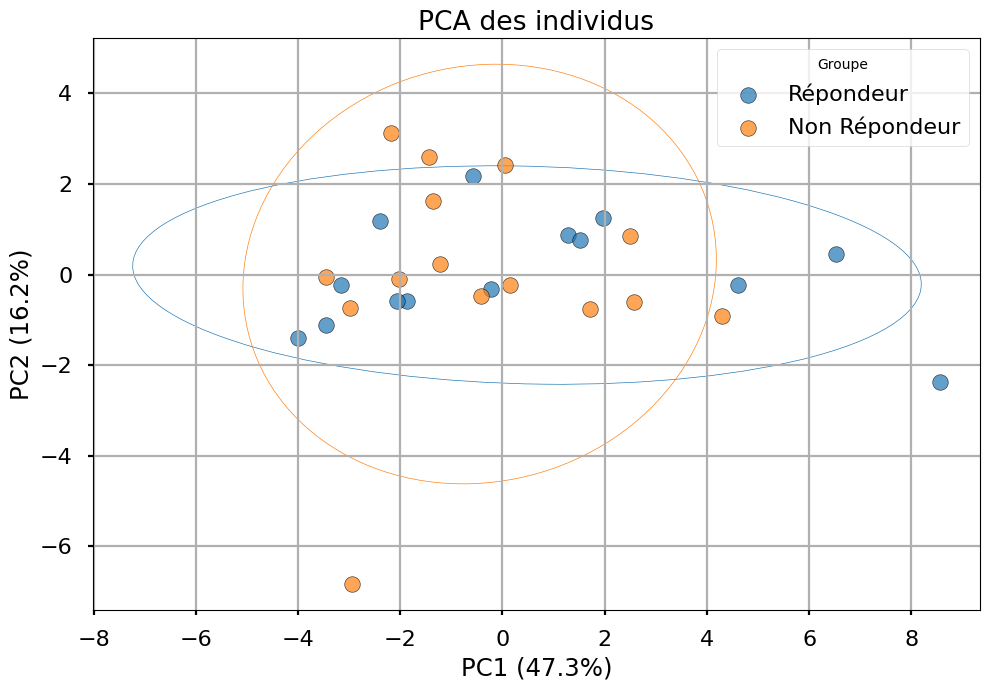

In [53]:
plot_pca(var_aggreg_mean_per_sample, n_vars=20)

In [169]:
# Gènes différentiels

pvals2 = mosna.find_DE_markers (var_aggreg_mean_per_sample, group_ref=2, group_tgt=1, group_var= var_aggreg_mean_per_sample.index.get_level_values('Groups') )

pvals2 = pvals2.sort_values(by='pval', ascending=True)
pvals2.head(20)
best_pval_names2 = pvals2.head(20).index

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.67      0.53         6
           1       0.33      0.17      0.22         6

    accuracy                           0.42        12
   macro avg       0.39      0.42      0.38        12
weighted avg       0.39      0.42      0.38        12

Accuracy (Test): 0.4166666666666667
Accuracy (Train): 0.7058823529411765


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


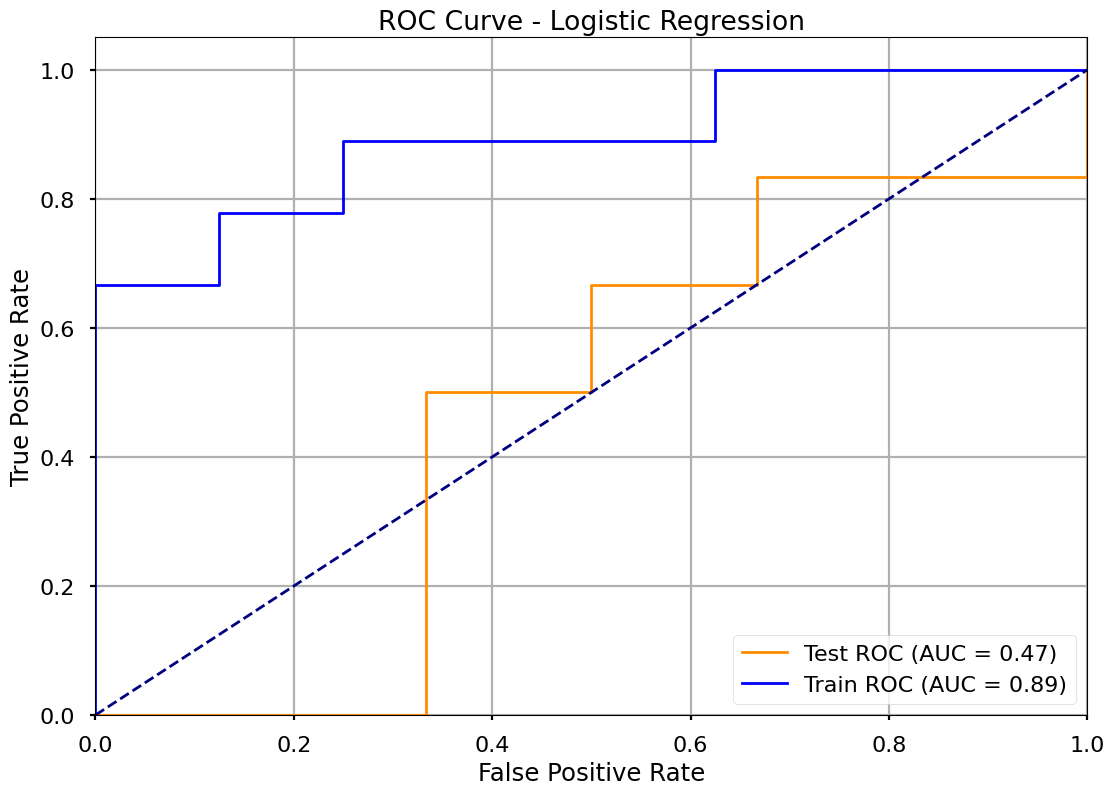

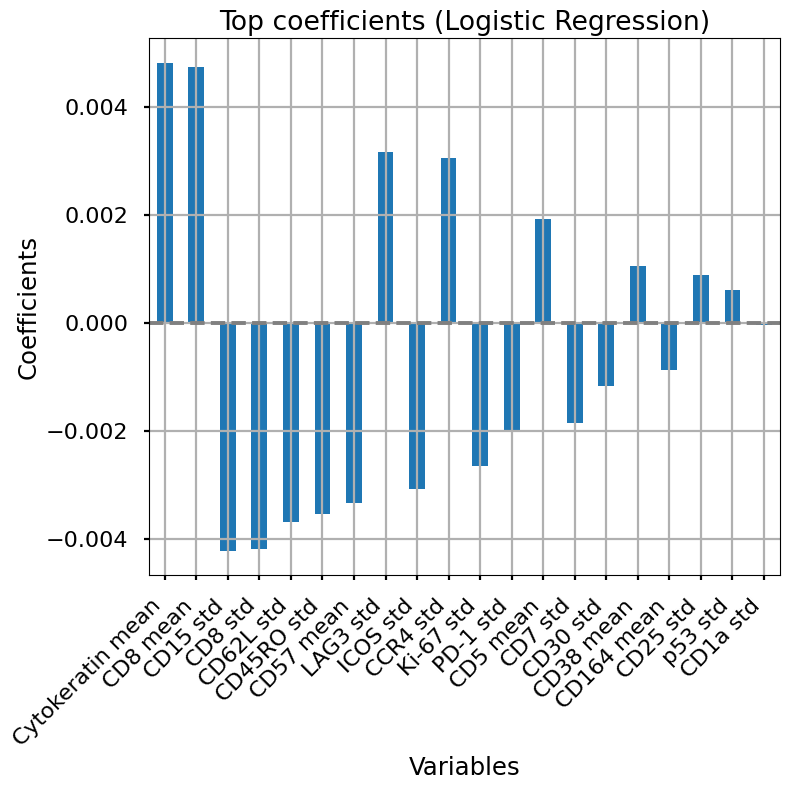

In [170]:
logistic_regression(var_aggreg_mean_per_sample[best_pval_names2], test_size=0.4, max_iter=50, l1_ratio= 0.1)

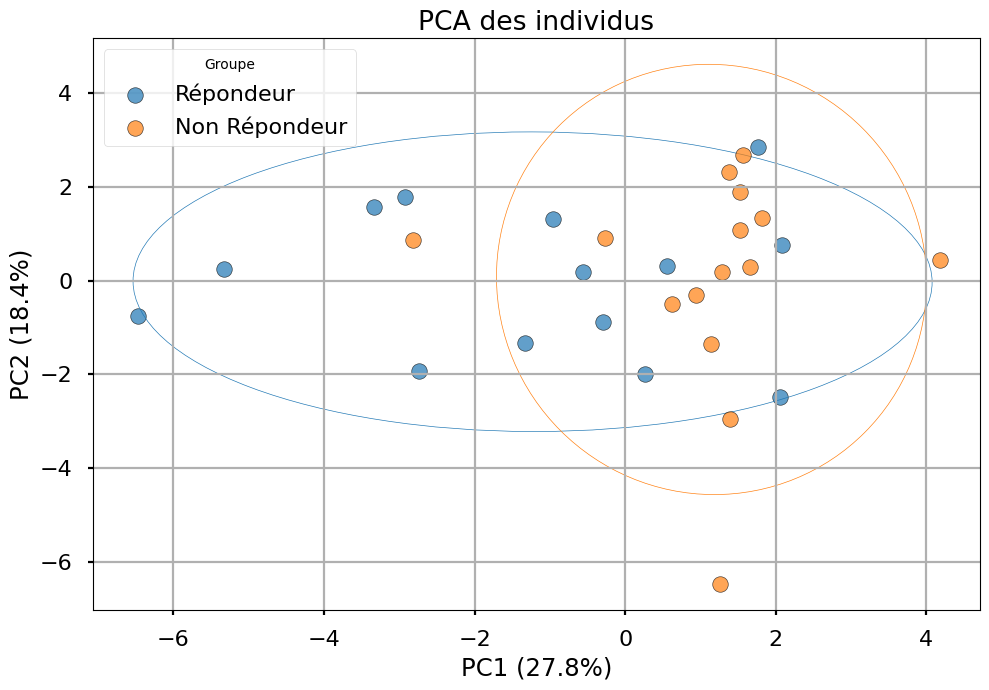

In [64]:
plot_pca(var_aggreg_mean_per_sample[best_pval_names2])

# Prédictions des réponses par cellules avec les NAS

In [ ]:
var_aggreg["Groups"] = obj["Groups"].values
var_aggreg = var_aggreg.set_index ("Groups" , append=True)
var_aggreg

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}
Temps d'entraînement : 54.66 secondes

Classification report (Test) :
              precision    recall  f1-score   support

           0       0.80      0.21      0.33      2962
           1       0.66      0.97      0.78      4651

    accuracy                           0.67      7613
   macro avg       0.73      0.59      0.56      7613
weighted avg       0.71      0.67      0.61      7613

Test Accuracy : 0.6718770524103507
Train Accuracy : 0.6840273216865888


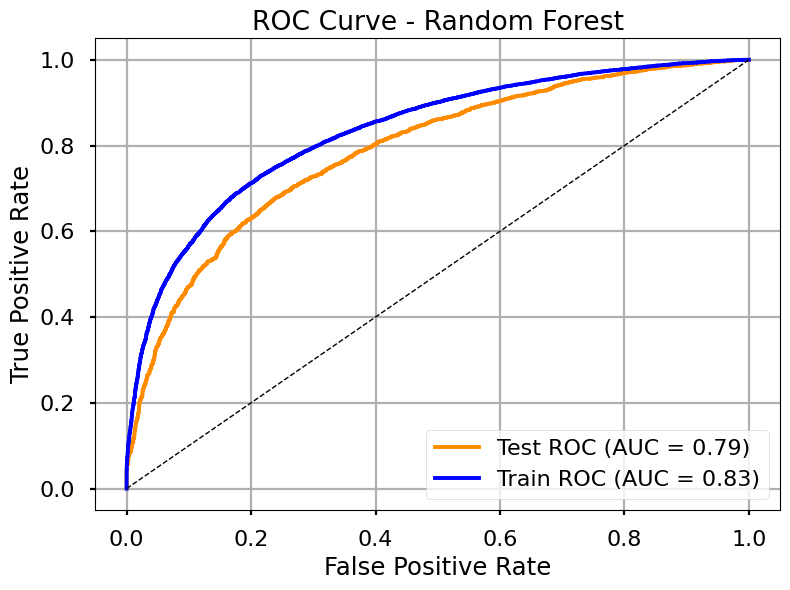

RandomForestClassifier(max_depth=6, max_samples=0.8, n_estimators=400,
                       random_state=0)

In [71]:
random_forest(var_aggreg, test_size=0.2, n_estimators= 400, max_depth=6)

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.45      0.54      2962
           1       0.71      0.86      0.78      4651

    accuracy                           0.70      7613
   macro avg       0.69      0.65      0.66      7613
weighted avg       0.69      0.70      0.68      7613

Accuracy (Test): 0.698804676211743
Accuracy (Train): 0.7035662682254039


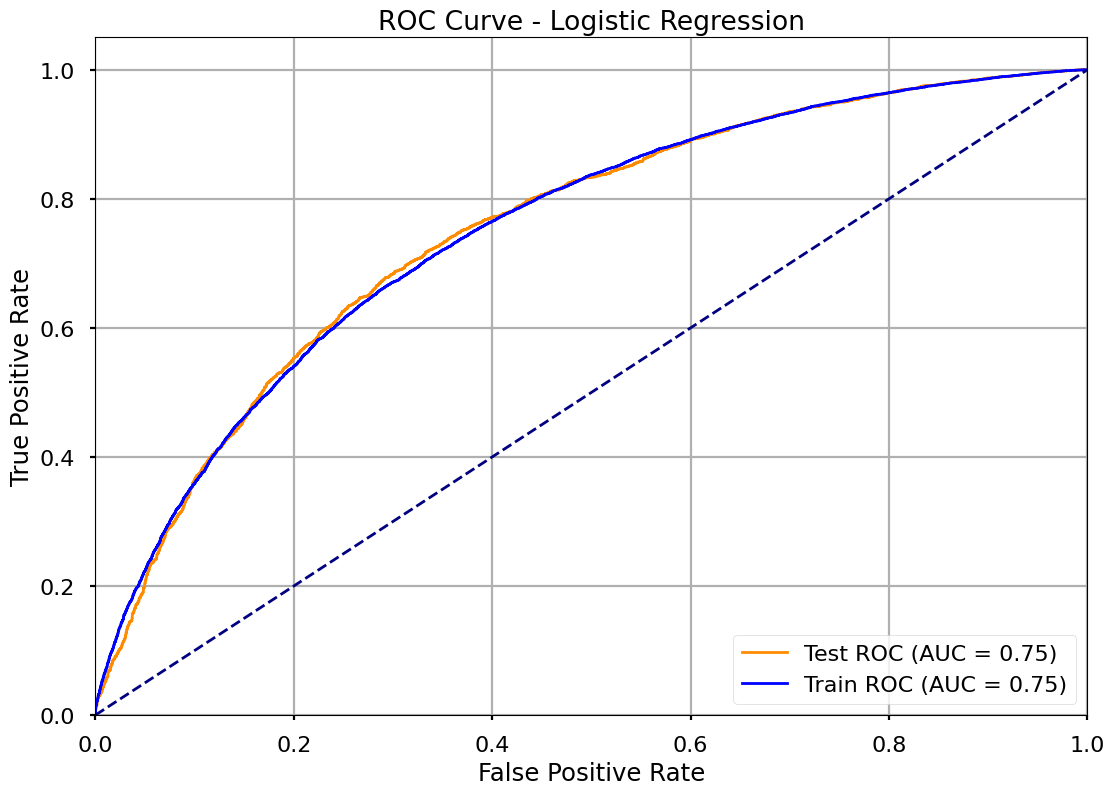

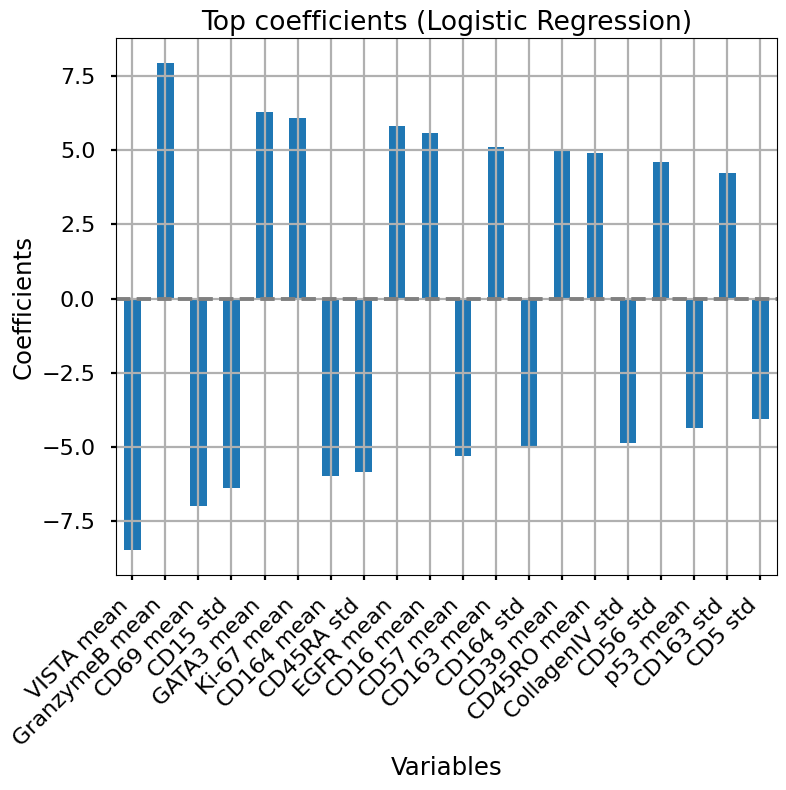

LogisticRegression(l1_ratio=0.1, max_iter=1000, penalty='elasticnet',
                   solver='saga')

In [72]:
logistic_regression (var_aggreg, test_size=0.2, max_iter=1000, l1_ratio=0.1)

# CLusteurisation des NAS

In [46]:
from tqdm import tqdm
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

trial_results = []
def H_Clust(N_clust):
    n_neighbors = 150 
    #trial.suggest_int("n_neighbors", 30, 300)
    #n_clusters = trial.suggest_int("n_clusters", 2, 30)
    # Créer graphe de connectivité entre voisins
        
        
    connectivity = kneighbors_graph(var_aggreg, n_neighbors=n_neighbors, include_self=False)
    
    for i in tqdm(range (2,N_clust+1)):
        n_clusters = i
        
    # Clustering hiérarchique contraint
        model = AgglomerativeClustering(
            n_clusters= n_clusters,
            connectivity=connectivity,
            linkage='ward'
            )


        labels = model.fit_predict(var_aggreg)
        n_clusters = len(set(labels))



        score = silhouette_score(var_aggreg, labels)

        trial_results.append({
            "n_neighbors": n_neighbors,
            "n_clusters": n_clusters,
            "silhouette_score": score,
        })      

In [47]:
H_Clust(40)

100%|██████████| 39/39 [16:45:01<00:00, 1546.19s/it]   


In [ ]:
trial_results

[{'n_neighbors': 150,
  'n_clusters': 2,
  'silhouette_score': np.float64(0.19424973791493122)},
 {'n_neighbors': 150,
  'n_clusters': 3,
  'silhouette_score': np.float64(0.09315274039387782)},
 {'n_neighbors': 150,
  'n_clusters': 4,
  'silhouette_score': np.float64(0.06985971467265527)},
 {'n_neighbors': 150,
  'n_clusters': 5,
  'silhouette_score': np.float64(0.06465856107906556)},
 {'n_neighbors': 150,
  'n_clusters': 6,
  'silhouette_score': np.float64(0.039397772411761206)},
 {'n_neighbors': 150,
  'n_clusters': 7,
  'silhouette_score': np.float64(0.03554872941022054)},
 {'n_neighbors': 150,
  'n_clusters': 8,
  'silhouette_score': np.float64(0.0305935218405266)},
 {'n_neighbors': 150,
  'n_clusters': 9,
  'silhouette_score': np.float64(0.02572042130558279)},
 {'n_neighbors': 150,
  'n_clusters': 10,
  'silhouette_score': np.float64(0.024222552445162426)},
 {'n_neighbors': 150,
  'n_clusters': 11,
  'silhouette_score': np.float64(0.0177535672152425)},
 {'n_neighbors': 150,
  'n_c

In [50]:
results_cluster_NAS = pd.DataFrame(trial_results)
results_cluster_NAS.to_csv("/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process/Cluster_NAS")

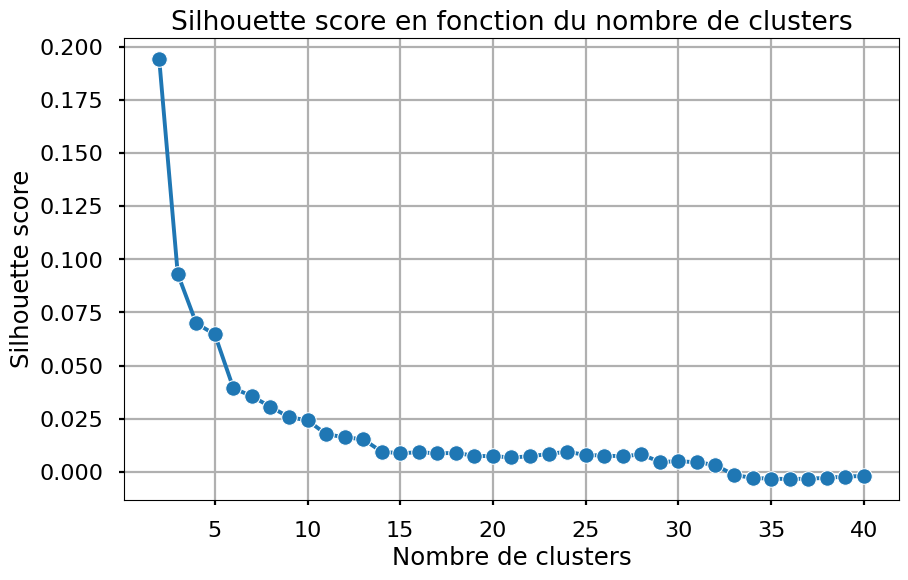

In [51]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=results_cluster_NAS, x="n_clusters", y="silhouette_score", marker="o")
plt.title("Silhouette score en fonction du nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

In [55]:
#On choisit un nombre de cluster/niches de 10

connectivity = kneighbors_graph(var_aggreg, n_neighbors=150, include_self=False)

model = AgglomerativeClustering(
    n_clusters = 10,
    connectivity = connectivity,
    linkage='ward'
    )


labels_cluster_NAS = model.fit_predict(var_aggreg)


In [73]:
df = pd.DataFrame({
        "sample": var_aggreg_samples_info["sample"],
        "cluster": labels_cluster_NAS
    })

    # Compter le nombre de cellules par sample et cluster
count_table = df.groupby(["sample", "cluster"]).size().unstack(fill_value=0)

    # Convertir en proportions par sample (ligne)
proportion_table = count_table.div(count_table.sum(axis=1), axis=0)

proportion_table

cluster,0,1,2,3,4,5,6,7,8,9
sample,,,,,,,,,,
reg001,0.000000,0.063797,0.043812,0.005380,0.004612,0.044581,0.000000,0.335895,0.352037,0.149885
reg002,0.140706,0.450086,0.058090,0.015491,0.025387,0.002151,0.186747,0.002582,0.026248,0.092513
reg005,0.071429,0.000000,0.000000,0.000000,0.000000,0.928571,0.000000,0.000000,0.000000,0.000000
reg006,0.000000,0.081260,0.094527,0.266998,0.129353,0.000000,0.009950,0.170813,0.164179,0.082919
reg009,0.309769,0.071123,0.160668,0.012853,0.059554,0.026992,0.290917,0.029135,0.013282,0.025707
...,...,...,...,...,...,...,...,...,...,...
reg046,0.018564,0.023515,0.056931,0.029703,0.217822,0.002475,0.128713,0.103960,0.175743,0.242574
reg051,0.000000,0.030499,0.563771,0.185767,0.101664,0.000000,0.009242,0.000000,0.008318,0.100739
reg052,0.263035,0.070299,0.090803,0.028120,0.062097,0.428237,0.033392,0.002929,0.003515,0.017575


In [74]:
proportion_table.sum(axis=0)

cluster
0    3.481658
1    3.765968
2    5.651061
3    2.783893
4    1.955275
5    2.778088
6    1.786854
7    1.613643
8    3.004069
9    2.179490
dtype: float64

In [75]:
count_table

cluster,0,1,2,3,4,5,6,7,8,9
sample,,,,,,,,,,
reg001,0,83,57,7,6,58,0,437,458,195
reg002,327,1046,135,36,59,5,434,6,61,215
reg005,8,0,0,0,0,104,0,0,0,0
reg006,0,49,57,161,78,0,6,103,99,50
reg009,723,166,375,30,139,63,679,68,31,60
...,...,...,...,...,...,...,...,...,...,...
reg046,15,19,46,24,176,2,104,84,142,196
reg051,0,33,610,201,110,0,10,0,9,109
reg052,449,120,155,48,106,731,57,5,6,30


In [76]:
count_table.sum(axis=0)

cluster
0    5074
1    6463
2    6240
3    3469
4    2188
5    2533
6    3241
7    1534
8    4375
9    2948
dtype: int64

In [78]:
proportion_table["Groups"] = status["Groups"].values
proportion_table = proportion_table.set_index("Groups", append=True)
proportion_table

,cluster,0,1,2,3,4,5,6,7,8,9
sample,Groups,,,,,,,,,,
reg001,1,0.000000,0.063797,0.043812,0.005380,0.004612,0.044581,0.000000,0.335895,0.352037,0.149885
reg002,1,0.140706,0.450086,0.058090,0.015491,0.025387,0.002151,0.186747,0.002582,0.026248,0.092513
reg005,1,0.071429,0.000000,0.000000,0.000000,0.000000,0.928571,0.000000,0.000000,0.000000,0.000000
reg006,1,0.000000,0.081260,0.094527,0.266998,0.129353,0.000000,0.009950,0.170813,0.164179,0.082919
reg009,2,0.309769,0.071123,0.160668,0.012853,0.059554,0.026992,0.290917,0.029135,0.013282,0.025707
...,...,...,...,...,...,...,...,...,...,...,...
reg046,2,0.018564,0.023515,0.056931,0.029703,0.217822,0.002475,0.128713,0.103960,0.175743,0.242574
reg051,1,0.000000,0.030499,0.563771,0.185767,0.101664,0.000000,0.009242,0.000000,0.008318,0.100739
reg052,1,0.263035,0.070299,0.090803,0.028120,0.062097,0.428237,0.033392,0.002929,0.003515,0.017575


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


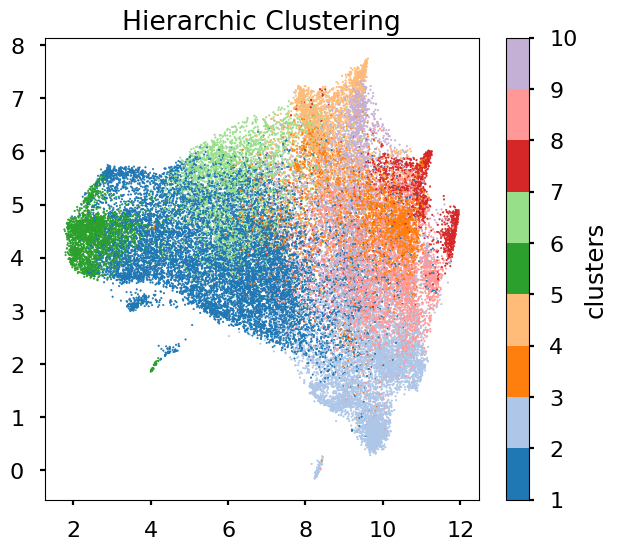

In [98]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import umap

reducer = umap.UMAP(random_state=42, n_neighbors=150)
NAS_umap = reducer.fit_transform(var_aggreg)

# Déterminer le nombre réel de clusters
n_clusters = len(np.unique(labels_cluster_NAS))


# Créer une colormap avec exactement le bon nombre de couleurs
cmap = ListedColormap(plt.get_cmap("tab20").colors[:n_clusters])
norm = BoundaryNorm(np.arange(1, n_clusters +1 ), n_clusters)



plt.figure(figsize=(7, 6))
plt.scatter(NAS_umap[:, 0], NAS_umap[:, 1], c=labels_cluster_NAS ,cmap=cmap,norm=norm, s=1)
plt.colorbar(label="clusters")
plt.title("Hierarchic Clustering")
plt.show()

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.42      1.00      0.59         5
           1       0.00      0.00      0.00         7

    accuracy                           0.42        12
   macro avg       0.21      0.50      0.29        12
weighted avg       0.17      0.42      0.25        12

Accuracy (Test): 0.4166666666666667
Accuracy (Train): 0.5294117647058824


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

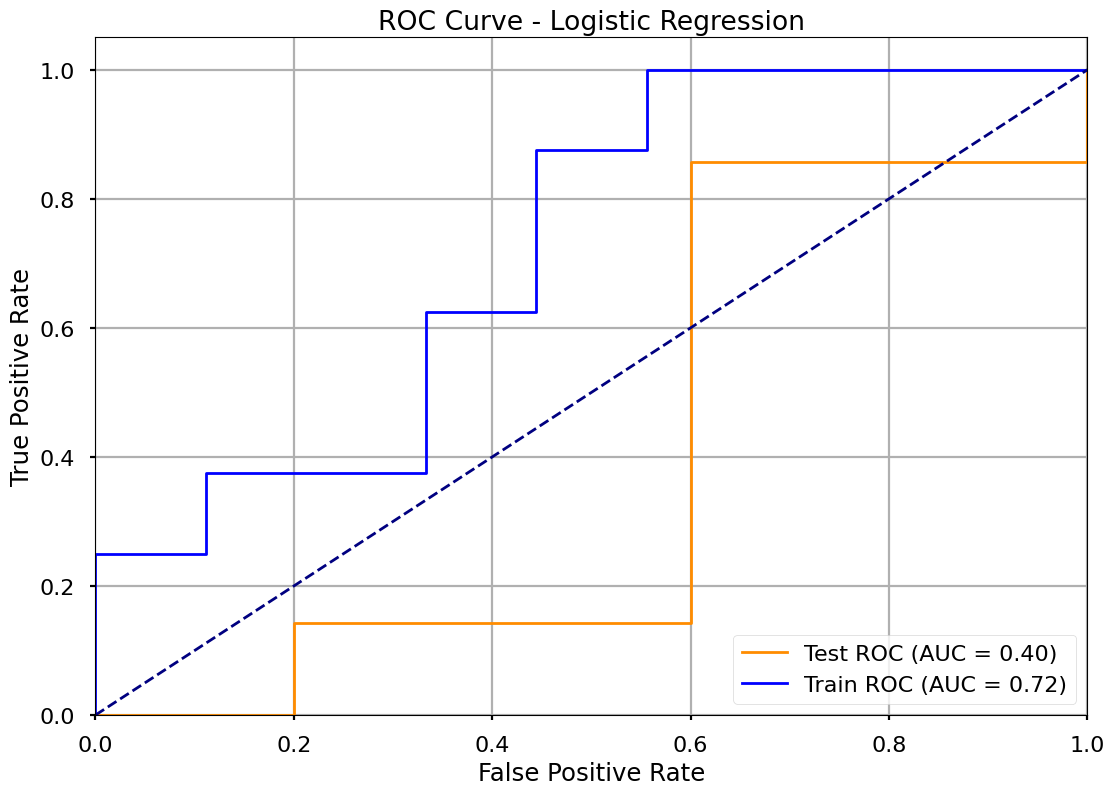

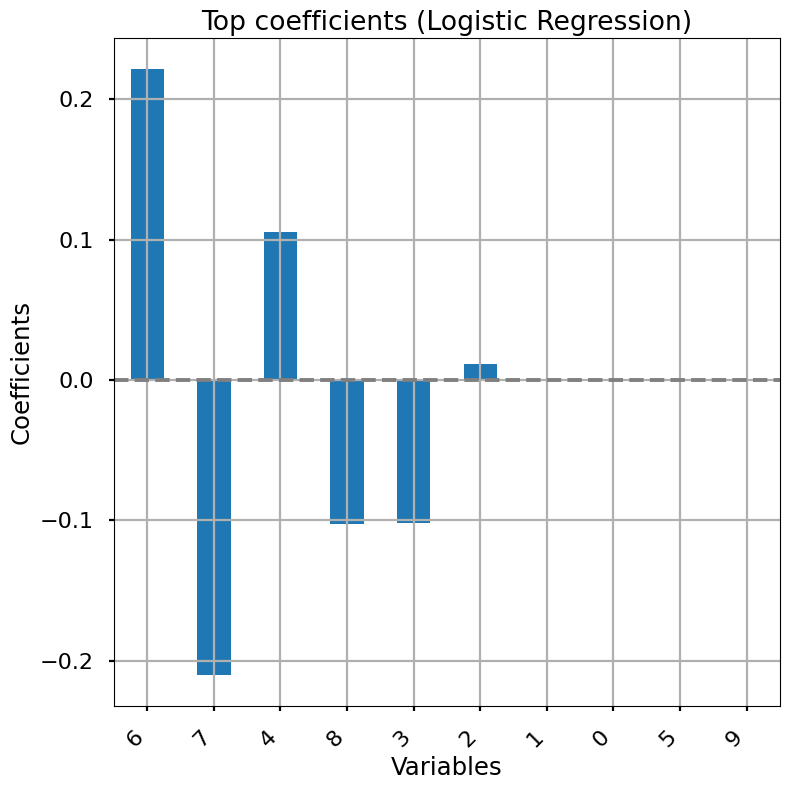

LogisticRegression(l1_ratio=0.1, max_iter=300, penalty='elasticnet',
                   solver='saga')

In [79]:
logistic_regression (proportion_table, test_size=0.4, max_iter=300, l1_ratio=0.1)

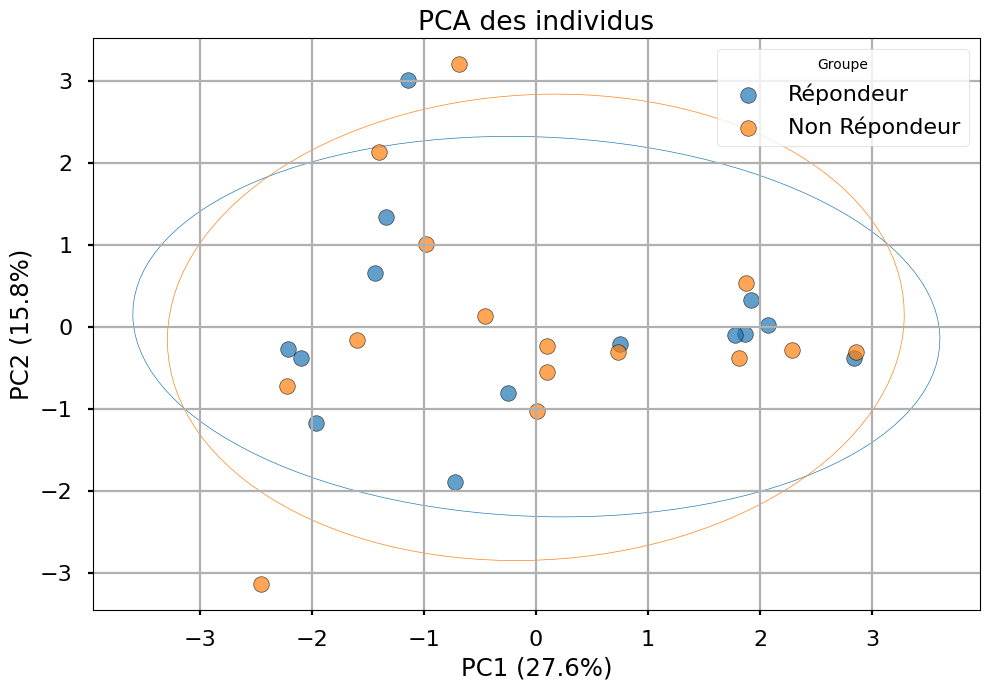

In [80]:
plot_pca (proportion_table)

In [81]:
pvalsNiches = mosna.find_DE_markers(proportion_table, group_ref=1, group_tgt=2, group_var = proportion_table.index.get_level_values('Groups') )

# Prédictions de réponses des échantillons Dataframe avec variables concaténés

In [65]:
df_concatedZ_Prop = pd.concat([prop_types2, z_net_stats_cleaned], axis = 1)

df_concatedZ_PropV2 = pd.concat([prop_types2[pvals.head(7).index], z_net_stats_cleaned[pvals3.head(7).index]], axis = 1)

#df_concatedZ_CountNorm = pd.concat([z_net_stats_cleaned, df_count_norm], axis=1)

#df_concatedZ_CountNormV2 = pd.concat([z_net_stats_cleaned[pvals3.head(7).index], df_count_norm[pvals2.head(6).index]], axis=1)



Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.83      0.71      0.77         7

    accuracy                           0.75        12
   macro avg       0.75      0.76      0.75        12
weighted avg       0.76      0.75      0.75        12

Accuracy (Test): 0.75
Accuracy (Train): 1.0


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


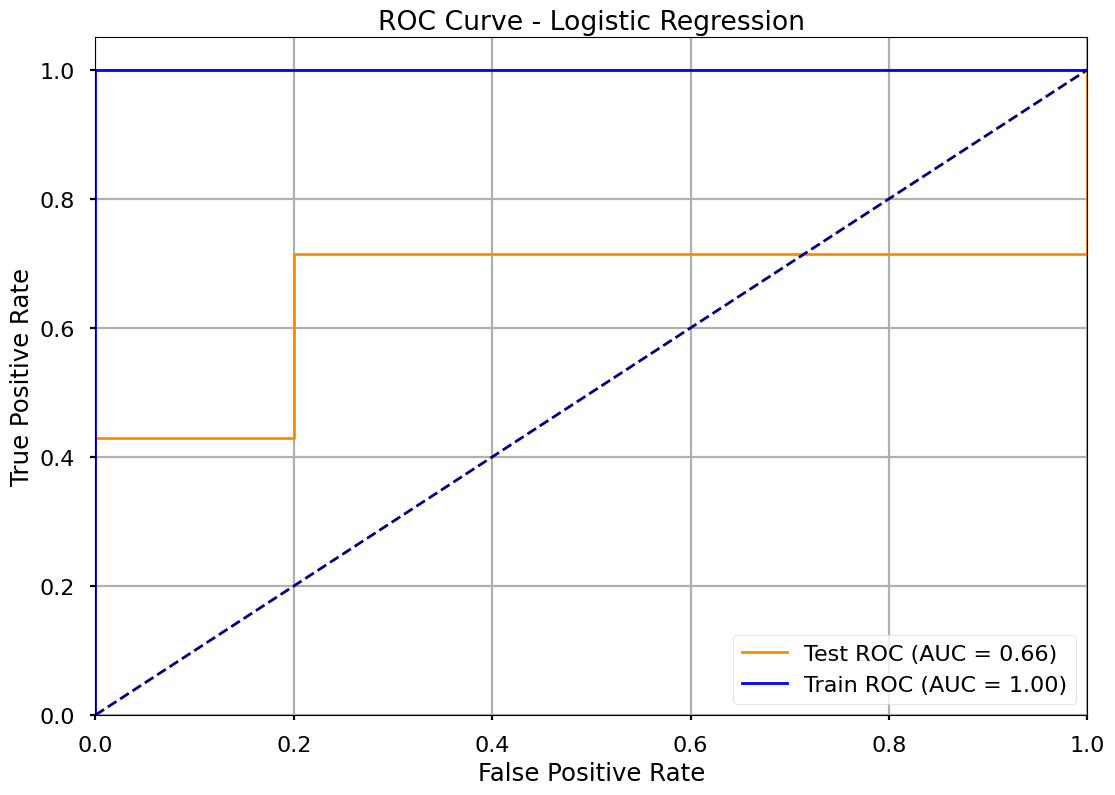

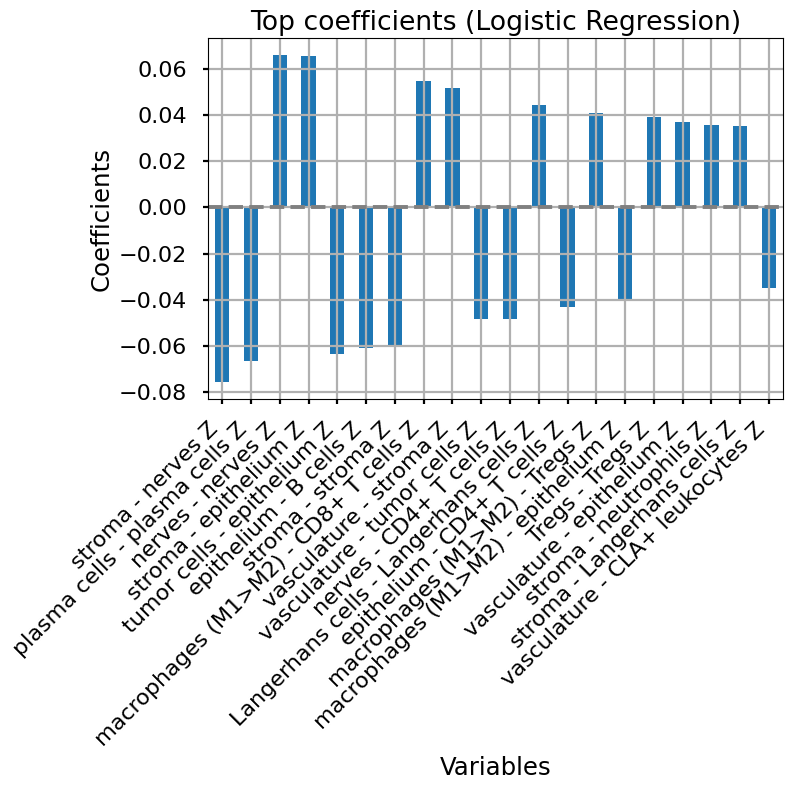

LogisticRegression(l1_ratio=0.1, max_iter=50, penalty='elasticnet',
                   solver='saga')

In [66]:
logistic_regression (df_concatedZ_Prop, test_size= 0.4, max_iter=50, l1_ratio=0.1)

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.75      0.86      0.80         7

    accuracy                           0.75        12
   macro avg       0.75      0.73      0.73        12
weighted avg       0.75      0.75      0.74        12

Accuracy (Test): 0.75
Accuracy (Train): 0.8235294117647058


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


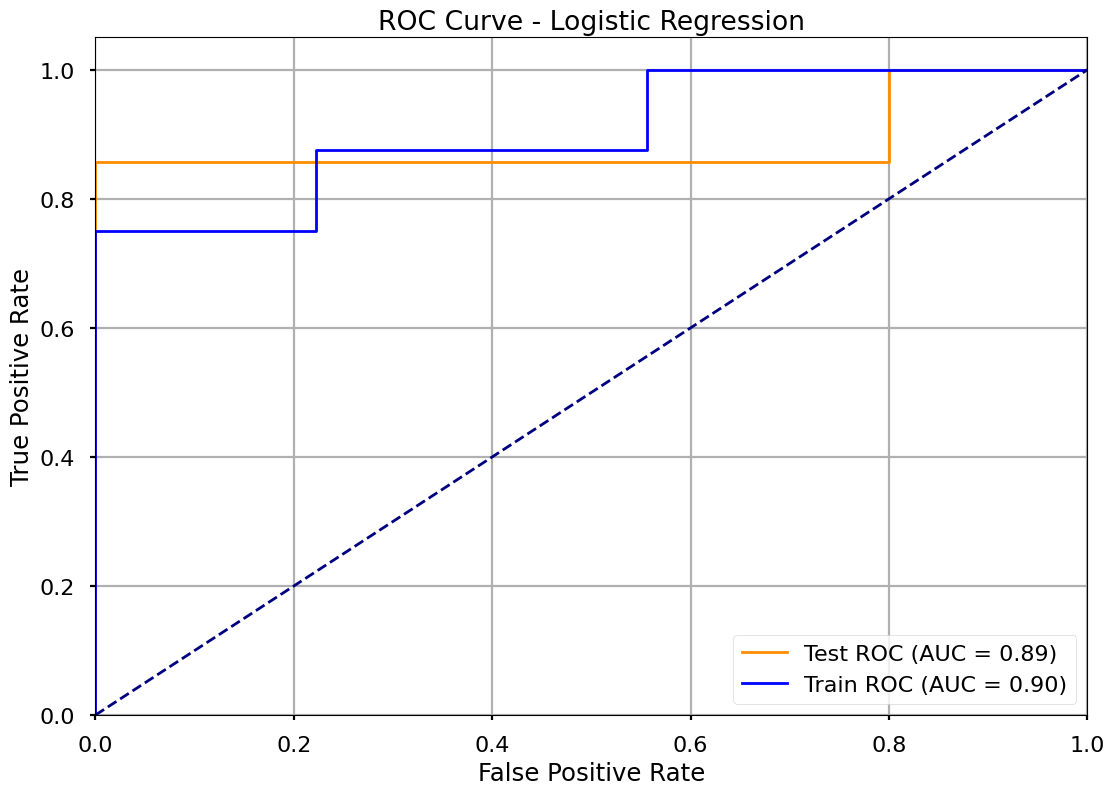

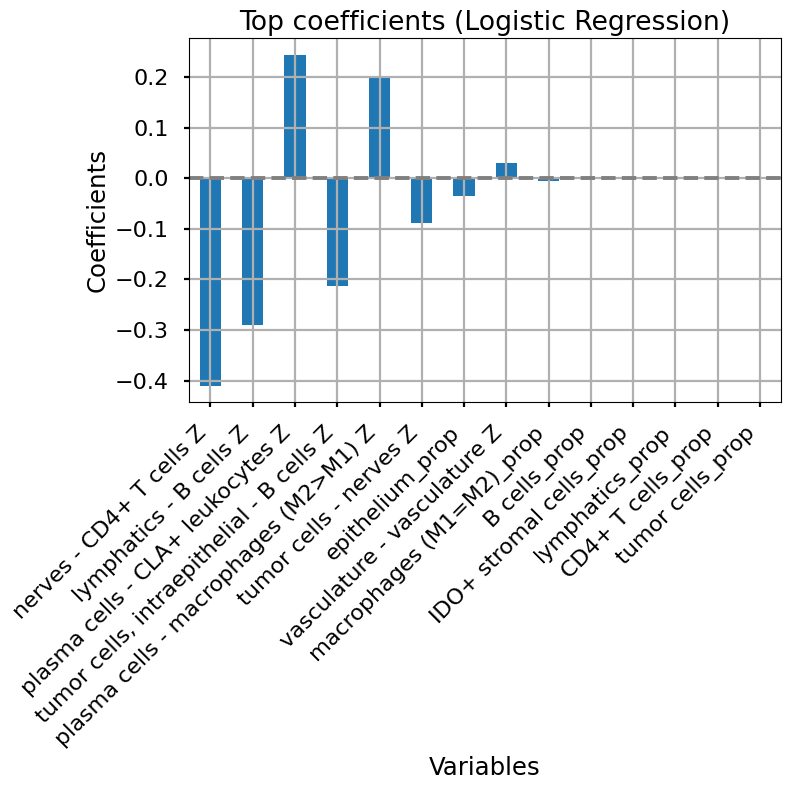

In [67]:
modelLRZ_Count = logistic_regression (df_concatedZ_PropV2, test_size= 0.4, max_iter=50, l1_ratio=0.1)

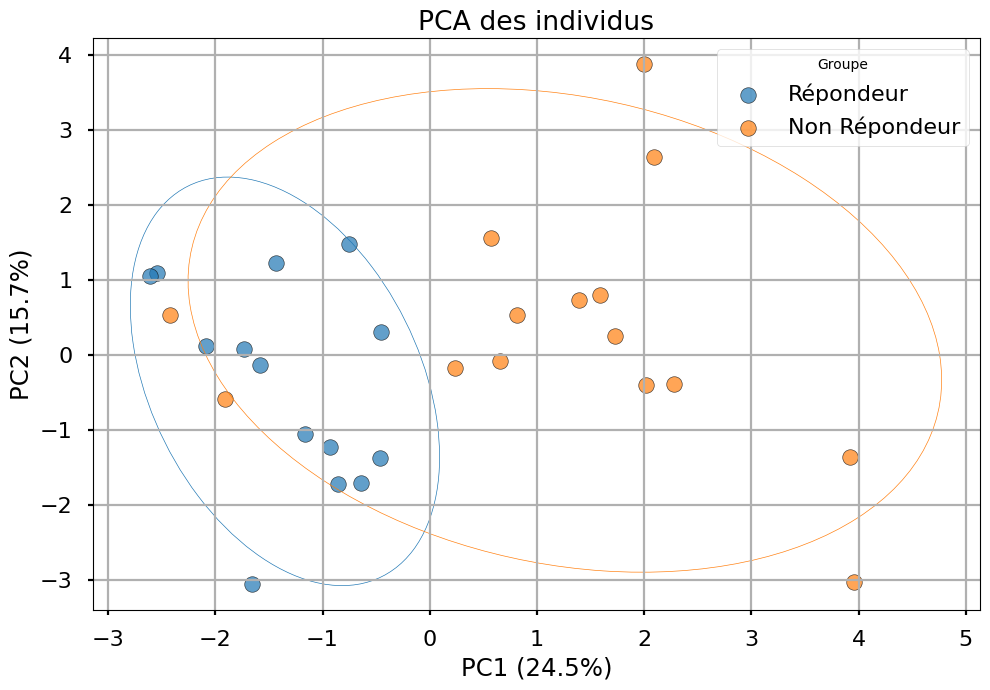

In [90]:
plot_pca (df_concatedZ_PropV2)

In [69]:
import shap 

explainerLR_Z_Count = shap.LinearExplainer(modelLRZ_Count, df_concatedZ_PropV2)
shap_LR_Z_Count = explainerLR_Z_Count (df_concatedZ_PropV2)

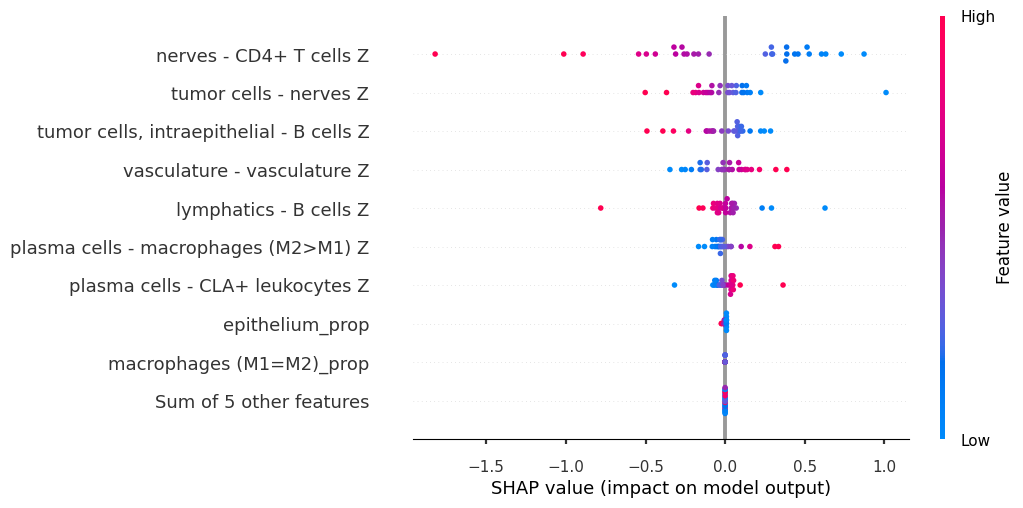

In [70]:
shap.plots.beeswarm(shap_LR_Z_Count)

In [84]:
df_assort_niches = pd.concat([z_net_stats_cleaned[pvals3.head(6).index],proportion_table[pvalsNiches.head(6).index]], axis=1)

df_niches_prop = pd.concat ([proportion_table[pvalsNiches.head(10).index], prop_types2[pvals.head(10).index]], axis=1)

df_assort_niches_prop = pd.concat([z_net_stats_cleaned[pvals3.head(6).index],proportion_table[pvalsNiches.head(6).index], prop_types2[pvals.head(6).index]], axis=1)

df_assort_niches.columns = df_assort_niches.columns.astype(str)
df_niches_prop.columns = df_niches_prop.columns.astype(str)
df_assort_niches_prop.columns = df_assort_niches_prop.columns.astype(str)

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.75      0.86      0.80         7

    accuracy                           0.75        12
   macro avg       0.75      0.73      0.73        12
weighted avg       0.75      0.75      0.74        12

Accuracy (Test): 0.75
Accuracy (Train): 0.7647058823529411


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


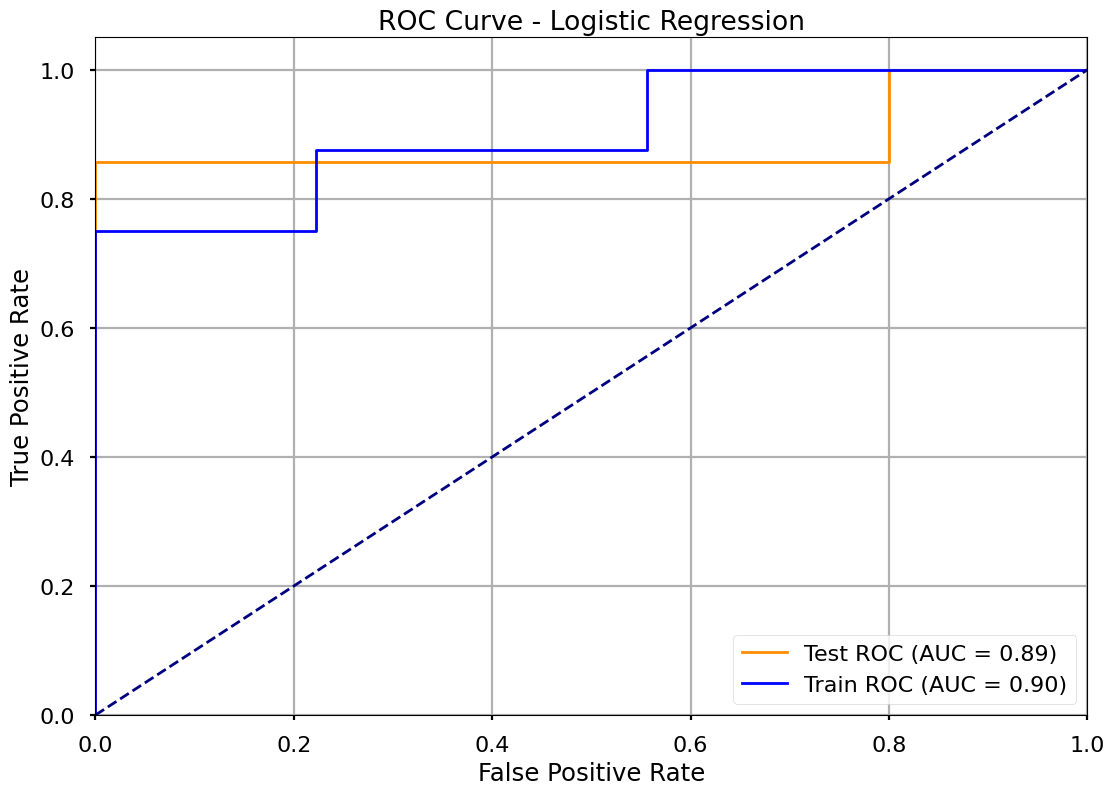

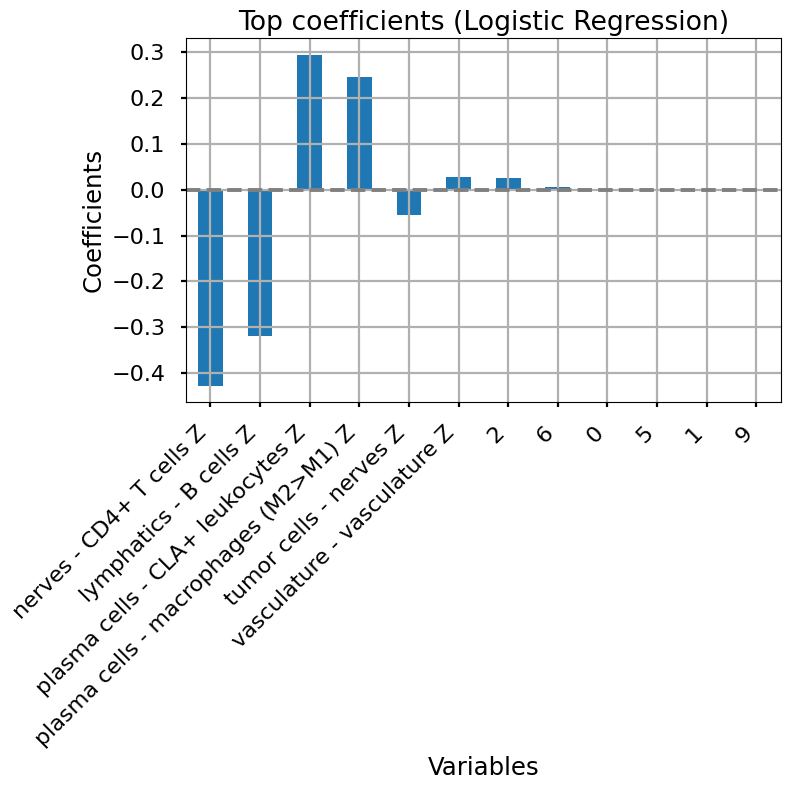

LogisticRegression(l1_ratio=0.1, max_iter=60, penalty='elasticnet',
                   solver='saga')

In [85]:
logistic_regression(df_assort_niches, test_size=0.4, max_iter=60, l1_ratio=0.1)

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.42      1.00      0.59         5
           1       0.00      0.00      0.00         7

    accuracy                           0.42        12
   macro avg       0.21      0.50      0.29        12
weighted avg       0.17      0.42      0.25        12

Accuracy (Test): 0.4166666666666667
Accuracy (Train): 0.5294117647058824


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

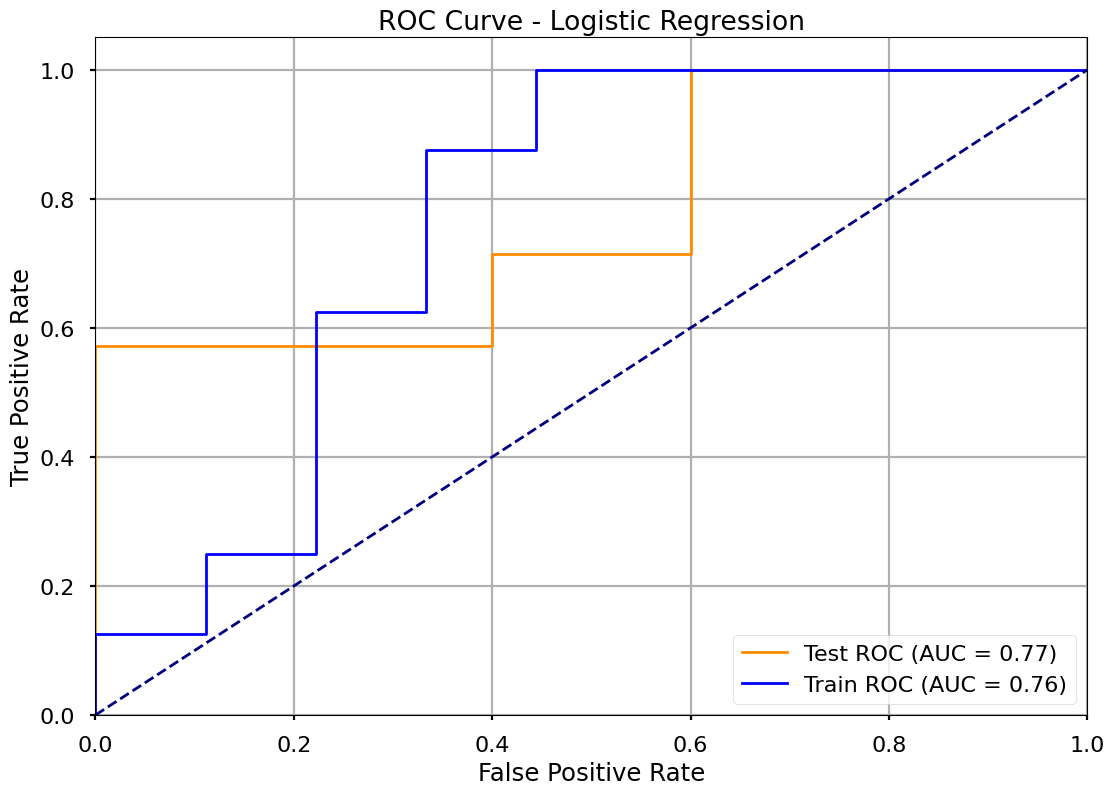

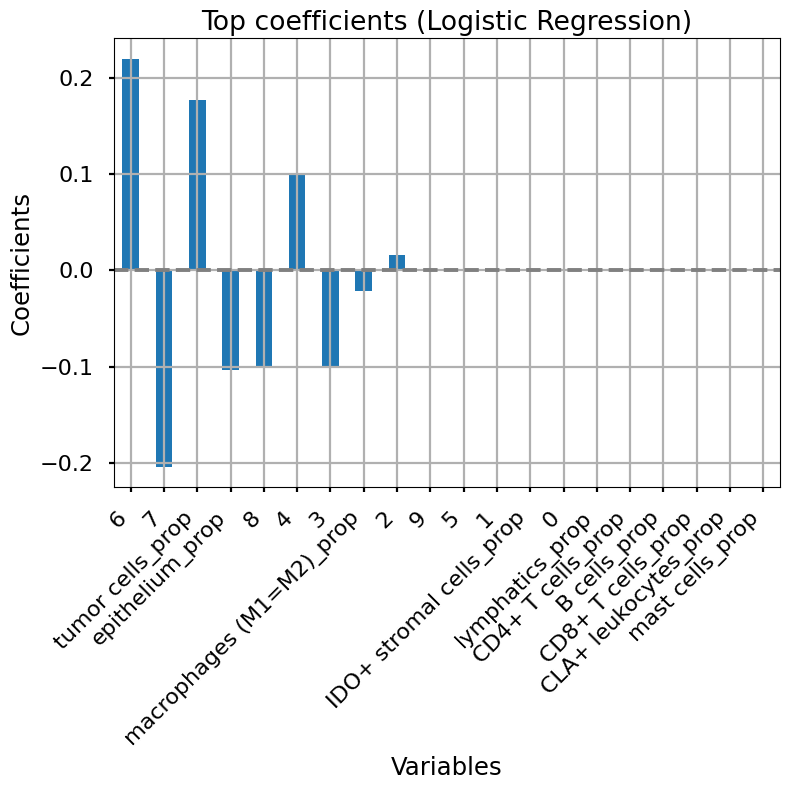

In [87]:
modelN_C = logistic_regression (df_niches_prop, test_size= 0.4, max_iter= 100, l1_ratio= 0.1)

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.75      0.86      0.80         7

    accuracy                           0.75        12
   macro avg       0.75      0.73      0.73        12
weighted avg       0.75      0.75      0.74        12

Accuracy (Test): 0.75
Accuracy (Train): 0.7647058823529411


/home/geremi/miniconda3/envs/mosna/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


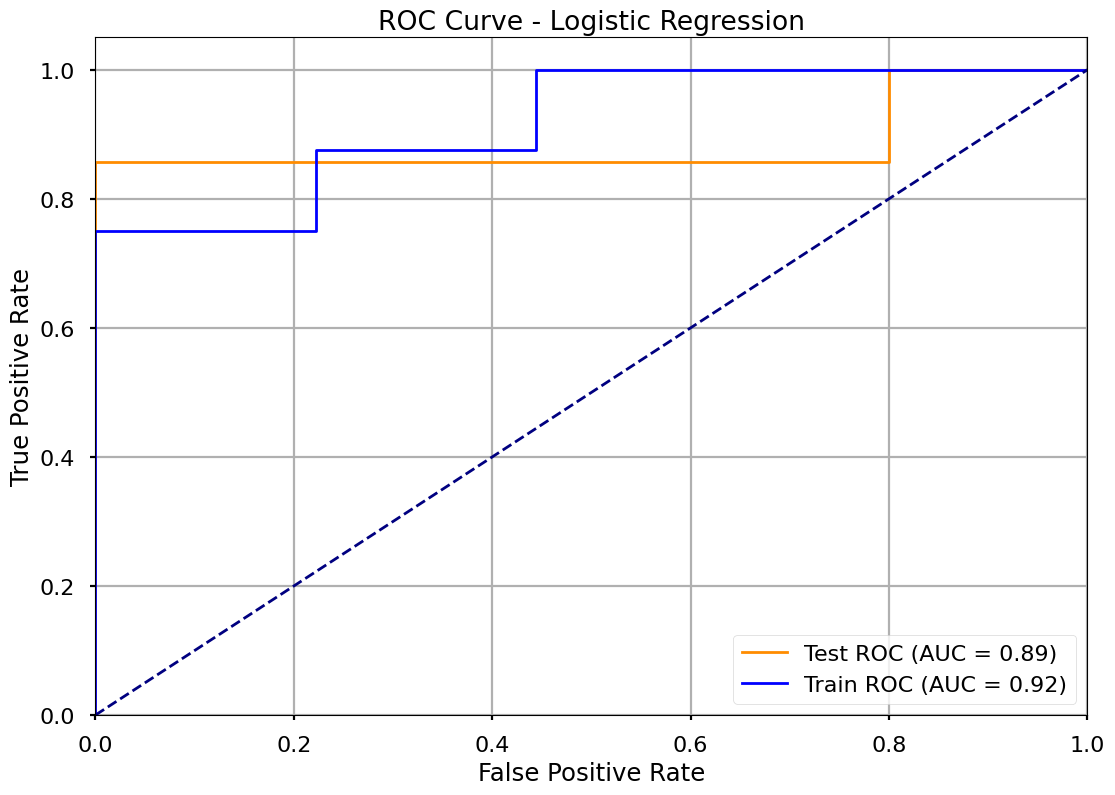

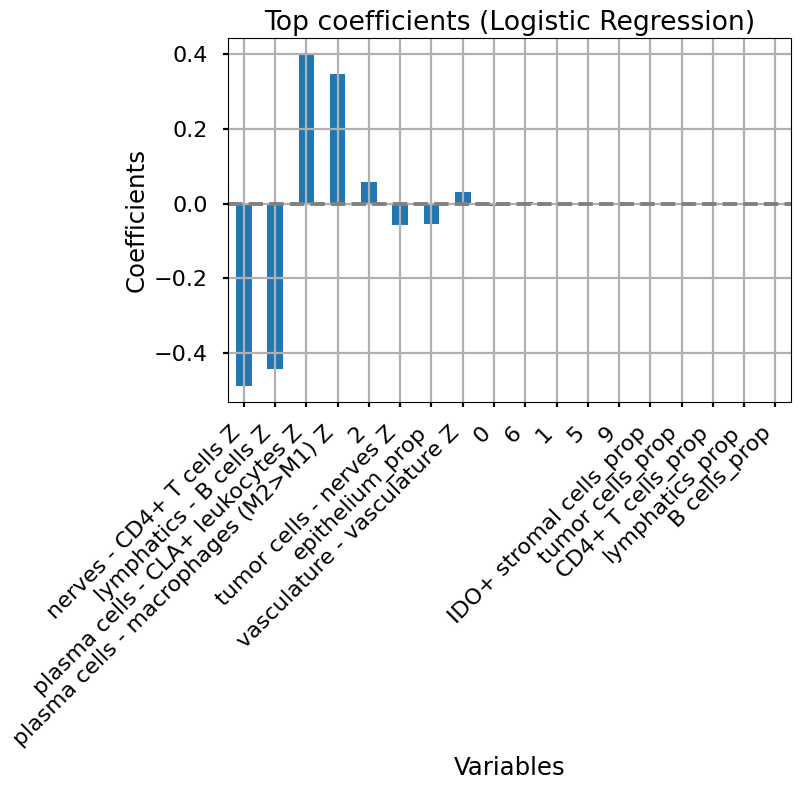

In [88]:
modelLRZ_N_C = logistic_regression (df_assort_niches_prop, test_size= 0.4, max_iter= 100, l1_ratio= 0.1)

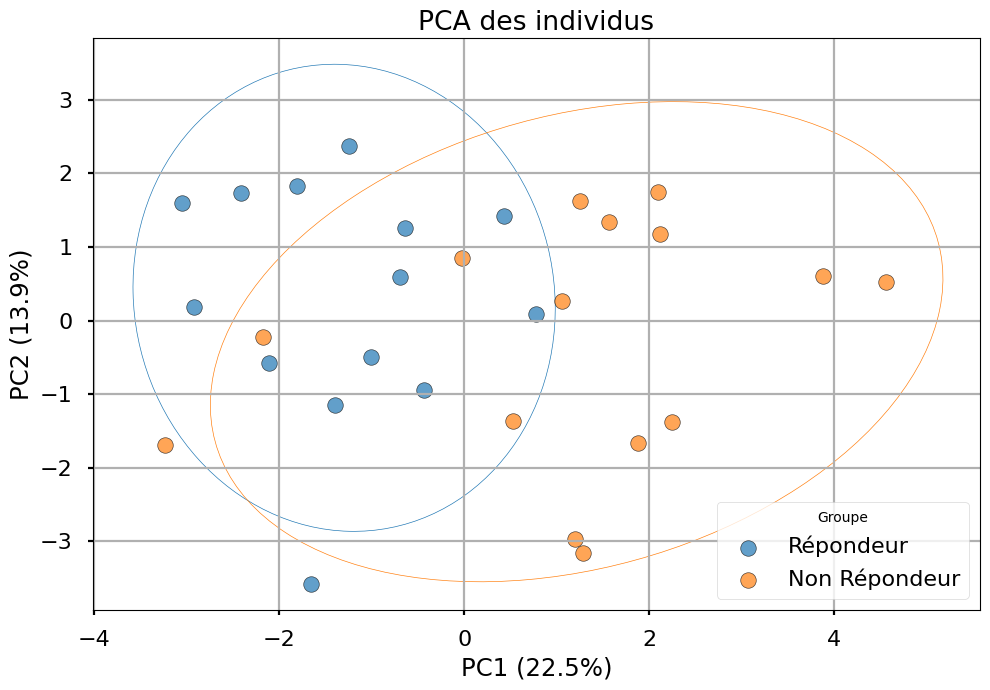

In [89]:
plot_pca(df_assort_niches_prop)

In [91]:
explainerLR_Z_N_P = shap.LinearExplainer (modelLRZ_N_C, df_assort_niches_prop)
shap_LR_Z_N_P = explainerLR_Z_N_P(df_assort_niches_prop)

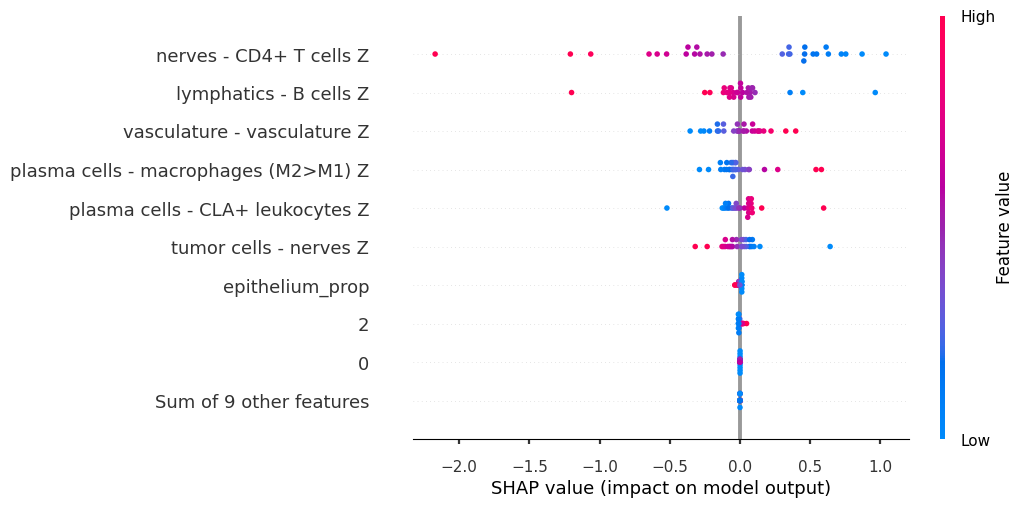

In [92]:
shap.plots.beeswarm (shap_LR_Z_N_P )

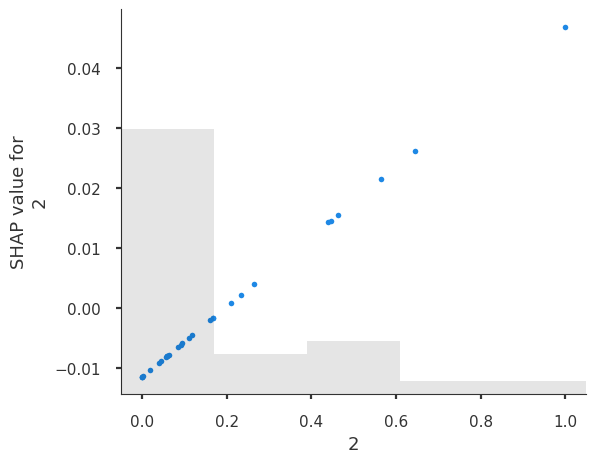

In [94]:
shap.plots.scatter(shap_LR_Z_N_P[:,"2"])

In [95]:
mosna.plot_clusters??

Signature:
mosna.plot_clusters(
    embed_viz,
    cluster_labels=None,
    save_dir=None,
    cluster_params=None,
    extra_str='',
    show_id=True,
    legend=True,
    legend_opt=None,
    cluster_colors=None,
    aspect='equal',
    return_cmap=False,
    figsize=(10, 10),
)
Source:   
def plot_clusters(embed_viz, 
                  cluster_labels=None, 
                  save_dir=None, 
                  cluster_params=None, 
                  extra_str='', 
                  show_id=True,
                  legend=True, 
                  legend_opt=None,
                  cluster_colors=None,
                  aspect='equal',
                  return_cmap=False, 
                  figsize=(10,10),
                  ):
    """
    Plots clustered data on its 2D projection.

    Parameters
    ----------
    embed_viz : ndarray
        Mx2 array of points coordinates in the 2D projection.
    cluster_labels : array
        Cluster label ids of data points.
    save_dir : str or p

Loading reducer object and reduced coordinates


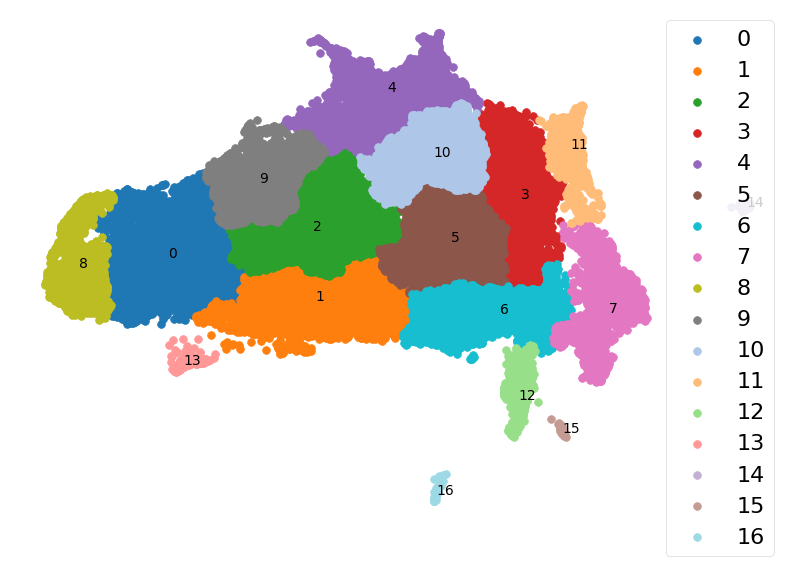

In [ ]:
embed_viz, _ = mosna.get_reducer(
    var_aggreg, 
    sof_dir, 
    reducer_type=cluster_params['reducer_type'], 
    n_neighbors=cluster_params['n_neighbors'], 
    metric=cluster_params['metric'],
    )

fig, ax, niches_color_mapper = mosna.plot_clusters(
    embed_viz, 
    cluster_labels, 
    sof_dir, 
    cluster_params=cluster_params, 
    return_cmap=True,
    )

In [ ]:
# save_dir = cluster_dir / 'spatial_networks_niches'
# save_dir.mkdir(parents=True, exist_ok=True)

# # colormap for cell-types
# n_cell_types = obj[pheno_col].unique().size
# # palette = sns.color_palette(cc.glasbey, n_colors=n_cell_types).as_hex()
# # palette = [mpl.colors.rgb2hex(x) for x in mpl.cm.get_cmap('tab20').colors]
# niche_colors = np.array([niches_color_mapper[x] for x in cluster_labels])

# plots_marker = '.'
# for sample in obj[sample_col].unique():
#     print("filename: {}".format(sample))
#     select = np.array(obj[sample_col] == sample)

#     # load nodes and edges
#     coords = obj.loc[select, pos_cols].values
#     # TODO: find a way to reuse pairs compatible with aggregated nodes
#     # pairs = edges_all.loc[edges_all[sample_col] == sample, ['source', 'target']].values
#     pairs = ty.build_delaunay(coords, trim_dist=trim_dist)
#     if k_sol > 0:
#         pairs = ty.link_solitaries(coords, pairs, method='knn', k=k_sol)

#     # Big summary plot
#     fig, ax = plt.subplots(1, 4, figsize=(int(7*4)+1, 7), tight_layout=False)
#     i = 0
#     ty.plot_network(coords, 
#                     pairs,
#                     labels=obj.loc[select, pheno_col], 
#                     color_mapper=celltypes_color_mapper, 
#                     marker=plots_marker, 
#                     size_nodes=size_points, 
#                     ax=ax[0])
#     ax[i].set_title('Spatial map of phenotypes', fontsize=14);

#     i += 1
#     ax[i].scatter(coords[:, 0], coords[:, 1], c=niche_colors[select], marker=plots_marker, s=size_points)
#     ax[i].set_title('Spatial map of detected areas', fontsize=14);
#     ax[i].set_aspect('equal')

#     i += 1
#     ax[i].scatter(embed_viz[select, 0], embed_viz[select, 1], c=niche_colors[select], s=5);
#     ax[i].set_title("Clustering on NAS", fontsize=14);
#     ax[i].set_aspect('equal')

#     i += 1
#     ax[i].scatter(embed_viz[:, 0], embed_viz[:, 1], c=niche_colors);
#     ax[i].set_title("Clustering on NAS of all samples", fontsize=14);
#     ax[i].set_aspect('equal')
    
#     # make plot limits equal
#     ax[i-1].set_xlim(ax[i].get_xlim())
#     ax[i-1].set_ylim(ax[i].get_ylim())

#     suptitle = f"Spatial omics data and detected areas - sample {sample}";
#     fig.suptitle(suptitle, fontsize=18)

#     fig.savefig(save_dir / suptitle, bbox_inches='tight', facecolor='white', dpi=300)
#     plt.show()

#### Screen clustering parameters per sample

In [48]:
group_remapper = {2: 0, # non-responders
                  1: 1} # responders
group_cat_mapper = {0: 'Non-responder',
                    1: 'Responder'}
group_cat_mapper_rev = {val: key for key, val in group_cat_mapper.items()}

In [49]:
# predict_key = 'patient'
predict_key = 'sample'
group_col_cat = 'Response status'

if predict_key == 'patient':
    var_label = patient_col
    status_pred = surv[[group_col_cat]]
    status_pred[group_col] = status_pred[group_col_cat].map(group_cat_mapper_rev)
elif predict_key == 'sample':
    var_label = sample_col
    status_pred = status.copy()
    status_pred[group_col] = status_pred[group_col].map(group_remapper)
    status_pred[group_col_cat] = status_pred[group_col].map(group_cat_mapper)

status_pred

,Patients,Groups,Spots,Count,Response status
FileName,,,,,
reg001,1,1,1,1301,Responder
reg002,1,1,2,2324,Responder
reg005,2,1,5,112,Responder
reg006,2,1,6,603,Responder
reg009,3,0,9,2334,Non-responder
...,...,...,...,...,...
reg046,12,0,46,808,Non-responder
reg051,13,1,51,1082,Responder
reg052,13,1,52,1707,Responder


In [41]:
# Define space of hyperparameters search
iter_clusterer_type = ['leiden']

In [ ]:

all_models = mosna.screen_nas_parameters(
    status_pred=status_pred,
    var_aggreg=var_aggreg,
    var_aggreg_samples_info=var_aggreg_samples_info,
    pred_type='binary',
    predict_key=predict_key,
    var_label=var_label,
    group_col=group_col,
    iter_clusterer_type=iter_clusterer_type,
    split_train_test=True,
    recompute=False,
    cv_max=cv_max,
    plot_heatmap=True,
    sof_dir=sof_dir,
    verbose=2,
    )

In [38]:
all_models.loc[:, ['l1_ratio', 'alpha', 'score_roc_auc', 'score_ap', 'score_mcc']] = all_models.loc[:, ['l1_ratio', 'alpha', 'score_roc_auc', 'score_ap', 'score_mcc']].replace(-1, np.NaN)
all_models = all_models.dropna() 
all_models = all_models.sort_values('score_roc_auc', ascending=False, ignore_index=True)
score_cols = ['score_roc_auc', 'score_ap', 'score_mcc']
print(all_models[score_cols].max())

NameError: name 'all_models' is not defined

In [ ]:
all_models

In [ ]:
plt.style.use('seaborn-v0_8-notebook')
all_models[score_cols].hist(bins=10);

In [ ]:
sns.pairplot(all_models[score_cols]);

In [ ]:
best_idx = all_models[score_cols[0]].argmax()
# best_idx = 39
best_params = all_models.loc[best_idx, :]
best_params

In [52]:
# list of best models
best_idxs = [np.argsort(all_models[score_col].values)[::-1][:3] for score_col in score_cols]
best_idxs = np.unique(best_idxs)
best_idxs

NameError: name 'score_cols' is not defined

In [ ]:
param_cols = ['dim_clust', 'n_neighbors', 'metric', 'clusterer_type', 'k_cluster',
              'clust_size_param', 'n_clusters']
cell_types = nodes_all[pheno_col]

#### visualization per sample

In [55]:
RUN_LONG = True
save_fig = False
group_names = group_cat_mapper
best_idx = 39

In [56]:
if RUN_LONG:
    for best_idx in best_idxs:
        cluster_params = dict(all_models.loc[best_idx, param_cols])
        cluster_params['reducer_type'] = 'umap'
        clusterer_type = cluster_params['clusterer_type']
        if clusterer_type == 'spectral':
            clust_size_param_name = 'n_clusters'
        elif clusterer_type == 'leiden':
            clust_size_param_name = 'min_cluster_size'
        elif clusterer_type == 'hdbscan':
            clust_size_param_name = 'resolution'
        elif clusterer_type == 'ecg':
            clust_size_param_name = 'ecg_ensemble_size'
        if clusterer_type == 'gmm':
            clust_size_param_name = 'n_clusters'
        cluster_params[clust_size_param_name] = cluster_params['clust_size_param']
        del cluster_params['clust_size_param']
        normalize_pred = all_models.loc[best_idx, 'normalize']
        str_params = '_'.join([str(key) + '-' + str(val) for key, val in cluster_params.items()])
        print(str_params)

        cluster_labels, cluster_dir, nb_clust, _ = mosna.get_clusterer(var_aggreg, sof_dir, **cluster_params)

        embed_viz, _ = mosna.get_reducer(
            var_aggreg, 
            sof_dir, 
            reducer_type=cluster_params['reducer_type'], 
            n_neighbors=cluster_params['n_neighbors'], 
            metric=cluster_params['metric'],
            )

        mosna.plot_clusters(embed_viz, cluster_labels, sof_dir, cluster_params=cluster_params)
        figname = f"{str_params}_niches_embedding.jpg"
        # plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        # Niches total counts
        class_id, class_count = np.unique(cluster_labels, return_counts=True)
        plt.bar(class_id, class_count, width=0.8);
        plt.title('Clusters histogram');
        if save_fig:
            figname = f"{str_params}_niches_total_count.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        niches = cluster_labels

        # Make count table of cells in niches per patient with clinical data

        var_aggreg_niches = var_aggreg_samples_info.copy()
        var_aggreg_niches['niche'] = np.array(niches)

        counts = mosna.make_niches_composition(var_aggreg_niches[predict_key], niches, var_label=var_label, normalize=normalize_pred)
        counts.index = counts.index.astype(status_pred.index.dtype)
        exo_vars = counts.columns.astype(str).tolist()
        df_surv = pd.concat([status_pred, counts], axis=1, join='inner').fillna(0)
        # alternative aggregation
        # df_surv = counts.merge(status_pred, how='inner', on=var_label) 
        df_surv.columns = df_surv.columns.astype(str)
        df_surv.index.name = var_label

        # Biclustering
        g, d = mosna.plot_heatmap(
            df_surv[exo_vars + [group_col]].reset_index(), 
            obs_labels=var_label, 
            group_var=group_col, 
            groups=[0, 1],
            group_names=group_names,
            figsize=(10, 10),
            z_score=False,
            cmap=sns.color_palette("Reds", as_cmap=True),
            return_data=True,
            )
        figname = f"{str_params}_biclustering.jpg"
        # plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        g, d = mosna.plot_heatmap(
            df_surv[exo_vars + [group_col]].reset_index(), 
            obs_labels=var_label, 
            group_var=group_col, 
            groups=[0, 1],
            group_names=group_names,
            figsize=(10, 10),
            z_score=1,
            cmap=sns.color_palette("Reds", as_cmap=True),
            return_data=True,
            )
        if save_fig:
            figname = f"{str_params}_biclustering_col_zscored.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        # Logistic regression
        split_train_test = False
        models = mosna.logistic_regression(
            df_surv[exo_vars + [group_col]],
            y_name=group_col,
            col_drop=[var_label],
            cv_train=cv_train, 
            cv_adapt=cv_adapt, 
            cv_max=cv_max,
            plot_coefs=True,
            split_train_test=split_train_test,
            save_plot_figures=False,
            # save_dir=dir_save,
            # str_prefix=str_params,
            )
        plt.show()

        # p-values
        pvals = mosna.find_DE_markers(
            df_surv[exo_vars + [group_col]], 
            group_ref=1, 
            group_tgt=0, 
            group_var=group_col,
            )
        print(pvals.head(20))

        # Proportion of niches per response group
        fig, ax = mosna.plot_distrib_groups(
            df_surv[exo_vars + [group_col]], 
            group_var=group_col,
            groups=[0, 1], 
            group_names=group_names,
            pval_data=None, 
            max_cols=20, 
            multi_ind_to_col=True,
            var_name='niches',
            )
        if save_fig:
            figname = f"{str_params}_distributions.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        # Niches composition
        mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types')
        title = "niche cell-types composition, normalized by total # cells"
        plt.title(title)
        if save_fig:
            figname = f"{str_params}_{title}.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')
        title = "niche cell-types composition, normalized by niche"
        plt.title(title)
        if save_fig:
            figname = f"{str_params}_{title}.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='obs')
        title = "niche cell-types composition, normalized by cell-type"
        plt.title(title)
        if save_fig:
            figname = f"{str_params}_{title}.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

TypeError: 'int' object is not iterable

In [ ]:
best_idx = 1

# which corresponds to:
# all_models.loc[
#     (all_models['n_neighbors'] == 15) & 
#     (all_models['metric'] == 'cosine') &
#     (all_models['dim_clust'] == 3) &
#     (all_models['k_cluster'] == 15) &
#     (all_models['clust_size_param'] == 0.001) &
#     (all_models['normalize'] == 'clr'), 
#     :]

cluster_params = dict(all_models.loc[best_idx, param_cols])
cluster_params['reducer_type'] = 'umap'
clusterer_type = cluster_params['clusterer_type']
if clusterer_type == 'spectral':
    clust_size_param_name = 'n_clusters'
elif clusterer_type == 'leiden':
    clust_size_param_name = 'min_cluster_size'
elif clusterer_type == 'hdbscan':
    clust_size_param_name = 'resolution'
elif clusterer_type == 'ecg':
    clust_size_param_name = 'ecg_ensemble_size'
if clusterer_type == 'gmm':
    clust_size_param_name = 'n_clusters'
cluster_params[clust_size_param_name] = cluster_params['clust_size_param']
del cluster_params['clust_size_param']
normalize_pred = all_models.loc[best_idx, 'normalize']
str_params = '_'.join([str(key) + '-' + str(val) for key, val in cluster_params.items()])
str_params

In [ ]:
all_models.loc[best_idx, :]

In [57]:
plt.style.use('seaborn-v0_8-poster') #'seaborn-v0_8-notebook'
save_fig = True
fig_step = '04a_niches_per_sample'

cluster_params = dict(all_models.loc[best_idx, param_cols])
cluster_params['reducer_type'] = 'umap'
clusterer_type = cluster_params['clusterer_type']
if clusterer_type == 'spectral':
    clust_size_param_name = 'n_clusters'
elif clusterer_type == 'leiden':
    clust_size_param_name = 'min_cluster_size'
elif clusterer_type == 'hdbscan':
    clust_size_param_name = 'resolution'
elif clusterer_type == 'ecg':
    clust_size_param_name = 'ecg_ensemble_size'
if clusterer_type == 'gmm':
    clust_size_param_name = 'n_clusters'
cluster_params[clust_size_param_name] = cluster_params['clust_size_param']
del cluster_params['clust_size_param']
normalize_pred = all_models.loc[best_idx, 'normalize']
str_params = '_'.join([str(key) + '-' + str(val) for key, val in cluster_params.items()])
print(str_params)

cluster_labels, cluster_dir, nb_clust, _ = mosna.get_clusterer(var_aggreg, sof_dir, **cluster_params)
niches = cluster_labels

embed_viz, _ = mosna.get_reducer(
    var_aggreg, 
    sof_dir, 
    reducer_type=cluster_params['reducer_type'], 
    n_neighbors=cluster_params['n_neighbors'], 
    metric=cluster_params['metric'],
    )

mosna.plot_clusters(embed_viz, cluster_labels, sof_dir, cluster_params=cluster_params)
if save_fig:
    figname = f"{fig_step}-niches_embedding_{str_params}.jpg"
    plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Niches total counts
ax = mosna.plot_niches_histogram(niches)
plt.title('Count of cells in niches');
if save_fig:
    figname = f"{fig_step}-niches_total_count-{str_params}.jpg"
    plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Make count table of cells in niches per patient with clinical data

var_aggreg_niches = var_aggreg_samples_info.copy()
var_aggreg_niches['niche'] = np.array(niches)

counts = mosna.make_niches_composition(var_aggreg_niches[predict_key], niches, var_label=var_label, normalize=normalize_pred)
counts.index = counts.index.astype(status_pred.index.dtype)
exo_vars = counts.columns.astype(str).tolist()
df_surv = pd.concat([status_pred, counts], axis=1, join='inner').fillna(0)
df_surv.columns = df_surv.columns.astype(str)
df_surv.index.name = var_label

# Biclustering
g, d = mosna.plot_heatmap(
    df_surv[exo_vars + [group_col]].reset_index(), 
    obs_labels=var_label, 
    group_var=group_col, 
    groups=[0, 1],
    group_names=group_names,
    figsize=(10, 10),
    z_score=False,
    cmap=sns.color_palette("Reds", as_cmap=True),
    return_data=True,
    )
if save_fig:
    figname = f"{fig_step}-biclustering-{str_params}.jpg"
    plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

g, d = mosna.plot_heatmap(
    df_surv[exo_vars + [group_col]].reset_index(), 
    obs_labels=var_label, 
    group_var=group_col, 
    groups=[0, 1],
    group_names=group_names,
    figsize=(10, 10),
    z_score=1,
    cmap=sns.color_palette("Reds", as_cmap=True),
    return_data=True,
    )
if save_fig:
    figname = f"{fig_step}-biclustering_col_zscored-{str_params}.jpg"
    plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Logistic regression
split_train_test = False
models = mosna.logistic_regression(
    df_surv[exo_vars + [group_col]],
    y_name=group_col,
    col_drop=[var_label],
    cv_train=cv_train, 
    cv_adapt=cv_adapt, 
    cv_max=cv_max,
    plot_coefs=True,
    split_train_test=split_train_test,
    save_plot_figures=save_fig,
    dir_save=save_dir,
    str_prefix=f"{fig_step}-{str_params}",
    )
plt.show()

# p-values
pvals = mosna.find_DE_markers(
    df_surv[exo_vars + [group_col]], 
    group_ref=1, 
    group_tgt=0, 
    group_var=group_col,
    )
print(pvals.head(20))

# Proportion of niches per response group
fig, ax = mosna.plot_distrib_groups(
    df_surv[exo_vars + [group_col]], 
    group_var=group_col,
    groups=[0, 1], 
    group_names=group_names,
    pval_data=None, 
    max_cols=20, 
    multi_ind_to_col=True,
    var_name='niches',
    )
if save_fig:
    figname = f"{fig_step}-distributions_{str_params}.jpg"
    plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Niches composition
mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types')
title = "niche cell-types composition, normalized by total # cells"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')
title = "niche cell-types composition, normalized by niche"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='obs')
title = "niche cell-types composition, normalized by cell-type"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

NameError: name 'all_models' is not defined

#### Screen clustering parameters per patient

In [ ]:
group_remapper = {2: 0, # non-responders
                  1: 1} # responders
group_cat_mapper = {0: 'Non-responder',
                    1: 'Responder'}
group_cat_mapper_rev = {val: key for key, val in group_cat_mapper.items()}
group_names = group_cat_mapper

In [ ]:
predict_key = 'patient'
# predict_key = 'sample'
group_col_cat = 'Response status'

if predict_key == 'patient':
    var_label = patient_col
    status_pred = surv[[group_col_cat]]
    status_pred[group_col] = status_pred[group_col_cat].map(group_cat_mapper_rev)
elif predict_key == 'sample':
    var_label = sample_col
    status_pred = status.copy()
    status_pred[group_col] = status_pred[group_col].map(group_remapper)
    status_pred[group_col_cat] = status_pred[group_col].map(group_cat_mapper)

In [ ]:
# Define space of hyperparameters search
iter_clusterer_type = ['leiden']

In [ ]:
reload(mosna)
all_models = mosna.screen_nas_parameters(
    status_pred=status_pred,
    var_aggreg=var_aggreg,
    var_aggreg_samples_info=var_aggreg_samples_info,
    pred_type='binary',
    predict_key=predict_key,
    var_label=var_label,
    group_col=group_col,
    iter_clusterer_type=iter_clusterer_type,
    split_train_test=True,
    recompute=False,
    cv_max=cv_max,
    plot_heatmap=True,
    sof_dir=sof_dir,
    verbose=2,
    )

In [ ]:
all_models.loc[:, ['l1_ratio', 'alpha', 'score_roc_auc', 'score_ap', 'score_mcc']] = all_models.loc[:, ['l1_ratio', 'alpha', 'score_roc_auc', 'score_ap', 'score_mcc']].replace(-1, np.NaN)
all_models = all_models.dropna() 
all_models = all_models.sort_values('score_roc_auc', ascending=False, ignore_index=True)
score_cols = ['score_roc_auc', 'score_ap', 'score_mcc']
print(all_models[score_cols].max())

In [ ]:
pd.set_option('display.max_rows', 20)
all_models.sort_values('score_roc_auc', ascending=False, ignore_index=True).head(20)

In [ ]:
pd.set_option('display.max_rows', 20)
all_models.sort_values('score_roc_auc', ascending=False, ignore_index=True).head(20)

In [ ]:
plt.style.use('seaborn-v0_8-notebook')

In [ ]:
all_models[score_cols].hist(bins=10);

In [ ]:
sns.pairplot(all_models[score_cols]);

In [ ]:
# list of best models
best_idxs = [0, 2, 6, 7, 8]
best_idxs

In [ ]:
param_cols = ['dim_clust', 'n_neighbors', 'metric', 'clusterer_type', 'k_cluster',
              'clust_size_param', 'n_clusters']
cell_types = nodes_all[pheno_col]

In [ ]:
selected_str_params = [
    'reducer_type-umap_n_neighbors-100_metric-manhattan_min_dist-0.0_clusterer_type-leiden_dim_clust-2_k_cluster-50_resolution_parameter-0.1_normalize-clr',
    'reducer_type-umap_n_neighbors-100_metric-cosine_min_dist-0.0_clusterer_type-leiden_dim_clust-2_k_cluster-50_resolution_parameter-0.1_normalize-clr',
    'reducer_type-umap_n_neighbors-45_metric-cosine_min_dist-0.0_clusterer_type-leiden_dim_clust-2_k_cluster-15_resolution_parameter-0.1_normalize-clr',
]

#### visualization per patient

In [ ]:
RUN_LONG = True
save_fig = False

In [ ]:
if RUN_LONG:
    for best_idx in best_idxs:
        cluster_params = dict(all_models.loc[best_idx, param_cols])
        cluster_params['reducer_type'] = 'umap'
        clusterer_type = cluster_params['clusterer_type']
        if clusterer_type == 'spectral':
            clust_size_param_name = 'n_clusters'
        elif clusterer_type == 'leiden':
            clust_size_param_name = 'min_cluster_size'
        elif clusterer_type == 'hdbscan':
            clust_size_param_name = 'resolution'
        elif clusterer_type == 'ecg':
            clust_size_param_name = 'ecg_ensemble_size'
        if clusterer_type == 'gmm':
            clust_size_param_name = 'n_clusters'
        cluster_params[clust_size_param_name] = cluster_params['clust_size_param']
        del cluster_params['clust_size_param']
        normalize_pred = all_models.loc[best_idx, 'normalize']
        str_params = '_'.join([str(key) + '-' + str(val) for key, val in cluster_params.items()])
        print(str_params)

        cluster_labels, cluster_dir, nb_clust, _ = mosna.get_clusterer(var_aggreg, sof_dir, **cluster_params)

        embed_viz, _ = mosna.get_reducer(
            var_aggreg, 
            sof_dir, 
            reducer_type=cluster_params['reducer_type'], 
            n_neighbors=cluster_params['n_neighbors'], 
            metric=cluster_params['metric'],
            )

        mosna.plot_clusters(embed_viz, cluster_labels, sof_dir, cluster_params=cluster_params)
        figname = f"{str_params}_niches_embedding.jpg"
        # plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        # Niches total counts
        class_id, class_count = np.unique(cluster_labels, return_counts=True)
        plt.bar(class_id, class_count, width=0.8);
        plt.title('Clusters histogram');
        if save_fig:
            figname = f"{str_params}_niches_total_count.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        niches = cluster_labels

        # Make count table of cells in niches per patient with clinical data

        var_aggreg_niches = var_aggreg_samples_info.copy()
        var_aggreg_niches['niche'] = np.array(niches)

        counts = mosna.make_niches_composition(var_aggreg_niches[predict_key], niches, var_label=var_label, normalize=normalize_pred)
        counts.index = counts.index.astype(status_pred.index.dtype)
        exo_vars = counts.columns.astype(str).tolist()
        df_surv = pd.concat([status_pred, counts], axis=1, join='inner').fillna(0)
        # alternative aggregation
        # df_surv = counts.merge(status_pred, how='inner', on=var_label) 
        df_surv.columns = df_surv.columns.astype(str)
        df_surv.index.name = var_label

        # Biclustering
        g, d = mosna.plot_heatmap(
            df_surv[exo_vars + [group_col]].reset_index(), 
            obs_labels=var_label, 
            group_var=group_col, 
            groups=[0, 1],
            group_names=group_names,
            figsize=(10, 10),
            z_score=False,
            cmap=sns.color_palette("Reds", as_cmap=True),
            return_data=True,
            )
        figname = f"{str_params}_biclustering.jpg"
        # plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        g, d = mosna.plot_heatmap(
            df_surv[exo_vars + [group_col]].reset_index(), 
            obs_labels=var_label, 
            group_var=group_col, 
            groups=[0, 1],
            group_names=group_names,
            figsize=(10, 10),
            z_score=1,
            cmap=sns.color_palette("Reds", as_cmap=True),
            return_data=True,
            )
        if save_fig:
            figname = f"{str_params}_biclustering_col_zscored.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        # Logistic regression
        split_train_test = False
        models = mosna.logistic_regression(
            df_surv[exo_vars + [group_col]],
            y_name=group_col,
            col_drop=[var_label],
            cv_train=cv_train, 
            cv_adapt=cv_adapt, 
            cv_max=cv_max,
            plot_coefs=True,
            split_train_test=split_train_test,
            save_plot_figures=False,
            # save_dir=dir_save,
            # str_prefix=str_params,
            )
        plt.show()

        # p-values
        pvals = mosna.find_DE_markers(
            df_surv[exo_vars + [group_col]], 
            group_ref=1, 
            group_tgt=0, 
            group_var=group_col,
            )
        print(pvals.head(20))

        # Proportion of niches per response group
        fig, ax = mosna.plot_distrib_groups(
            df_surv[exo_vars + [group_col]], 
            group_var=group_col,
            groups=[0, 1], 
            group_names=group_names,
            pval_data=None, 
            max_cols=20, 
            multi_ind_to_col=True,
            var_name='niches',
            )
        plt.show()

        # Niches composition
        mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types')
        title = "niche cell-types composition, normalized by total # cells"
        plt.title(title)
        if save_fig:
            figname = f"{str_params}_{title}.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')
        title = "niche cell-types composition, normalized by niche"
        plt.title(title)
        if save_fig:
            figname = f"{str_params}_{title}.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

        mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='obs')
        title = "niche cell-types composition, normalized by cell-type"
        plt.title(title)
        if save_fig:
            figname = f"{str_params}_{title}.jpg"
            plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()

In [ ]:
# If you want to inspect good performing models with more niches, run:

# models_many_niches = all_models.loc[all_models['n_clusters'] > 10, :]
# pd.set_option('display.max_rows', 20)
# models_many_niches.sort_values('score_roc_auc', ascending=False, ignore_index=False).head(20)

In [ ]:
# # list of best models
# best_idxs_many_niches = [13, 26]

# if RUN_LONG:
#     for best_idx in best_idxs_many_niches:
#         cluster_params = dict(all_models.loc[best_idx, param_cols])
#         cluster_params['reducer_type'] = 'umap'
#         clusterer_type = cluster_params['clusterer_type']
#         if clusterer_type == 'spectral':
#             clust_size_param_name = 'n_clusters'
#         elif clusterer_type == 'leiden':
#             clust_size_param_name = 'min_cluster_size'
#         elif clusterer_type == 'hdbscan':
#             clust_size_param_name = 'resolution'
#         elif clusterer_type == 'ecg':
#             clust_size_param_name = 'ecg_ensemble_size'
#         if clusterer_type == 'gmm':
#             clust_size_param_name = 'n_clusters'
#         cluster_params[clust_size_param_name] = cluster_params['clust_size_param']
#         del cluster_params['clust_size_param']
#         normalize_pred = all_models.loc[best_idx, 'normalize']
#         str_params = '_'.join([str(key) + '-' + str(val) for key, val in cluster_params.items()])
#         print(str_params)

#         cluster_labels, cluster_dir, nb_clust, _ = mosna.get_clusterer(var_aggreg, sof_dir, **cluster_params)

#         embed_viz, _ = mosna.get_reducer(
#             var_aggreg, 
#             sof_dir, 
#             reducer_type=cluster_params['reducer_type'], 
#             n_neighbors=cluster_params['n_neighbors'], 
#             metric=cluster_params['metric'],
#             )

#         mosna.plot_clusters(embed_viz, cluster_labels, sof_dir, cluster_params=cluster_params)
#         figname = f"{str_params}_niches_embedding.jpg"
#         # plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
#         plt.show()

#         # Niches total counts
#         class_id, class_count = np.unique(cluster_labels, return_counts=True)
#         plt.bar(class_id, class_count, width=0.8);
#         plt.title('Clusters histogram');
#         if save_fig:
#             figname = f"{str_params}_niches_total_count.jpg"
#             plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
#         plt.show()

#         niches = cluster_labels

#         # Make count table of cells in niches per patient with clinical data

#         var_aggreg_niches = var_aggreg_samples_info.copy()
#         var_aggreg_niches['niche'] = np.array(niches)

#         counts = mosna.make_niches_composition(var_aggreg_niches[predict_key], niches, var_label=var_label, normalize=normalize_pred)
#         counts.index = counts.index.astype(status_pred.index.dtype)
#         exo_vars = counts.columns.astype(str).tolist()
#         df_surv = pd.concat([status_pred, counts], axis=1, join='inner').fillna(0)
#         # alternative aggregation
#         # df_surv = counts.merge(status_pred, how='inner', on=var_label) 
#         df_surv.columns = df_surv.columns.astype(str)
#         df_surv.index.name = var_label

#         # Biclustering
#         g, d = mosna.plot_heatmap(
#             df_surv[exo_vars + [group_col]].reset_index(), 
#             obs_labels=var_label, 
#             group_var=group_col, 
#             groups=[0, 1],
#             group_names=group_names,
#             figsize=(10, 10),
#             z_score=False,
#             cmap=sns.color_palette("Reds", as_cmap=True),
#             return_data=True,
#             )
#         figname = f"{str_params}_biclustering.jpg"
#         # plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
#         plt.show()

#         g, d = mosna.plot_heatmap(
#             df_surv[exo_vars + [group_col]].reset_index(), 
#             obs_labels=var_label, 
#             group_var=group_col, 
#             groups=[0, 1],
#             group_names=group_names,
#             figsize=(10, 10),
#             z_score=1,
#             cmap=sns.color_palette("Reds", as_cmap=True),
#             return_data=True,
#             )
#         if save_fig:
#             figname = f"{str_params}_biclustering_col_zscored.jpg"
#             plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
#         plt.show()

#         # Logistic regression
#         split_train_test = False
#         models = mosna.logistic_regression(
#             df_surv[exo_vars + [group_col]],
#             y_name=group_col,
#             col_drop=[var_label],
#             cv_train=cv_train, 
#             cv_adapt=cv_adapt, 
#             cv_max=cv_max,
#             plot_coefs=True,
#             split_train_test=split_train_test,
#             save_plot_figures=False,
#             # save_dir=dir_save,
#             # str_prefix=str_params,
#             )
#         plt.show()

#         # p-values
#         pvals = mosna.find_DE_markers(
#             df_surv[exo_vars + [group_col]], 
#             group_ref=1, 
#             group_tgt=0, 
#             group_var=group_col,
#             )
#         print(pvals.head(20))

#         # Proportion of niches per response group
#         fig, ax = mosna.plot_distrib_groups(
#             df_surv[exo_vars + [group_col]], 
#             group_var=group_col,
#             groups=[0, 1], 
#             group_names=group_names,
#             pval_data=None, 
#             max_cols=20, 
#             multi_ind_to_col=True,
#             var_name='niches',
#             )
#         plt.show()

#         # Niches composition
#         mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types')
#         title = "niche cell-types composition, normalized by total # cells"
#         plt.title(title)
#         if save_fig:
#             figname = f"{str_params}_{title}.jpg"
#             plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
#         plt.show()

#         mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')
#         title = "niche cell-types composition, normalized by niche"
#         plt.title(title)
#         if save_fig:
#             figname = f"{str_params}_{title}.jpg"
#             plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
#         plt.show()

#         mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='obs')
#         title = "niche cell-types composition, normalized by cell-type"
#         plt.title(title)
#         if save_fig:
#             figname = f"{str_params}_{title}.jpg"
#             plt.savefig(save_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
#         plt.show()

### Inspect niches

#### Top performing model from the table

In [ ]:
best_idx = 5
all_models.loc[best_idx, :]

# which corresponds to:
# all_models.loc[
#     (all_models['n_neighbors'] == 15) & 
#     (all_models['metric'] == 'cosine') &
#     (all_models['dim_clust'] == 3) &
#     (all_models['k_cluster'] == 15) &
#     (all_models['clust_size_param'] == 0.001) &
#     (all_models['normalize'] == 'clr'), 
#     :]

cluster_params = dict(all_models.loc[best_idx, param_cols])
cluster_params['reducer_type'] = 'umap'
clusterer_type = cluster_params['clusterer_type']
if clusterer_type == 'spectral':
    clust_size_param_name = 'n_clusters'
elif clusterer_type == 'leiden':
    clust_size_param_name = 'min_cluster_size'
elif clusterer_type == 'hdbscan':
    clust_size_param_name = 'resolution'
elif clusterer_type == 'ecg':
    clust_size_param_name = 'ecg_ensemble_size'
if clusterer_type == 'gmm':
    clust_size_param_name = 'n_clusters'
cluster_params[clust_size_param_name] = cluster_params['clust_size_param']
del cluster_params['clust_size_param']
normalize_pred = all_models.loc[best_idx, 'normalize']
str_params = '_'.join([str(key) + '-' + str(val) for key, val in cluster_params.items()])
str_params

In [ ]:
all_models.loc[best_idx, :]

In [ ]:
plt.style.use('seaborn-v0_8-poster') #'seaborn-v0_8-notebook'
save_fig = True
save_model_dir = save_dir / 'model_1' 
save_model_dir.mkdir(parents=True, exist_ok=True)
fig_step = '04b_niches_per_patient'

In [ ]:
# Load niches data
cluster_labels, cluster_dir, nb_clust, _ = mosna.get_clusterer(var_aggreg, sof_dir, **cluster_params)
niches = cluster_labels

embed_viz, _ = mosna.get_reducer(
    var_aggreg, 
    sof_dir, 
    reducer_type=cluster_params['reducer_type'], 
    n_neighbors=cluster_params['n_neighbors'], 
    metric=cluster_params['metric'],
    )

fig, ax, niches_color_mapper = mosna.plot_clusters(
    embed_viz, 
    cluster_labels, 
    cluster_params=cluster_params, 
    return_cmap=True,
    show_id=True,
    legend=False
    )
if save_fig:
    figname = f"{fig_step}-niches_embedding_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Niches total counts
ax = mosna.plot_niches_histogram(niches)
plt.title('Count of cells in niches');
if save_fig:
    figname = f"{fig_step}-niches_total_count-{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Make count table of cells in niches per patient with clinical data

var_aggreg_niches = var_aggreg_samples_info.copy()
var_aggreg_niches['niche'] = np.array(niches)

counts = mosna.make_niches_composition(var_aggreg_niches[predict_key], niches, var_label=var_label, normalize=normalize_pred)
counts.index = counts.index.astype(status_pred.index.dtype)
exo_vars = counts.columns.astype(str).tolist()
df_surv = pd.concat([status_pred, counts], axis=1, join='inner').fillna(0)
df_surv.columns = df_surv.columns.astype(str)
df_surv.index.name = var_label

# Biclustering
g, d = mosna.plot_heatmap(
    df_surv[exo_vars + [group_col]].reset_index(), 
    obs_labels=var_label, 
    group_var=group_col, 
    groups=[0, 1],
    group_names=group_names,
    figsize=(10, 10),
    z_score=False,
    cmap=sns.color_palette("Reds", as_cmap=True),
    return_data=True,
    )
if save_fig:
    figname = f"{fig_step}-biclustering-{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

g, d = mosna.plot_heatmap(
    df_surv[exo_vars + [group_col]].reset_index(), 
    obs_labels=var_label, 
    group_var=group_col, 
    groups=[0, 1],
    group_names=group_names,
    figsize=(10, 10),
    z_score=1,
    cmap=sns.color_palette("Reds", as_cmap=True),
    return_data=True,
    )
if save_fig:
    figname = f"{fig_step}-biclustering_col_zscored-{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Logistic regression
split_train_test = False
models = mosna.logistic_regression(
    df_surv[exo_vars + [group_col]],
    y_name=group_col,
    col_drop=[var_label],
    cv_train=cv_train, 
    cv_adapt=cv_adapt, 
    cv_max=cv_max,
    plot_coefs=True,
    split_train_test=split_train_test,
    save_plot_figures=save_fig,
    dir_save=save_model_dir,
    str_prefix=f"{fig_step}-{str_params}",
    )
plt.show()

# p-values
pvals = mosna.find_DE_markers(
    df_surv[exo_vars + [group_col]], 
    group_ref=1, 
    group_tgt=0, 
    group_var=group_col,
    )
print(pvals.head(20))

# Proportion of niches per response group
fig, ax = mosna.plot_distrib_groups(
    df_surv[exo_vars + [group_col]], 
    group_var=group_col,
    groups=[0, 1], 
    group_names=group_names,
    pval_data=None, 
    max_cols=20, 
    multi_ind_to_col=True,
    var_name='niches',
    )
if save_fig:
    figname = f"{fig_step}-distributions_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Niches composition
mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types')
title = "niche cell-types composition, normalized by total # cells"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')
title = "niche cell-types composition, normalized by niche"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='obs')
title = "niche cell-types composition, normalized by cell-type"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

In [ ]:
# Check the ROC AUC

from sklearn import metrics

X_test = df_surv[exo_vars].values
y_test = df_surv[group_col].values
clf = models['advised']['model']

y_pred_proba = clf.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label=f"data 1, auc={auc:.3f}")
plt.legend(loc=4)

if save_fig:
    figname = f"{fig_step}-ROC_curve-{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

~~Niches 8, 7 and 4 have high importance in predicting response to immunotherapy in all models. They correspond respectively to pure niches of tumor cells, stroma cells, and mixed niche of mostly epithelium, vasculature, tregs, macrophages (M1=M2), termed "EVTM".  
The tumor and stroma niches are associated with response, whereas the EVTM niche is associated with non-response.~~

In [ ]:
make_net_plots = False

if make_net_plots:
    save_net_dir = save_model_dir / 'spatial_networks_niches'
    save_net_dir.mkdir(parents=True, exist_ok=True)

    legend_opt_niches = {'loc': 'center left', 'bbox_to_anchor': (1.05, 0.5)}
    legend_opt_types = {'loc': 'center right', 'bbox_to_anchor': (-0.05, 0.5)}

    # colormap for cell-types
    n_cell_types = obj[pheno_col].unique().size
    # palette = sns.color_palette(cc.glasbey, n_colors=n_cell_types).as_hex()
    # palette = [mpl.colors.rgb2hex(x) for x in mpl.cm.get_cmap('tab20').colors]
    niche_colors = np.array([niches_color_mapper[x] for x in cluster_labels])
    plots_marker = '.'

    id_level_1 = 'patient'
    id_level_2 = 'sample'
    extension = 'parquet'
    read_fct = pd.read_parquet

    # build index of patients and samples files
    data_index = []
    len_ext = len(extension) + 1
    len_l1 = len(id_level_1) + 1
    len_l2 = len(id_level_2) + 1
    files = nodes_dir.glob(f'nodes_*.{extension}')
    for file in files:
        # parse patient and sample description
        file_name = file.name[6:-len_ext]
        patient_info, sample_info = file_name.split('_')
        patient_id = patient_info[len_l1:]
        sample_id = sample_info[len_l2:]
        # add info to data index
        data_index.append((patient_id, sample_id))

    for data_info in data_index:
        # load nodes and edges of a specific sample
        if len(data_info) == 1:
            str_group = f'{id_level_1}-{data_info[0]}'
        elif len(data_info) == 2:
            str_group = f'{id_level_1}-{data_info[0]}_{id_level_2}-{data_info[1]}'
        nodes = read_fct(nodes_dir / f'nodes_{str_group}.{extension}')
        edges = read_fct(edges_dir / f'edges_{str_group}.{extension}')
        coords = nodes[pos_cols].values
        pairs = edges.values
        # bolean selector among aggregated data
        sample_id = data_info[1]
        select = (var_aggreg_samples_info['sample'] == sample_id).values

        # Big summary plot
        fig, ax = plt.subplots(1, 4, figsize=(int(7*4)+1, 7), tight_layout=False)
        i = 0
        ty.plot_network(coords, 
                        pairs,
                        labels=nodes[pheno_col], 
                        color_mapper=celltypes_color_mapper, 
                        marker=plots_marker, 
                        size_nodes=size_points*10, 
                        ax=ax[0],
                        legend_opt=legend_opt_types,
                        )
        ax[i].set_title('Spatial map of phenotypes', fontsize=14);

        i += 1
        ax[i].scatter(coords[:, 0], coords[:, 1], c=niche_colors[select], marker=plots_marker, s=size_points*10)
        ax[i].set_title('Spatial map of detected areas', fontsize=14);
        ax[i].set_aspect('equal')

        i += 1
        ax[i].scatter(embed_viz[select, 0], embed_viz[select, 1], c=niche_colors[select], s=size_points);
        ax[i].set_title("Clustering on NAS", fontsize=14);
        ax[i].set_aspect('equal')

        i += 1
        ax[i].scatter(embed_viz[:, 0], embed_viz[:, 1], c=niche_colors, s=size_points);
        ax[i].set_title("Clustering on NAS of all samples", fontsize=14);
        ax[i].set_aspect('equal')
        
        # make plot limits equal
        ax[i-1].set_xlim(ax[i].get_xlim())
        ax[i-1].set_ylim(ax[i].get_ylim())

        suptitle = f"Spatial omics data and detected areas - sample {sample_id}";
        fig.suptitle(suptitle, fontsize=18)

        fig.savefig(save_net_dir / f'{suptitle}.jpg', bbox_inches='tight', facecolor='white', dpi=600)
        plt.show()


        fig, ax = plt.subplots(figsize=(10, 10))
        ax.scatter(coords[:, 0], coords[:, 1], c=niche_colors[select], marker=plots_marker, s=size_points*10)
        ax.set_title('Spatial map of detected areas', fontsize=14);
        ax.set_aspect('equal')
        fig.savefig(save_net_dir / f'spatial_niches_sample-{sample_id}_bignodes.jpg', bbox_inches='tight', facecolor='white', dpi=600)
        plt.show()

#### Differential niche analysis

Niches 6, 8 and 9 are apparently made of the same unique cell type: stroma cells. What are the differences between these niches?  

In [ ]:
selected_niches = [6, 8, 9]
all_niche_pairs = [
    [6, 8],
    [8, 9],
    [6, 9],
]

In [ ]:
embed_viz, _ = mosna.get_reducer(
    var_aggreg, 
    sof_dir, 
    reducer_type=cluster_params['reducer_type'], 
    n_neighbors=cluster_params['n_neighbors'], 
    metric=cluster_params['metric'],
    )

fig, ax, niches_color_mapper = mosna.plot_clusters(
    embed_viz, 
    cluster_labels, 
    cluster_params=cluster_params, 
    return_cmap=True,
    show_id=True,
    legend=False
    )

In [ ]:
# as a reminder:
mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')
plt.title("niche cell-types composition, normalized by niche")

#### Differences in cell types composition

In [ ]:
niche_compo = mosna.make_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')

In [ ]:
import seaborn as sns
df_show = niche_compo[selected_niches]
if df_show.values.min() >= 0:
    cm = sns.light_palette("green", as_cmap=True)
else:
    cm = sns.diverging_palette(220, 20, as_cmap=True)
    # cm = sns.color_palette("vlag", as_cmap=True)
s = df_show.style.background_gradient(cmap=cm)
s

#### Differences in aggregation statistics

In [ ]:
var_aggreg_niches = var_aggreg.copy()
var_aggreg_niches['niche'] = niches

In [ ]:
for group_ref, group_tgt in all_niche_pairs:
    pvals = mosna.find_DE_markers(
        var_aggreg_niches, 
        group_ref=group_ref, 
        group_tgt=group_tgt, 
        group_var='niche',
        )
    print(f"pvals on NAS between niches {group_ref} and {group_tgt}")
    print(pvals.head(10))

In [ ]:
plt.style.use('seaborn-v0_8-poster') #'seaborn-v0_8-notebook' or 'seaborn-v0_8-poster'

In [ ]:
# DE analysis
fig, ax = mosna.plot_distrib_groups(
    var_aggreg_niches, 
    group_var='niche',
    groups=[6, 8], 
    pval_data=pvals, 
    pval_col='pval_corr', 
    max_cols=20, 
    multi_ind_to_col=False,
    var_name='NAS variables',
    add_points=False,
    )
figname = f"{fig_step} - comparison of NAS variables between niches 6 and 8.jpg"
plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)

#### Extract a single cell type for comparison

We've seen that these niches are slightly different in cell types composition.  
What if we compare the same cell type between groups? The amount of other cell types in niches 6 and 8 is so low that differences should be due to a different environment (chemokines, mechanics, ...) and not direct signaling.

In [ ]:
select = cell_types == 'stroma'
single_pheno_niches = var_aggreg_niches.loc[select, :]

In [ ]:
for group_ref, group_tgt in all_niche_pairs:
    pvals = mosna.find_DE_markers(
        single_pheno_niches, 
        group_ref=group_ref, 
        group_tgt=group_tgt, 
        group_var='niche',
        )
    print(f"pvals between niches {group_ref} and {group_tgt}")
    print(pvals.head(10))

In [ ]:
# DE analysis
legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.2, 1.1)}
for group_ref, group_tgt in all_niche_pairs:
    fig, ax = mosna.plot_distrib_groups(
        single_pheno_niches, 
        group_var='niche',
        groups=[group_ref, group_tgt], 
        pval_data='compute', 
        pval_col='pval_corr', 
        max_cols=20, 
        multi_ind_to_col=False,
        var_name='NAS variables',
        add_points=False,
        legend_opt=legend_opt,
        )
    figname = f"{fig_step} - comparison of NAS variables between niches {group_ref} and {group_tgt} - stroma cells only.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()

#### Differences in raw marker levels

In [ ]:
aggreg_vars = marker_cols
markers_niches = obj[aggreg_vars].copy()
markers_niches['niche'] = niches

In [ ]:
for group_ref, group_tgt in all_niche_pairs:
    pvals = mosna.find_DE_markers(
        markers_niches, 
        group_ref=group_ref, 
        group_tgt=group_tgt, 
        group_var='niche',
        )
    print(f"pvals on marker between niches {group_ref} and {group_tgt}")
    print(pvals.head(10))

In [ ]:
# DE analysis
legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.2, 1.1)}
for group_ref, group_tgt in all_niche_pairs:
    fig, ax = mosna.plot_distrib_groups(
        markers_niches, 
        group_var='niche',
        groups=[group_ref, group_tgt], 
        pval_data='compute', 
        pval_col='pval_corr', 
        max_cols=20, 
        multi_ind_to_col=False,
        var_name='markers',
        add_points=False,
        legend_opt=legend_opt,
        )
    figname = f"{fig_step} - comparison of raw markers between niches {group_ref} and {group_tgt}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()

#### select stroma cells only

In [ ]:
select = cell_types == 'stroma'
single_pheno_niches_raw = markers_niches.loc[select, :]

In [ ]:
for group_ref, group_tgt in all_niche_pairs:
    pvals = mosna.find_DE_markers(
        single_pheno_niches_raw, 
        group_ref=group_ref, 
        group_tgt=group_tgt, 
        group_var='niche',
        )
    print(f"pvals on marker between niches {group_ref} and {group_tgt}")
    print(pvals.head(10))

In [ ]:
# DE analysis
legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.2, 1.1)}
for group_ref, group_tgt in all_niche_pairs:
    fig, ax = mosna.plot_distrib_groups(
        single_pheno_niches_raw, 
        group_var='niche',
        groups=[group_ref, group_tgt], 
        pval_data='compute', 
        pval_col='pval_corr', 
        max_cols=20, 
        multi_ind_to_col=False,
        var_name='markers',
        add_points=False,
        legend_opt=legend_opt,
        )
    figname = f"{fig_step} - comparison of raw markers between niches {group_ref} and {group_tgt} - stroma cells only.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()

### With hand picked top performing model

In [98]:
cluster_params = {
    'reducer_type': 'umap',
    'n_neighbors': 45,
    'metric': 'cosine',
    'min_dist': 0.0,
    'clusterer_type': 'leiden',
    'dim_clust': 2,
    'k_cluster': 15,
    'resolution_parameter': 0.1,
    # 'normalize': 'clr',
}
# all_models.loc[
#     (all_models['n_neighbors'] == 45) & 
#     (all_models['metric'] == 'cosine') &
#     (all_models['dim_clust'] == 2) &
#     (all_models['k_cluster'] == 15) &
#     (all_models['clust_size_param'] == 0.1) &
#     (all_models['normalize'] == 'clr'), 
#     :]
normalize_pred = 'clr'
str_params = '_'.join([str(key) + '-' + str(val) for key, val in cluster_params.items()])
str_params

'reducer_type-umap_n_neighbors-45_metric-cosine_min_dist-0.0_clusterer_type-leiden_dim_clust-2_k_cluster-15_resolution_parameter-0.1'

In [99]:
plt.style.use('seaborn-v0_8-poster') #'seaborn-v0_8-notebook'
save_fig = True
save_model_dir = save_dir / 'model_2' 
save_model_dir.mkdir(parents=True, exist_ok=True)
fig_step = '04b_niches_per_patient'

In [100]:
save_model_dir

PosixPath('/home/geremi/Desktop/PFE/Dataset/CODEX_CTCL/process/pretreatment_samples_networks_xy_min_size-0_solitary-3/figures/model_2')

Loading clusterer object and cluster labels
There are 17 clusters
Loading reducer object and reduced coordinates


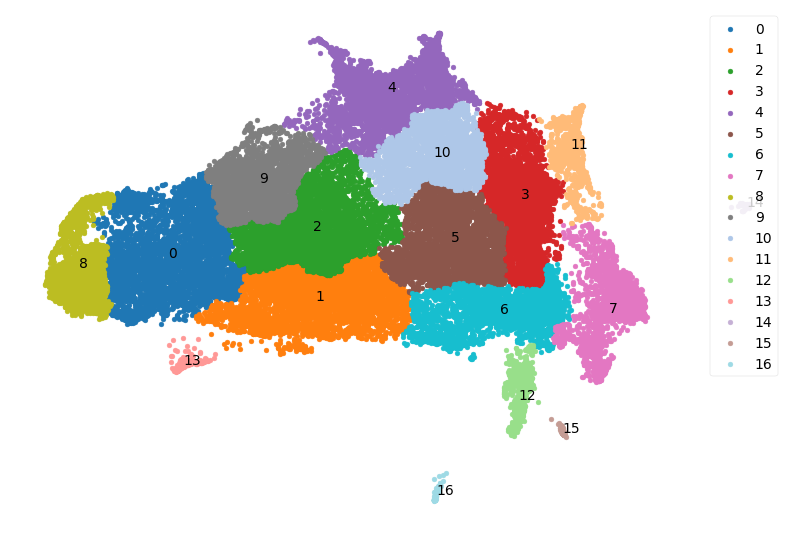

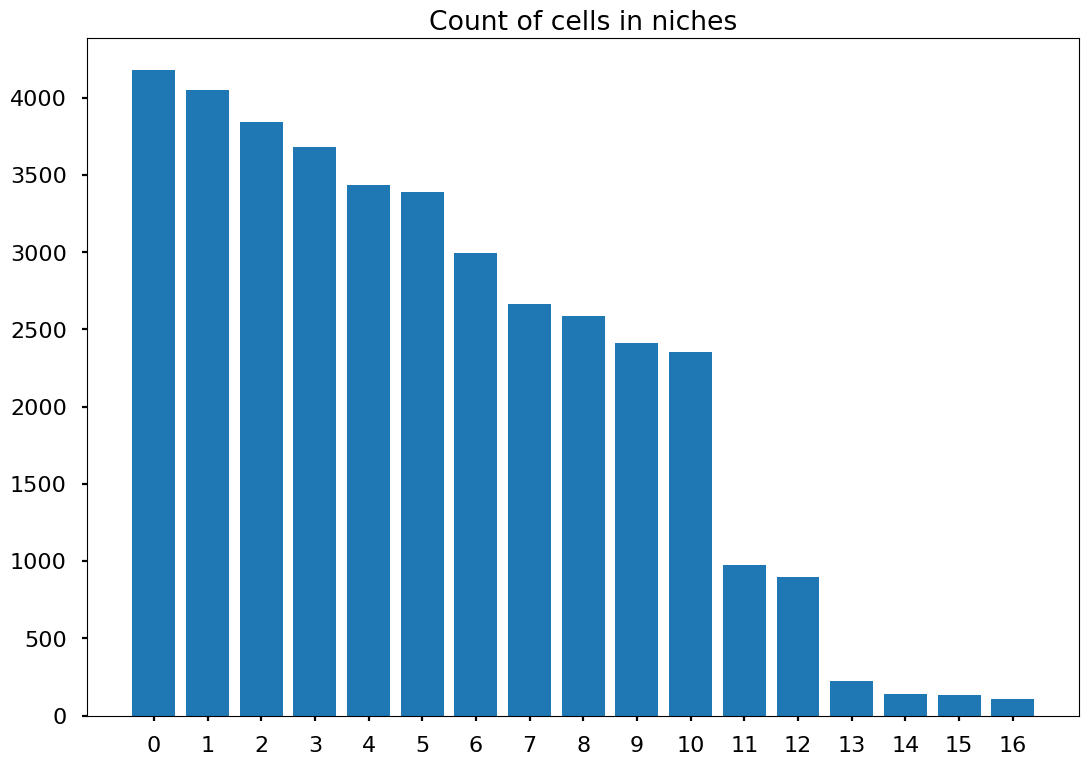

KeyError: 0

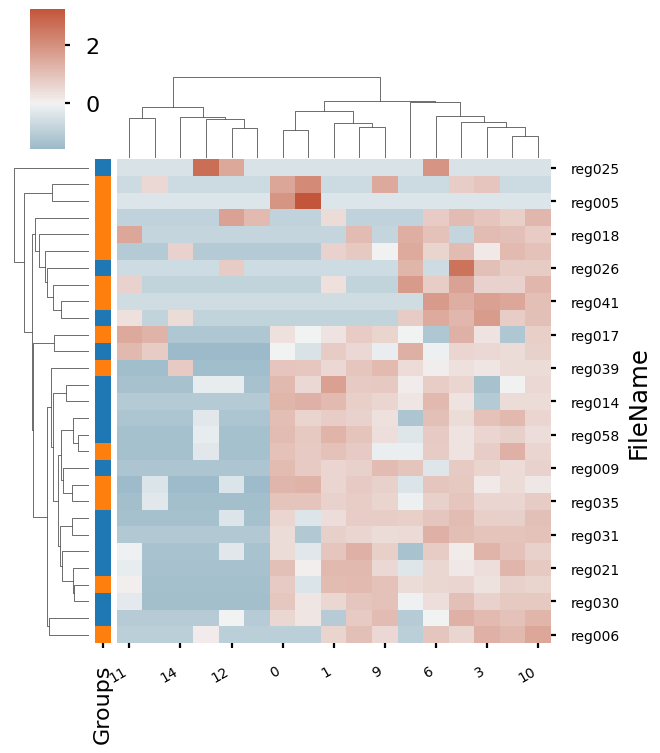

In [110]:
# Select parameters
# cluster_params, normalize_pred = get_params_from_str(selected_str_params[2])
cell_types = nodes_all[pheno_col]

# Load niches data
cluster_labels, cluster_dir, nb_clust, _ = mosna.get_clusterer(var_aggreg, sof_dir, **cluster_params)
niches = cluster_labels

embed_viz, _ = mosna.get_reducer(
    var_aggreg, 
    sof_dir, 
    reducer_type=cluster_params['reducer_type'], 
    n_neighbors=cluster_params['n_neighbors'], 
    metric=cluster_params['metric'],
    )

plt.style.use('seaborn-v0_8-notebook') #'seaborn-v0_8-notebook'
mosna.plot_clusters(embed_viz, cluster_labels, sof_dir, cluster_params=cluster_params)
if save_fig:
    figname = f"{fig_step}-niches_embedding_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()
plt.style.use('seaborn-v0_8-poster') #'seaborn-v0_8-notebook'

# Niches total counts
ax = mosna.plot_niches_histogram(niches)
plt.title('Count of cells in niches');
if save_fig:
    figname = f"{fig_step}-niches_total_count-{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Make count table of cells in niches per patient with clinical data

var_aggreg_niches = var_aggreg_samples_info.copy()
var_aggreg_niches['niche'] = np.array(niches)

counts = mosna.make_niches_composition(var_aggreg_niches[predict_key], niches, var_label=var_label, normalize=normalize_pred)
counts.index = counts.index.astype(status_pred.index.dtype)
exo_vars = counts.columns.astype(str).tolist()
df_surv = pd.concat([status_pred, counts], axis=1, join='inner').fillna(0)
df_surv.columns = df_surv.columns.astype(str)
df_surv.index.name = var_label

# Biclustering  
g, d = mosna.plot_heatmap(
    df_surv[exo_vars + [group_col]].reset_index(), 
    obs_labels=var_label, 
    group_var=group_col, 
    groups=[0, 1],
    group_names=group_names,
    figsize=(7, 7),
    cbar_pos=(0.05, 0.87, 0.05, 0.2),
    dendrogram_ratio=0.15,
    legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.1, 1.15)},
    z_score=False,
    # cmap=sns.color_palette("Reds", as_cmap=True),
    return_data=True,
    )
if save_fig:
    figname = f"{fig_step}-biclustering-{str_params}-normalize_{normalize_pred}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

g, d = mosna.plot_heatmap(
    df_surv[exo_vars + [group_col]].reset_index(), 
    obs_labels=var_label, 
    group_var=group_col, 
    groups=[0, 1],
    group_names=group_names,
    figsize=(7, 7),
    cbar_pos=(0.05, 0.87, 0.05, 0.2),
    dendrogram_ratio=0.15,
    legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.1, 1.15)},
    z_score=1,
    # cmap=sns.color_palette("Reds", as_cmap=True),
    return_data=True,
    )
if save_fig:
    figname = f"{fig_step}-biclustering_col_zscored-{str_params}_{normalize_pred}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Logistic regression
split_train_test = False
models = mosna.logistic_regression(
    df_surv[exo_vars + [group_col]],
    y_name=group_col,
    col_drop=[var_label],
    cv_train=cv_train, 
    cv_adapt=cv_adapt, 
    cv_max=cv_max,
    plot_coefs=True,
    split_train_test=split_train_test,
    save_plot_figures=save_fig,
    dir_save=save_model_dir,
    str_prefix=f"{fig_step}-{str_params}",
    )
plt.show()

# p-values
pvals = mosna.find_DE_markers(
    df_surv[exo_vars + [group_col]], 
    group_ref=1, 
    group_tgt=0, 
    group_var=group_col,
    )
print(pvals.head(20))

# Proportion of niches per response group
fig, ax = mosna.plot_distrib_groups(
    df_surv[exo_vars + [group_col]], 
    group_var=group_col,
    groups=[0, 1], 
    group_names=group_names,
    pval_data=None, 
    max_cols=20, 
    multi_ind_to_col=True,
    var_name='niches',
    )
if save_fig:
    figname = f"{fig_step}-distributions_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

# Niches composition
mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types')
title = "niche cell-types composition, normalized by total # cells"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')
title = "niche cell-types composition, normalized by niche"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='obs')
title = "niche cell-types composition, normalized by cell-type"
plt.title(title)
if save_fig:
    figname = f"{fig_step}-{title}_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

#### Check very high performance

In [ ]:
from sklearn import metrics

X_test = df_surv[exo_vars].values
y_test = df_surv[group_col].values
clf = models['advised']['model']

y_pred_proba = clf.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
if save_fig:
    figname = f"{fig_step}-ROC_curve_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

In [ ]:
select_niches = ['12', '0', '16']
all_niche_pairs = [
    [12, 0],
    [12, 16],
    [0, 16],
]

In [ ]:
sns.pairplot(
    df_surv[[group_col_cat] + select_niches], 
    hue=group_col_cat,
    diag_kind="hist",
    )
if save_fig:
    figname = f"{fig_step}-pair_plot_most_predictive_niches_12-0-16_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

In [ ]:
fig, ax, pca, x_new = mosna.plot_pca(
    data=df_surv,
    use_cols=select_niches,
    figsize=(7, 7),
    labels = df_surv[group_col_cat],
    labels_color_mapper={'Non-responder': '#FF7F0E', 'Responder': '#1F77B4'},
    )
if save_fig:
    figname = f"{fig_step}-PCA_most_predictive_niches_12-0-16_{str_params}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

In [ ]:
# Use all predictive niches
pred_niches = models['default']['coef']['abs coef']
select_niches = pred_niches[pred_niches > 0].index
print('predictive niches:', select_niches.values)

fig, ax, pca, x_new = mosna.plot_pca(
    data=df_surv,
    use_cols=select_niches,
    figsize=(7, 7),
    labels = df_surv[group_col_cat],
    labels_color_mapper={'Non-responder': '#FF7F0E', 'Responder': '#1F77B4'},
    )

In [ ]:
# Use all niche columns

fig, ax, pca, x_new = mosna.plot_pca(
    data=df_surv,
    use_cols=exo_vars,
    figsize=(7, 7),
    labels = df_surv[group_col_cat],
    labels_color_mapper={'Non-responder': '#FF7F0E', 'Responder': '#1F77B4'},
    )

Niches 16, 11 and 13 are similar, as they are mainly composed of stroma cells, though only niches 16 and 11 are informative of response to therapy. We can notice that niche 11 is made of stroma cells and a little proportion of tumor cells, whereas niche 16 is made of stroma cells only. As niche 13 is also made only of stroma cells, why isn't it selected to model response to therapy? To answer this question, we need to compare niches 16 and 13.

In [ ]:
plt.style.use('seaborn-v0_8-notebook') #'seaborn-v0_8-notebook' or 'seaborn-v0_8-poster'

In [ ]:
make_net_plots = False

if make_net_plots:
    save_net_dir = save_model_dir / 'spatial_networks_niches'
    save_net_dir.mkdir(parents=True, exist_ok=True)

    legend_opt_niches = {'loc': 'center left', 'bbox_to_anchor': (1.05, 0.5)}
    legend_opt_types = {'loc': 'center right', 'bbox_to_anchor': (-0.05, 0.5)}

    # colormap for cell-types
    n_cell_types = obj[pheno_col].unique().size
    # palette = sns.color_palette(cc.glasbey, n_colors=n_cell_types).as_hex()
    # palette = [mpl.colors.rgb2hex(x) for x in mpl.cm.get_cmap('tab20').colors]
    niche_colors = np.array([niches_color_mapper[x] for x in cluster_labels])
    plots_marker = '.'

    id_level_1 = 'patient'
    id_level_2 = 'sample'
    extension = 'parquet'
    read_fct = pd.read_parquet

    # build index of patients and samples files
    data_index = []
    len_ext = len(extension) + 1
    len_l1 = len(id_level_1) + 1
    len_l2 = len(id_level_2) + 1
    files = nodes_dir.glob(f'nodes_*.{extension}')
    for file in files:
        # parse patient and sample description
        file_name = file.name[6:-len_ext]
        patient_info, sample_info = file_name.split('_')
        patient_id = patient_info[len_l1:]
        sample_id = sample_info[len_l2:]
        # add info to data index
        data_index.append((patient_id, sample_id))

    for data_info in data_index:
        # load nodes and edges of a specific sample
        if len(data_info) == 1:
            str_group = f'{id_level_1}-{data_info[0]}'
        elif len(data_info) == 2:
            str_group = f'{id_level_1}-{data_info[0]}_{id_level_2}-{data_info[1]}'
        nodes = read_fct(nodes_dir / f'nodes_{str_group}.{extension}')
        edges = read_fct(edges_dir / f'edges_{str_group}.{extension}')
        coords = nodes[pos_cols].values
        pairs = edges.values
        # bolean selector among aggregated data
        sample_id = data_info[1]
        select = (var_aggreg_samples_info['sample'] == sample_id).values

        # Big summary plot
        fig, ax = plt.subplots(1, 4, figsize=(int(7*4)+1, 7), tight_layout=False)
        i = 0
        ty.plot_network(coords, 
                        pairs,
                        labels=nodes[pheno_col], 
                        color_mapper=celltypes_color_mapper, 
                        marker=plots_marker, 
                        size_nodes=size_points*10, 
                        ax=ax[0],
                        legend_opt=legend_opt_types,
                        )
        ax[i].set_title('Spatial map of phenotypes', fontsize=14);

        i += 1
        ax[i].scatter(coords[:, 0], coords[:, 1], c=niche_colors[select], marker=plots_marker, s=size_points*10)
        ax[i].set_title('Spatial map of detected areas', fontsize=14);
        ax[i].set_aspect('equal')

        i += 1
        ax[i].scatter(embed_viz[select, 0], embed_viz[select, 1], c=niche_colors[select], s=size_points);
        ax[i].set_title("Clustering on NAS", fontsize=14);
        ax[i].set_aspect('equal')

        i += 1
        ax[i].scatter(embed_viz[:, 0], embed_viz[:, 1], c=niche_colors, s=size_points);
        ax[i].set_title("Clustering on NAS of all samples", fontsize=14);
        ax[i].set_aspect('equal')
        
        # make plot limits equal
        ax[i-1].set_xlim(ax[i].get_xlim())
        ax[i-1].set_ylim(ax[i].get_ylim())

        suptitle = f"Spatial omics data and detected areas - sample {sample_id}";
        fig.suptitle(suptitle, fontsize=18)

        fig.savefig(save_net_dir / f'{suptitle}.jpg', bbox_inches='tight', facecolor='white', dpi=600)
        plt.show()


        fig, ax = plt.subplots(figsize=(10, 10))
        ax.scatter(coords[:, 0], coords[:, 1], c=niche_colors[select], marker=plots_marker, s=size_points*10)
        ax.set_title('Spatial map of detected areas', fontsize=14);
        ax.set_aspect('equal')
        fig.savefig(save_net_dir / f'spatial_niches_sample-{sample_id}_bignodes.jpg', bbox_inches='tight', facecolor='white', dpi=600)
        plt.show()

In [ ]:
fig, ax = mosna.plot_clusters(embed_viz, save_dir=save_model_dir, extra_str='_no_clustering', show_id=False, cluster_params=cluster_params, return_cmap=False)

In [ ]:
embed_viz, _ = mosna.get_reducer(
    var_aggreg, 
    sof_dir, 
    reducer_type=cluster_params['reducer_type'], 
    n_neighbors=cluster_params['n_neighbors'], 
    metric=cluster_params['metric'],
    )

fig, ax, niches_color_mapper = mosna.plot_clusters(
    embed_viz, 
    cluster_labels, 
    save_model_dir, 
    cluster_params=cluster_params, 
    return_cmap=True,
    extra_str='_no_cluster_id', 
    show_id=False,
    )

across all models, predictive niches are:
  - pure tumor
  - pure stroma
  
and to a lesser extent:
  - EVTM: epithelium, vasculature, tregs, macrophages (M1=M2)
  - ETMTS: epithelium, tregs, M1, tumor, stroma

#### Differential niche analysis

Niches 6, 8 and 9 are apparently made of the same unique cell type: stroma cells. What are the differences between these niches?  

In [ ]:
selected_niches = [11, 13, 16]
all_niche_pairs = [
    [13, 16],
    [11, 13],
    [11, 16],
]

In [ ]:
embed_viz, _ = mosna.get_reducer(
    var_aggreg, 
    sof_dir, 
    reducer_type=cluster_params['reducer_type'], 
    n_neighbors=cluster_params['n_neighbors'], 
    metric=cluster_params['metric'],
    )

fig, ax, niches_color_mapper = mosna.plot_clusters(
    embed_viz, 
    cluster_labels, 
    cluster_params=cluster_params, 
    return_cmap=True,
    show_id=True,
    legend=False
    )

In [ ]:
# as a reminder:
mosna.plot_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')
plt.title("niche cell-types composition, normalized by niche")

#### Differences in cell types composition

In [ ]:
niche_compo = mosna.make_niches_composition(var=cell_types, niches=niches, var_label='cell-types', normalize='niche')

In [ ]:
import seaborn as sns
df_show = niche_compo[selected_niches]
if df_show.values.min() >= 0:
    cm = sns.light_palette("green", as_cmap=True)
else:
    cm = sns.diverging_palette(220, 20, as_cmap=True)
    # cm = sns.color_palette("vlag", as_cmap=True)
s = df_show.style.background_gradient(cmap=cm)
s

#### Differences in aggregation statistics

In [ ]:
var_aggreg_niches = var_aggreg.copy()
var_aggreg_niches['niche'] = niches

In [ ]:
for group_ref, group_tgt in all_niche_pairs:
    pvals = mosna.find_DE_markers(
        var_aggreg_niches, 
        group_ref=group_ref, 
        group_tgt=group_tgt, 
        group_var='niche',
        )
    print(f"pvals between niches {group_ref} and {group_tgt}")
    print(pvals.head(10))

In [ ]:
plt.style.use('seaborn-v0_8-poster') #'seaborn-v0_8-notebook' or 'seaborn-v0_8-poster'

In [ ]:
# DE analysis
legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.2, 1.1)}
for group_ref, group_tgt in all_niche_pairs:
    fig, ax = mosna.plot_distrib_groups(
        var_aggreg_niches, 
        group_var='niche',
        groups=[group_ref, group_tgt], 
        pval_data='compute', 
        pval_col='pval_corr', 
        max_cols=20, 
        multi_ind_to_col=False,
        var_name='NAS variables',
        add_points=False,
        legend_opt=legend_opt,
        )
    figname = f"{fig_step} - comparison of NAS variables between niches {group_ref} and {group_tgt}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()

#### Extract a single cell type for comparison

We've seen these niches are slightly different in cell types composition.  
What if we compare the same cell type between groups? The amount of other cell types in the inspected niches is so low that differences should be due to a different environment (chemokines, mechanics, ...) and not direct signaling.

In [ ]:
select = cell_types == 'stroma'
single_pheno_niches = var_aggreg_niches.loc[select, :]

In [ ]:
for group_ref, group_tgt in all_niche_pairs:
    pvals = mosna.find_DE_markers(
        single_pheno_niches, 
        group_ref=group_ref, 
        group_tgt=group_tgt, 
        group_var='niche',
        )
    print(f"pvals between niches {group_ref} and {group_tgt}")
    print(pvals.head(10))

In [ ]:
# DE analysis
legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.2, 1.1)}
for group_ref, group_tgt in all_niche_pairs:
    fig, ax = mosna.plot_distrib_groups(
        single_pheno_niches, 
        group_var='niche',
        groups=[group_ref, group_tgt], 
        pval_data='compute', 
        pval_col='pval_corr', 
        max_cols=20, 
        multi_ind_to_col=False,
        var_name='NAS variables',
        add_points=False,
        legend_opt=legend_opt,
        )
    figname = f"{fig_step} - comparison of NAS variables between niches {group_ref} and {group_tgt} - stroma cells only.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()

#### Differences in raw marker levels

In [ ]:
aggreg_vars = marker_cols
markers_niches = obj[aggreg_vars].copy()
markers_niches['niche'] = niches

In [ ]:
for group_ref, group_tgt in all_niche_pairs:
    pvals = mosna.find_DE_markers(
        markers_niches, 
        group_ref=group_ref, 
        group_tgt=group_tgt, 
        group_var='niche',
        )
    print(f"pvals on marker between niches {group_ref} and {group_tgt}")
    print(pvals.head(10))

In [ ]:
# DE analysis
legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.2, 1.1)}
for group_ref, group_tgt in all_niche_pairs:
    fig, ax = mosna.plot_distrib_groups(
        markers_niches, 
        group_var='niche',
        groups=[group_ref, group_tgt], 
        pval_data='compute', 
        pval_col='pval_corr', 
        max_cols=20, 
        multi_ind_to_col=False,
        var_name='markers',
        add_points=False,
        legend_opt=legend_opt,
        )
    figname = f"{fig_step} - comparison of raw markers between niches {group_ref} and {group_tgt}.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()

#### select stroma cells only

In [ ]:
select = cell_types == 'stroma'
single_pheno_niches_raw = markers_niches.loc[select, :]

In [ ]:
for group_ref, group_tgt in all_niche_pairs:
    pvals = mosna.find_DE_markers(
        single_pheno_niches_raw, 
        group_ref=group_ref, 
        group_tgt=group_tgt, 
        group_var='niche',
        )
    print(f"pvals on marker between niches {group_ref} and {group_tgt}")
    print(pvals.head(10))

In [ ]:
# DE analysis
legend_opt = {'loc': 'lower right', 'bbox_to_anchor': (1.2, 1.1)}
for group_ref, group_tgt in all_niche_pairs:
    fig, ax = mosna.plot_distrib_groups(
        single_pheno_niches_raw, 
        group_var='niche',
        groups=[group_ref, group_tgt], 
        pval_data='compute', 
        pval_col='pval_corr', 
        max_cols=20, 
        multi_ind_to_col=False,
        var_name='markers',
        add_points=False,
        legend_opt=legend_opt,
        )
    figname = f"{fig_step} - comparison of raw markers between niches {group_ref} and {group_tgt} - stroma cells only.jpg"
    plt.savefig(save_model_dir / figname, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()

## On markers, order 2

## On markers, order 3